<a href="https://colab.research.google.com/github/kerenslendyrc/Estadistica/blob/main/AnalisisVariablesFinancieras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================================
# 0) LIBRERÍAS Y CONFIGURACIÓN
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import levene
from scipy.stats import chi2_contingency
from scipy.stats import mannwhitneyu, kruskal

import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

In [ ]:
# =========================================================
# 1) CARGA DE LA BASE FINAL V2
# =========================================================

from google.colab import files

upload = files.upload()
nombre_archivo = next(iter(upload.keys()))

ext = os.path.splitext(nombre_archivo)[1].lower()

if ext == ".csv":
    df_base = pd.read_csv(nombre_archivo)
elif ext in [".xlsx", ".xls"]:
    df_base = pd.read_excel(nombre_archivo)
elif ext == ".parquet":
    df_base = pd.read_parquet(nombre_archivo)
elif ext in [".pkl", ".pickle"]:
    df_base = pd.read_pickle(nombre_archivo)
else:
    raise ValueError(f"Formato no soportado: {ext}")

df_base.columns = df_base.columns.str.strip()

print("Archivo cargado:", nombre_archivo)
print("Filas:", len(df_base))
print("Columnas:", len(df_base.columns))
display(df_base.head(3))

Saving base_financiera_v2.xlsx to base_financiera_v2.xlsx
Archivo cargado: base_financiera_v2.xlsx
Filas: 26266
Columnas: 60


,episodio,fecha_ini_episodio,fecha_movimiento_alta,clase_movimiento_alta,asignacion_enfermeria,Ingreso del servicio,Ingreso Materiales y medicamentos,Ingreso honorarios,Ingreso Total,Servicio,uo_medico,unidad_medica,Estancia,Estancia Facturada,edad,grupo_de_edad,indice_grupo_de_edad,grupo_de_edad_2,ciclo_de_vida,edad_dias,sexo,EPS,departamento,ciudad,id_discapacidad,cdo_diagnostico_egreso,nombre_diagnostico_egreso,gran_causa_morbilidad,subgrupo_causa_morbilidad,cod_causa_basica_muerte,causa_basica_muerte,fecha_muerte,dx_codigo,dx_nombre,gran_causa_original_norm,fecha_muerte_dt,fall_bin,fecha_ingreso_dt,anio_analisis,clasificacion_reconstruida,flag_covid,flag_materna,flag_perinatal,flag_infecciosa_no_covid,flag_no_transmisible,flag_lesiones,flag_mal_definida,subtipo_obstetrico,macro_original,flag_discrepancia_clinica,sexo_norm,grupo_edad_norm,cie_capitulo,cie_3,macro_grupo_cluster,familia_clinica_previa,subcluster_principal_num,subcluster_principal,grupo_principal,flag_subcluster_principal
0,6712217,2024-01-01,2024-01-02 06:08:00,Alta,1 UE HOSP CLINICENTRO URG P4,192060,7398306,273660,10296964,Hospitalización adultos,1MHCXGEN,1 UM H CX GENERAL,1,1,29,25-29,6,adulto,Adultez (29-59),10799,Hombre,COLSANITAS,SANTANDER,FLORIDABLANCA,Ninguna,K359,"APENDICITIS AGUDA, NO ESPECIFICADA",Enfermedades no transmisibles,Enfermedades digestivas,NaN,NaN,NaT,K359,"APENDICITIS AGUDA, NO ESPECIFICADA",NO_TRANSMISIBLES,NaT,0,2024-01-01,2024,NO_TRANSMISIBLE,0,0,0,0,1,0,0,NO_APLICA,NO_TRANSMISIBLE,0,HOMBRE,25-29,K,K35,NO_TRANSMISIBLE,NT_DIGESTIVO_HEPATOBILIAR,1,C01,NO_TRANSMISIBLE__C01,1
1,6712269,2024-01-01,2024-01-01 23:48:00,Alta a H ext.,1 UE HOSP CLINICENTRO URG P4,293900,91920,263100,736520,Hospitalización adultos,1MHMEINT,1 UM H MEDICINA INTERNA,1,1,68,65-69,14,adulto,Vejez (60 o más),24924,Hombre,UIS,SANTANDER,BARRANCABERMEJA,Ninguna,A90X,FIEBRE DEL DENGUE [DENGUE CLASICO],Condiciones transmisibles y nutricionales,Enfermedades infecciosas y parasitarias,NaN,NaN,NaT,A90X,FIEBRE DEL DENGUE [DENGUE CLASICO],TRANSMISIBLES,NaT,0,2024-01-01,2024,INFECCIOSA_NO_COVID,0,0,0,1,0,0,0,NO_APLICA,INFECCIOSA_NO_COVID,0,HOMBRE,65-69,A,A90,INFECCIOSA_NO_COVID,INF_VECTORIALES_TROPICALES,1,C01,INFECCIOSA_NO_COVID__C01,1
2,6712310,2024-01-01,2024-01-02 16:05:00,Alta a H ext.,1 UE HOSP CLINICENTRO URG P4,127900,178660,601350,1170053,Hospitalización adultos,1MHMEINT,1 UM H MEDICINA INTERNA,1,1,66,65-69,14,adulto,Vejez (60 o más),24123,Hombre,ECOPETROL,SANTANDER,BARRANCABERMEJA,Cardiorespiratorio y/o defensas,K922,"HEMORRAGIA GASTROINTESTINAL, NO ESPECIFICADA",Enfermedades no transmisibles,Enfermedades digestivas,NaN,NaN,NaT,K922,"HEMORRAGIA GASTROINTESTINAL, NO ESPECIFICADA",NO_TRANSMISIBLES,NaT,0,2024-01-01,2024,NO_TRANSMISIBLE,0,0,0,0,1,0,0,NO_APLICA,NO_TRANSMISIBLE,0,HOMBRE,65-69,K,K92,NO_TRANSMISIBLE,NT_DIGESTIVO_HEPATOBILIAR,1,C01,NO_TRANSMISIBLE__C01,1


In [ ]:
# =========================================================
# 2) FUNCIONES AUXILIARES
# =========================================================

def resolver_columna(df, opciones, nombre_amigable, obligatoria=True):
    for col in opciones:
        if col in df.columns:
            return col

    cols_lower = {c.lower(): c for c in df.columns}
    for col in opciones:
        if col.lower() in cols_lower:
            return cols_lower[col.lower()]

    for c in df.columns:
        cl = c.lower()
        for cand in opciones:
            if cand.lower() in cl:
                return c

    if obligatoria:
        raise KeyError(
            f"No encontré la columna para '{nombre_amigable}'. "
            f"Probé con: {opciones}. "
            f"Columnas disponibles: {list(df.columns)}"
        )
    return None

def limpiar_cat(s):
    return (
        s.astype("object")
         .where(s.notna(), "MISSING")
         .astype(str)
         .str.strip()
    )

def a_binario_si_no(s):
    return (
        pd.Series(s)
        .astype(str)
        .str.strip()
        .str.upper()
        .isin(["SI", "SÍ", "1", "TRUE", "T", "YES"])
        .astype(int)
    )

In [ ]:
# =========================================================
# 3) CLUSTERS FINALES V2
# =========================================================

CLUSTER_COL = "grupo_principal"
MACRO_COL = "macro_grupo_cluster"
SUBCLUSTER_COL = "subcluster_principal"

if CLUSTER_COL not in df_base.columns:
    raise KeyError(f"No encontré la columna {CLUSTER_COL} en la base cargada.")

orden_clusters = [
    "NO_TRANSMISIBLE__C01",
    "NO_TRANSMISIBLE__C02",
    "NO_TRANSMISIBLE__C03",
    "INFECCIOSA_NO_COVID__C01",
    "INFECCIOSA_NO_COVID__C02",
    "INFECCIOSA_NO_COVID__C03",
    "MATERNA_OBSTETRICA__C01",
    "PERINATAL_NEONATAL__C01",
    "LESIONES__C01",
    "MAL_DEFINIDAS_INESPECIFICAS__C01",
]

orden_clusters = [c for c in orden_clusters if c in df_base[CLUSTER_COL].astype(str).unique()]

MAPA_NOMBRES_CLUSTER = {
    "NO_TRANSMISIBLE__C01": "NT digestivo-quirúrgico",
    "NO_TRANSMISIBLE__C02": "NT osteomuscular-neuroq",
    "NO_TRANSMISIBLE__C03": "NT médico crónico complejo",
    "INFECCIOSA_NO_COVID__C01": "INF vectorial-entérico",
    "INFECCIOSA_NO_COVID__C02": "INF urinario",
    "INFECCIOSA_NO_COVID__C03": "INF respiratorio-cutáneo",
    "MATERNA_OBSTETRICA__C01": "Materna obstétrica",
    "PERINATAL_NEONATAL__C01": "Perinatal-neonatal",
    "LESIONES__C01": "Lesiones",
    "MAL_DEFINIDAS_INESPECIFICAS__C01": "Mal definidas"
}

print("Clusters finales detectados:")
display(
    df_base[CLUSTER_COL]
    .value_counts()
    .rename_axis(CLUSTER_COL)
    .reset_index(name="n")
)

Clusters finales detectados:


,grupo_principal,n
0,NO_TRANSMISIBLE__C03,7114
1,MATERNA_OBSTETRICA__C01,4229
2,MAL_DEFINIDAS_INESPECIFICAS__C01,3328
3,NO_TRANSMISIBLE__C02,2660
4,NO_TRANSMISIBLE__C01,1864
5,INFECCIOSA_NO_COVID__C03,1823
6,INFECCIOSA_NO_COVID__C02,1803
7,INFECCIOSA_NO_COVID__C01,1704
8,LESIONES__C01,1133
9,PERINATAL_NEONATAL__C01,608


In [ ]:
# =========================================================
# 6) DETECTAR VARIABLES FINANCIERAS Y OPERATIVAS
# =========================================================

COL_ESTANCIA = resolver_columna(
    df_base,
    [
        "Estancia Facturada",
        "estancia_facturada",
        "Estancia facturada",
        "estancia facturada",
        "dias_estancia_facturada",
        "dias_facturados",
        "Estancia",
        "estancia"
    ],
    "estancia facturada"
)

COL_ING_SERVICIO = resolver_columna(
    df_base,
    [
        "Ingreso del servicio",
        "Ingreso Del Servicio",
        "ingreso_del_servicio",
        "ingreso servicio",
        "ing_servicio",
        "INGRESO_SERVICIO"
    ],
    "Ingreso del servicio",
    obligatoria=False
)

COL_ING_MATMED = resolver_columna(
    df_base,
    [
        "Ingreso Materiales y medicamentos",
        "Ingreso materiales y medicamentos",
        "ingreso_materiales_medicamentos",
        "ingreso materiales y medicamentos",
        "ing_mat_med",
        "INGRESO_MAT_MED"
    ],
    "Ingreso materiales y medicamentos",
    obligatoria=False
)

COL_ING_HON = resolver_columna(
    df_base,
    [
        "Ingreso honorarios",
        "ingreso_honorarios",
        "ingreso honorarios",
        "ing_honorarios",
        "INGRESO_HONORARIOS"
    ],
    "Ingreso honorarios",
    obligatoria=False
)

COL_ING_TOTAL = resolver_columna(
    df_base,
    [
        "Ingreso Total",
        "Ingreso total",
        "ingreso_total",
        "ingreso total",
        "ing_total",
        "INGRESO_TOTAL"
    ],
    "Ingreso total",
    obligatoria=False
)

COL_COSTO = resolver_columna(
    df_base,
    [
        "Costo",
        "costo",
        "costo_total",
        "COSTO_TOTAL"
    ],
    "costo",
    obligatoria=False
)

COL_PISO = resolver_columna(
    df_base,
    [
        "piso_atencion",
        "piso de atencion",
        "piso",
        "PISO"
    ],
    "piso de atención",
    obligatoria=False
)

variables_financieras = {
    "ingreso_servicio": COL_ING_SERVICIO,
    "ingreso_materiales_medicamentos": COL_ING_MATMED,
    "ingreso_honorarios": COL_ING_HON,
    "ingreso_total": COL_ING_TOTAL,
    "costo": COL_COSTO
}

print("Estancia:", COL_ESTANCIA)
print("Piso de atención:", COL_PISO)
print("\nVariables financieras detectadas:")
for k, v in variables_financieras.items():
    print(f"{k}: {v}")

Estancia: Estancia Facturada
Piso de atención: episodio

Variables financieras detectadas:
ingreso_servicio: Ingreso del servicio
ingreso_materiales_medicamentos: Ingreso Materiales y medicamentos
ingreso_honorarios: Ingreso honorarios
ingreso_total: Ingreso Total
costo: None


In [ ]:
# =========================================================
# 7) PREPARAR BASE EXPERIMENTAL V2
# =========================================================

df_exp = df_base.copy()

df_exp["_cluster"] = df_exp[CLUSTER_COL].astype(str)
df_exp["_cluster"] = pd.Categorical(df_exp["_cluster"], categories=orden_clusters, ordered=True)

df_exp["_cluster_legible"] = df_exp["_cluster"].astype(str).map(MAPA_NOMBRES_CLUSTER).fillna(df_exp["_cluster"].astype(str))

df_exp["_estancia"] = pd.to_numeric(df_exp[COL_ESTANCIA], errors="coerce")

bins = [-np.inf, 1, 2, 5, 10, 20, np.inf]
labels_bloque = ["0-1 día", "2 días", "3-5 días", "6-10 días", "11-20 días", "21+ días"]

df_exp["_bloque_estancia"] = pd.cut(
    df_exp["_estancia"],
    bins=bins,
    labels=labels_bloque,
    right=True
)

print("=== Distribución del bloque de estancia ===")
display(
    df_exp["_bloque_estancia"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("bloque_estancia")
    .reset_index(name="n")
)

print("=== Distribución por cluster final ===")
display(
    df_exp["_cluster"]
    .value_counts(dropna=False)
    .rename_axis("_cluster")
    .reset_index(name="n")
)

if COL_PISO:
    df_exp["_piso"] = limpiar_cat(df_exp[COL_PISO])

=== Distribución del bloque de estancia ===


,bloque_estancia,n
0,0-1 día,8247
1,2 días,5868
2,3-5 días,6812
3,6-10 días,3223
4,11-20 días,1574
5,21+ días,542


=== Distribución por cluster final ===


,_cluster,n
0,NO_TRANSMISIBLE__C03,7114
1,MATERNA_OBSTETRICA__C01,4229
2,MAL_DEFINIDAS_INESPECIFICAS__C01,3328
3,NO_TRANSMISIBLE__C02,2660
4,NO_TRANSMISIBLE__C01,1864
5,INFECCIOSA_NO_COVID__C03,1823
6,INFECCIOSA_NO_COVID__C02,1803
7,INFECCIOSA_NO_COVID__C01,1704
8,LESIONES__C01,1133
9,PERINATAL_NEONATAL__C01,608


In [ ]:
# =========================================================
# 8) RESUMEN DESCRIPTIVO FINANCIERO POR CLUSTER
# =========================================================

resumenes_financieros = []

for nombre_var, col in variables_financieras.items():
    if col is None:
        continue

    temp = df_exp[[CLUSTER_COL, col, "_estancia", "_bloque_estancia"]].copy()
    temp["_y"] = pd.to_numeric(temp[col], errors="coerce")
    temp = temp.dropna(subset=["_y"])

    resumen = (
        temp.groupby(CLUSTER_COL)
            .agg(
                n=(CLUSTER_COL, "size"),
                media_ingreso=("_y", "mean"),
                mediana_ingreso=("_y", "median"),
                p25_ingreso=("_y", lambda x: np.nanpercentile(x, 25)),
                p75_ingreso=("_y", lambda x: np.nanpercentile(x, 75)),
                media_estancia=("_estancia", "mean"),
                mediana_estancia=("_estancia", "median")
            )
            .reset_index()
    )
    resumen["variable_respuesta"] = nombre_var
    resumenes_financieros.append(resumen)

if resumenes_financieros:
    tabla_resumen_financiero = pd.concat(resumenes_financieros, ignore_index=True)
    display(tabla_resumen_financiero.round(2))
else:
    print("No se detectaron variables financieras con los nombres esperados.")

,grupo_principal,n,media_ingreso,mediana_ingreso,p25_ingreso,p75_ingreso,media_estancia,mediana_estancia,variable_respuesta
0,INFECCIOSA_NO_COVID__C01,1704,1019605.29,410300.0,196740.00,832620.00,4.16,3.0,ingreso_servicio
1,INFECCIOSA_NO_COVID__C02,1803,909979.16,386835.0,166011.00,797720.00,3.90,3.0,ingreso_servicio
2,INFECCIOSA_NO_COVID__C03,1823,925624.57,416310.0,144030.00,996066.00,4.38,3.0,ingreso_servicio
3,LESIONES__C01,1133,1494299.92,474280.0,166011.00,1396950.00,4.79,3.0,ingreso_servicio
4,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,556098.59,207740.0,124263.00,498033.00,2.97,2.0,ingreso_servicio
5,MATERNA_OBSTETRICA__C01,4229,385642.11,332022.0,242640.00,432090.00,2.33,2.0,ingreso_servicio
6,NO_TRANSMISIBLE__C01,1864,955324.31,474280.0,196740.00,1061602.50,4.77,3.0,ingreso_servicio
7,NO_TRANSMISIBLE__C02,2660,1030698.10,253626.0,138770.00,855690.00,3.67,2.0,ingreso_servicio
8,NO_TRANSMISIBLE__C03,7114,1156180.53,418611.0,166011.00,1163652.00,5.00,3.0,ingreso_servicio
9,PERINATAL_NEONATAL__C01,608,2966969.91,948301.0,456912.00,3876215.00,7.46,5.0,ingreso_servicio


In [ ]:
# =========================================================
# 9) FUNCIÓN DEL DISEÑO DE EXPERIMENTOS
# =========================================================

def correr_diseno_experimentos(df, col_respuesta, nombre_respuesta, usar_interaccion=True):
    temp = df[[CLUSTER_COL, "_cluster", "_bloque_estancia", "_estancia", col_respuesta]].copy()
    temp["_y"] = pd.to_numeric(temp[col_respuesta], errors="coerce")
    temp = temp.dropna(subset=["_y", "_bloque_estancia", "_cluster"]).copy()

    if len(temp) == 0:
        print(f"No hay datos válidos para {nombre_respuesta}")
        return None

    # Transformación log para manejar asimetría
    min_y = temp["_y"].min()
    shift = 0
    if min_y <= -1:
        shift = abs(min_y) + 1.0

    temp["_y_log"] = np.log1p(temp["_y"] + shift)

    # Modelos
    modelo_cluster = smf.ols("_y_log ~ C(_cluster)", data=temp).fit()
    modelo_bloque = smf.ols("_y_log ~ C(_cluster) + C(_bloque_estancia)", data=temp).fit()

    if usar_interaccion:
        modelo_inter = smf.ols("_y_log ~ C(_cluster) * C(_bloque_estancia)", data=temp).fit()
    else:
        modelo_inter = None

    # Tablas ANOVA
    anova_cluster = anova_lm(modelo_cluster, typ=2)
    anova_bloque = anova_lm(modelo_bloque, typ=2)
    anova_inter = anova_lm(modelo_inter, typ=2) if modelo_inter is not None else None

    # Comparación AIC/BIC
    comparacion_modelos = pd.DataFrame({
        "modelo": ["solo_cluster", "cluster_bloque"] + (["cluster_bloque_interaccion"] if modelo_inter is not None else []),
        "AIC": [modelo_cluster.aic, modelo_bloque.aic] + ([modelo_inter.aic] if modelo_inter is not None else []),
        "BIC": [modelo_cluster.bic, modelo_bloque.bic] + ([modelo_inter.bic] if modelo_inter is not None else []),
        "R2": [modelo_cluster.rsquared, modelo_bloque.rsquared] + ([modelo_inter.rsquared] if modelo_inter is not None else [])
    }).sort_values(["AIC", "BIC"]).reset_index(drop=True)

    # Medias descriptivas por cluster (escala original)
    medias_cluster = (
        temp.groupby("_cluster")
            .agg(
                n=("_cluster", "size"),
                media=("_y", "mean"),
                mediana=("_y", "median"),
                p25=("_y", lambda x: np.nanpercentile(x, 25)),
                p75=("_y", lambda x: np.nanpercentile(x, 75))
            )
            .reset_index()
            .rename(columns={"_cluster": "cluster"})
    )

    # Tukey exploratorio sobre respuesta transformada por cluster
    tukey = pairwise_tukeyhsd(endog=temp["_y_log"], groups=temp["_cluster"], alpha=0.05)
    tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])

    return {
        "data": temp,
        "modelo_cluster": modelo_cluster,
        "modelo_bloque": modelo_bloque,
        "modelo_interaccion": modelo_inter,
        "anova_cluster": anova_cluster,
        "anova_bloque": anova_bloque,
        "anova_interaccion": anova_inter,
        "comparacion_modelos": comparacion_modelos,
        "medias_cluster": medias_cluster,
        "tukey_cluster": tukey_df,
        "shift_log": shift
    }

In [ ]:
# =========================================================
# 10) EJECUTAR EL DISEÑO PARA CADA VARIABLE FINANCIERA
# =========================================================

resultados_doe = {}

for nombre_var, col in variables_financieras.items():
    if col is None:
        continue

    print("\n" + "="*80)
    print(f"VARIABLE RESPUESTA: {nombre_var}  |  COLUMNA: {col}")
    print("="*80)

    res = correr_diseno_experimentos(df_exp, col, nombre_var, usar_interaccion=True)
    resultados_doe[nombre_var] = res

    print("\n--- Comparación de modelos ---")
    display(res["comparacion_modelos"].round(4))

    print("\n--- ANOVA: solo cluster ---")
    display(res["anova_cluster"].round(4))

    print("\n--- ANOVA: cluster + bloque_estancia ---")
    display(res["anova_bloque"].round(4))

    print("\n--- ANOVA: cluster * bloque_estancia ---")
    display(res["anova_interaccion"].round(4))

    print("\n--- Medias descriptivas por cluster (escala original) ---")
    display(res["medias_cluster"].round(2))

    print("\n--- Tukey por cluster (respuesta log-transformada) ---")
    display(res["tukey_cluster"].head(20))


VARIABLE RESPUESTA: ingreso_servicio  |  COLUMNA: Ingreso del servicio


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 9, but rank is 8
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 45, but rank is 44
  warnings.warn('covariance of constraints does not have full '
/tmp/ipykernel_3704/2333181705.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silen


--- Comparación de modelos ---


,modelo,AIC,BIC,R2
0,cluster_bloque_interaccion,39592.1178,40074.5036,0.8112
1,cluster_bloque,40149.3664,40272.0068,0.8065
2,solo_cluster,81676.8898,81758.6501,0.0590



--- ANOVA: solo cluster ---


...

,sum_sq,df,F,PR(>F)
C(_cluster),3654.6184,9.0,546.3194,0.0
C(_bloque_estancia),13406.5105,5.0,3607.3878,0.0
C(_cluster):C(_bloque_estancia),437.5459,45.0,13.0815,0.0
Residual,19479.1597,26207.0,NaN,NaN



--- Medias descriptivas por cluster (escala original) ---


,cluster,n,media,mediana,p25,p75
0,NO_TRANSMISIBLE__C01,1864,5584414.60,2994195.0,1322145.25,6708420.00
1,NO_TRANSMISIBLE__C02,2660,7762926.54,2072340.5,793335.00,6156812.25
2,NO_TRANSMISIBLE__C03,7114,9426761.31,3653058.5,1340567.00,10848050.00
3,INFECCIOSA_NO_COVID__C01,1704,3506579.21,1034518.5,629830.50,2239762.75
4,INFECCIOSA_NO_COVID__C02,1803,2710457.41,1007257.0,623425.00,2060235.00
5,INFECCIOSA_NO_COVID__C03,1823,3557450.84,1411140.0,713050.00,3247487.50
6,MATERNA_OBSTETRICA__C01,4229,1757475.83,1493270.0,1115620.00,2020898.00
7,PERINATAL_NEONATAL__C01,608,5460025.48,2008966.0,810359.75,6920412.75
8,LESIONES__C01,1133,10445888.16,2928863.0,942450.00,11886137.00
9,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,2805984.61,1113440.0,648920.00,2501926.00



--- Tukey por cluster (respuesta log-transformada) ---


,group1,group2,meandiff,p-adj,lower,upper,reject
0,INFECCIOSA_NO_COVID__C01,INFECCIOSA_NO_COVID__C02,-0.0862,0.4581,-0.2103,0.0379,False
1,INFECCIOSA_NO_COVID__C01,INFECCIOSA_NO_COVID__C03,0.2036,0.0000,0.0798,0.3274,True
2,INFECCIOSA_NO_COVID__C01,LESIONES__C01,0.9573,0.0000,0.8165,1.0981,True
3,INFECCIOSA_NO_COVID__C01,MAL_DEFINIDAS_INESPECIFICAS__C01,0.0253,0.9993,-0.0841,0.1347,False
4,INFECCIOSA_NO_COVID__C01,MATERNA_OBSTETRICA__C01,0.0978,0.0962,-0.0076,0.2032,False
5,INFECCIOSA_NO_COVID__C01,NO_TRANSMISIBLE__C01,0.7794,0.0000,0.6563,0.9025,True
6,INFECCIOSA_NO_COVID__C01,NO_TRANSMISIBLE__C02,0.6257,0.0000,0.5117,0.7397,True
7,INFECCIOSA_NO_COVID__C01,NO_TRANSMISIBLE__C03,1.0450,0.0000,0.9460,1.1441,True
8,INFECCIOSA_NO_COVID__C01,PERINATAL_NEONATAL__C01,0.5629,0.0000,0.3894,0.7364,True
9,INFECCIOSA_NO_COVID__C02,INFECCIOSA_NO_COVID__C03,0.2898,0.0000,0.1678,0.4118,True


P valores

In [ ]:
# =========================================================
# PASO 1) PRUEBA GLOBAL DE HIPÓTESIS DE LA INTERACCIÓN
# =========================================================

tabla_hipotesis = []

for nombre_var, res in resultados_doe.items():
    if res is None or res["anova_interaccion"] is None:
        continue

    anova_i = res["anova_interaccion"].copy()

    p_cluster = anova_i.loc["C(_cluster)", "PR(>F)"] if "C(_cluster)" in anova_i.index else np.nan
    p_estancia = anova_i.loc["C(_bloque_estancia)", "PR(>F)"] if "C(_bloque_estancia)" in anova_i.index else np.nan
    p_interaccion = anova_i.loc["C(_cluster):C(_bloque_estancia)", "PR(>F)"] if "C(_cluster):C(_bloque_estancia)" in anova_i.index else np.nan

    decision_interaccion = (
        "Rechazar H0: sí hay interacción cluster × estancia"
        if pd.notna(p_interaccion) and p_interaccion < 0.05
        else "No rechazar H0: no hay evidencia suficiente de interacción"
    )

    tabla_hipotesis.append({
        "variable_respuesta": nombre_var,
        "p_cluster": p_cluster,
        "p_bloque_estancia": p_estancia,
        "p_interaccion": p_interaccion,
        "decision_interaccion": decision_interaccion
    })

tabla_hipotesis = pd.DataFrame(tabla_hipotesis).sort_values("p_interaccion", na_position="last").reset_index(drop=True)

print("=== PRUEBAS GLOBALES DE HIPÓTESIS ===")
display(tabla_hipotesis)

# Enfocar específicamente en ingreso total
if "ingreso_total" in resultados_doe and resultados_doe["ingreso_total"] is not None:
    anova_ing_total = resultados_doe["ingreso_total"]["anova_interaccion"].copy()

    print("\n=== ANOVA DE INTERACCIÓN PARA INGRESO TOTAL ===")
    display(anova_ing_total.round(6))

    if "C(_cluster):C(_bloque_estancia)" in anova_ing_total.index:
        p_int = anova_ing_total.loc["C(_cluster):C(_bloque_estancia)", "PR(>F)"]

        print("\n=== INTERPRETACIÓN FORMAL ===")
        print("H0: no existe interacción entre cluster y bloque de estancia sobre el ingreso total.")
        print("H1: sí existe interacción entre cluster y bloque de estancia sobre el ingreso total.")
        print(f"p-valor de la interacción = {p_int:.6g}")

        if p_int < 0.05:
            print("Decisión: RECHAZAR H0.")
            print("Conclusión: sí hay evidencia estadística de interacción entre cluster y estancia sobre el ingreso total.")
            print("Interpretación: el efecto de la estancia sobre el ingreso NO es igual en todos los clusters.")
        else:
            print("Decisión: NO RECHAZAR H0.")
            print("Conclusión: no hay evidencia estadística suficiente de interacción entre cluster y estancia sobre el ingreso total.")
            print("Interpretación: el efecto de la estancia sobre el ingreso podría considerarse similar entre clusters.")

=== PRUEBAS GLOBALES DE HIPÓTESIS ===


,variable_respuesta,p_cluster,p_bloque_estancia,p_interaccion,decision_interaccion
0,ingreso_materiales_medicamentos,0.000000e+00,0.0,5.812729e-144,Rechazar H0: sí hay interacción cluster × esta...
1,ingreso_servicio,3.904234e-122,0.0,1.200212e-107,Rechazar H0: sí hay interacción cluster × esta...
2,ingreso_total,0.000000e+00,0.0,1.381412e-92,Rechazar H0: sí hay interacción cluster × esta...
3,ingreso_honorarios,0.000000e+00,0.0,8.350234e-20,Rechazar H0: sí hay interacción cluster × esta...



=== ANOVA DE INTERACCIÓN PARA INGRESO TOTAL ===


,sum_sq,df,F,PR(>F)
C(_cluster),3654.618366,9.0,546.319387,0.0
C(_bloque_estancia),13406.510457,5.0,3607.387836,0.0
C(_cluster):C(_bloque_estancia),437.545905,45.0,13.081520,0.0
Residual,19479.159741,26207.0,NaN,NaN



=== INTERPRETACIÓN FORMAL ===
H0: no existe interacción entre cluster y bloque de estancia sobre el ingreso total.
H1: sí existe interacción entre cluster y bloque de estancia sobre el ingreso total.
p-valor de la interacción = 1.38141e-92
Decisión: RECHAZAR H0.
Conclusión: sí hay evidencia estadística de interacción entre cluster y estancia sobre el ingreso total.
Interpretación: el efecto de la estancia sobre el ingreso NO es igual en todos los clusters.


Personas con el mismo diagnóstico pueden generar ingresos distintos porque el costo no depende solo del diagnóstico, sino también del perfil clínico-operativo al que pertenecen (cluster) y de cómo se comporta su estancia dentro de ese perfil. el mismo diagnóstico puede “vivirse” de forma distinta en distintos clusters: cambia la complejidad, el consumo de recursos, la duración y probablemente los procedimientos asociados.

In [ ]:
# =========================================================
# PASO 2) POST HOC ESTRATIFICADO PARA INGRESO TOTAL
# A) Clusters dentro de cada bloque de estancia
# B) Bloques de estancia dentro de cada cluster
# =========================================================

VARIABLE_OBJETIVO = "ingreso_total"   # luego podemos cambiar a ingreso_servicio, etc.
MIN_N_GRUPO = 10                      # mínimo por grupo para comparar con estabilidad
ALPHA = 0.05

res_obj = resultados_doe[VARIABLE_OBJETIVO]
temp_posthoc = res_obj["data"].copy()

print("Variable objetivo:", VARIABLE_OBJETIVO)
print("Filas disponibles:", len(temp_posthoc))
print("Clusters:", temp_posthoc["_cluster"].nunique())
print("Bloques estancia:", temp_posthoc["_bloque_estancia"].nunique())

display(
    temp_posthoc.groupby(["_cluster", "_bloque_estancia"], observed=False)
    .size()
    .reset_index(name="n")
    .sort_values(["_cluster", "_bloque_estancia"])
)

Variable objetivo: ingreso_total
Filas disponibles: 26266
Clusters: 10
Bloques estancia: 6


,_cluster,_bloque_estancia,n
0,NO_TRANSMISIBLE__C01,0-1 día,472
1,NO_TRANSMISIBLE__C01,2 días,311
2,NO_TRANSMISIBLE__C01,3-5 días,517
3,NO_TRANSMISIBLE__C01,6-10 días,392
4,NO_TRANSMISIBLE__C01,11-20 días,134
5,NO_TRANSMISIBLE__C01,21+ días,38
6,NO_TRANSMISIBLE__C02,0-1 día,1223
7,NO_TRANSMISIBLE__C02,2 días,403
8,NO_TRANSMISIBLE__C02,3-5 días,523
9,NO_TRANSMISIBLE__C02,6-10 días,316


In [ ]:
# =========================================================
# FUNCIÓN GENERAL DE POST HOC ESTRATIFICADO
# =========================================================

from statsmodels.stats.multicomp import pairwise_tukeyhsd

def orden_niveles_serie(s):
    if pd.api.types.is_categorical_dtype(s):
        return [x for x in s.cat.categories if x in set(s.dropna().unique())]
    try:
        return sorted(s.dropna().unique())
    except:
        return list(s.dropna().unique())

def tukey_estratificado(df, factor_comparar, estrato_fijo, y_log="_y_log", y_orig="_y",
                        min_n=10, alpha=0.05):
    """
    Compara niveles de factor_comparar dentro de cada nivel de estrato_fijo.
    Ejemplos:
    - factor_comparar="_cluster", estrato_fijo="_bloque_estancia"
    - factor_comparar="_bloque_estancia", estrato_fijo="_cluster"
    """
    resultados = []
    niveles_estrato = orden_niveles_serie(df[estrato_fijo])

    for nivel in niveles_estrato:
        sub = df[df[estrato_fijo] == nivel].copy()

        if sub.empty:
            continue

        conteos = sub[factor_comparar].value_counts(dropna=False)
        niveles_validos = conteos[conteos >= min_n].index.tolist()
        sub = sub[sub[factor_comparar].isin(niveles_validos)].copy()

        if sub[factor_comparar].nunique() < 2:
            continue

        resumen = (
            sub.groupby(factor_comparar, observed=False)
               .agg(
                   n=(factor_comparar, "size"),
                   media_original=(y_orig, "mean"),
                   mediana_original=(y_orig, "median"),
                   p25_original=(y_orig, lambda x: np.nanpercentile(x, 25)),
                   p75_original=(y_orig, lambda x: np.nanpercentile(x, 75))
               )
               .reset_index()
        )

        tuk = pairwise_tukeyhsd(
            endog=sub[y_log],
            groups=sub[factor_comparar],
            alpha=alpha
        )

        tuk_df = pd.DataFrame(
            tuk._results_table.data[1:],
            columns=tuk._results_table.data[0]
        )

        tuk_df["estrato_fijo"] = nivel

        # Adjuntar descriptivos de cada grupo comparado
        resumen_g1 = resumen.rename(columns={
            factor_comparar: "group1",
            "n": "n_group1",
            "media_original": "media_original_group1",
            "mediana_original": "mediana_original_group1",
            "p25_original": "p25_original_group1",
            "p75_original": "p75_original_group1",
        })

        resumen_g2 = resumen.rename(columns={
            factor_comparar: "group2",
            "n": "n_group2",
            "media_original": "media_original_group2",
            "mediana_original": "mediana_original_group2",
            "p25_original": "p25_original_group2",
            "p75_original": "p75_original_group2",
        })

        tuk_df = tuk_df.merge(resumen_g1, on="group1", how="left")
        tuk_df = tuk_df.merge(resumen_g2, on="group2", how="left")

        tuk_df["dif_mediana_original_g2_menos_g1"] = (
            tuk_df["mediana_original_group2"] - tuk_df["mediana_original_group1"]
        )

        tuk_df["grupo_con_mayor_mediana_original"] = np.where(
            tuk_df["mediana_original_group2"] > tuk_df["mediana_original_group1"],
            tuk_df["group2"].astype(str),
            tuk_df["group1"].astype(str)
        )

        tuk_df["comparacion"] = (
            tuk_df["group1"].astype(str) + " vs " + tuk_df["group2"].astype(str)
        )

        resultados.append(tuk_df)

    if len(resultados) == 0:
        return pd.DataFrame()

    out = pd.concat(resultados, ignore_index=True)

    # Orden útil
    col_orden = ["estrato_fijo", "comparacion", "group1", "group2",
                 "n_group1", "n_group2",
                 "media_original_group1", "media_original_group2",
                 "mediana_original_group1", "mediana_original_group2",
                 "dif_mediana_original_g2_menos_g1",
                 "grupo_con_mayor_mediana_original",
                 "meandiff", "p-adj", "lower", "upper", "reject"]

    out = out[col_orden].sort_values(
        ["estrato_fijo", "p-adj", "comparacion"],
        na_position="last"
    ).reset_index(drop=True)

    return out

In [ ]:
# =========================================================
# A) CLUSTERS DENTRO DE CADA BLOQUE DE ESTANCIA
# =========================================================

posthoc_clusters_en_estancia = tukey_estratificado(
    df=temp_posthoc,
    factor_comparar="_cluster",
    estrato_fijo="_bloque_estancia",
    y_log="_y_log",
    y_orig="_y",
    min_n=MIN_N_GRUPO,
    alpha=ALPHA
)

print("=== POST HOC A: CLUSTERS DENTRO DE CADA BLOQUE DE ESTANCIA ===")
display(posthoc_clusters_en_estancia.head(30))

posthoc_clusters_en_estancia_sig = (
    posthoc_clusters_en_estancia[posthoc_clusters_en_estancia["reject"] == True]
    .copy()
    .sort_values(["estrato_fijo", "p-adj", "dif_mediana_original_g2_menos_g1"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("=== COMPARACIONES SIGNIFICATIVAS (A) ===")
display(posthoc_clusters_en_estancia_sig)

/tmp/ipykernel_3704/3810156803.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


=== POST HOC A: CLUSTERS DENTRO DE CADA BLOQUE DE ESTANCIA ===


,estrato_fijo,comparacion,group1,group2,n_group1,n_group2,media_original_group1,media_original_group2,mediana_original_group1,mediana_original_group2,dif_mediana_original_g2_menos_g1,grupo_con_mayor_mediana_original,meandiff,p-adj,lower,upper,reject
0,0-1 día,INFECCIOSA_NO_COVID__C01 vs LESIONES__C01,INFECCIOSA_NO_COVID__C01,LESIONES__C01,429,342,8.768463e+05,2.386942e+06,541249.0,761417.0,220168.0,LESIONES__C01,0.4551,0.0000,0.2283,0.6819,True
1,0-1 día,INFECCIOSA_NO_COVID__C01 vs MATERNA_OBSTETRICA...,INFECCIOSA_NO_COVID__C01,MATERNA_OBSTETRICA__C01,429,980,8.768463e+05,1.046411e+06,541249.0,990435.5,449186.5,MATERNA_OBSTETRICA__C01,0.3741,0.0000,0.1930,0.5552,True
2,0-1 día,INFECCIOSA_NO_COVID__C01 vs NO_TRANSMISIBLE__C01,INFECCIOSA_NO_COVID__C01,NO_TRANSMISIBLE__C01,429,472,8.768463e+05,2.464444e+06,541249.0,969233.0,427984.0,NO_TRANSMISIBLE__C01,0.6058,0.0000,0.3972,0.8145,True
3,0-1 día,INFECCIOSA_NO_COVID__C01 vs NO_TRANSMISIBLE__C02,INFECCIOSA_NO_COVID__C01,NO_TRANSMISIBLE__C02,429,1223,8.768463e+05,4.436875e+06,541249.0,900190.0,358941.0,NO_TRANSMISIBLE__C02,0.7730,0.0000,0.5975,0.9485,True
4,0-1 día,INFECCIOSA_NO_COVID__C01 vs NO_TRANSMISIBLE__C03,INFECCIOSA_NO_COVID__C01,NO_TRANSMISIBLE__C03,429,2198,8.768463e+05,3.894623e+06,541249.0,1476985.0,935736.0,NO_TRANSMISIBLE__C03,1.0381,0.0000,0.8730,1.2033,True
5,0-1 día,INFECCIOSA_NO_COVID__C02 vs LESIONES__C01,INFECCIOSA_NO_COVID__C02,LESIONES__C01,501,342,7.877697e+05,2.386942e+06,544320.0,761417.0,217097.0,LESIONES__C01,0.4727,0.0000,0.2533,0.6922,True
6,0-1 día,INFECCIOSA_NO_COVID__C02 vs MAL_DEFINIDAS_INES...,INFECCIOSA_NO_COVID__C02,MAL_DEFINIDAS_INESPECIFICAS__C01,501,1475,7.877697e+05,1.281148e+06,544320.0,705900.0,161580.0,MAL_DEFINIDAS_INESPECIFICAS__C01,0.2568,0.0000,0.0950,0.4185,True
7,0-1 día,INFECCIOSA_NO_COVID__C02 vs MATERNA_OBSTETRICA...,INFECCIOSA_NO_COVID__C02,MATERNA_OBSTETRICA__C01,501,980,7.877697e+05,1.046411e+06,544320.0,990435.5,446115.5,MATERNA_OBSTETRICA__C01,0.3918,0.0000,0.2199,0.5636,True
8,0-1 día,INFECCIOSA_NO_COVID__C02 vs NO_TRANSMISIBLE__C01,INFECCIOSA_NO_COVID__C02,NO_TRANSMISIBLE__C01,501,472,7.877697e+05,2.464444e+06,544320.0,969233.0,424913.0,NO_TRANSMISIBLE__C01,0.6235,0.0000,0.4228,0.8241,True
9,0-1 día,INFECCIOSA_NO_COVID__C02 vs NO_TRANSMISIBLE__C02,INFECCIOSA_NO_COVID__C02,NO_TRANSMISIBLE__C02,501,1223,7.877697e+05,4.436875e+06,544320.0,900190.0,355870.0,NO_TRANSMISIBLE__C02,0.7906,0.0000,0.6247,0.9566,True


=== COMPARACIONES SIGNIFICATIVAS (A) ===


,estrato_fijo,comparacion,group1,group2,n_group1,n_group2,media_original_group1,media_original_group2,mediana_original_group1,mediana_original_group2,dif_mediana_original_g2_menos_g1,grupo_con_mayor_mediana_original,meandiff,p-adj,lower,upper,reject
0,0-1 día,INFECCIOSA_NO_COVID__C01 vs NO_TRANSMISIBLE__C03,INFECCIOSA_NO_COVID__C01,NO_TRANSMISIBLE__C03,429,2198,8.768463e+05,3.894623e+06,541249.0,1476985.0,935736.0,NO_TRANSMISIBLE__C03,1.0381,0.0000,0.8730,1.2033,True
1,0-1 día,INFECCIOSA_NO_COVID__C02 vs NO_TRANSMISIBLE__C03,INFECCIOSA_NO_COVID__C02,NO_TRANSMISIBLE__C03,501,2198,7.877697e+05,3.894623e+06,544320.0,1476985.0,932665.0,NO_TRANSMISIBLE__C03,1.0558,0.0000,0.9009,1.2106,True
2,0-1 día,INFECCIOSA_NO_COVID__C03 vs NO_TRANSMISIBLE__C03,INFECCIOSA_NO_COVID__C03,NO_TRANSMISIBLE__C03,560,2198,8.052667e+05,3.894623e+06,592650.0,1476985.0,884335.0,NO_TRANSMISIBLE__C03,1.0189,0.0000,0.8708,1.1670,True
3,0-1 día,MAL_DEFINIDAS_INESPECIFICAS__C01 vs NO_TRANSMI...,MAL_DEFINIDAS_INESPECIFICAS__C01,NO_TRANSMISIBLE__C03,1475,2198,1.281148e+06,3.894623e+06,705900.0,1476985.0,771085.0,NO_TRANSMISIBLE__C03,0.7990,0.0000,0.6937,0.9043,True
4,0-1 día,LESIONES__C01 vs NO_TRANSMISIBLE__C03,LESIONES__C01,NO_TRANSMISIBLE__C03,342,2198,2.386942e+06,3.894623e+06,761417.0,1476985.0,715568.0,NO_TRANSMISIBLE__C03,0.5830,0.0000,0.4012,0.7649,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,6-10 días,MAL_DEFINIDAS_INESPECIFICAS__C01 vs NO_TRANSMI...,MAL_DEFINIDAS_INESPECIFICAS__C01,NO_TRANSMISIBLE__C01,302,392,6.844331e+06,7.620922e+06,4503661.5,6382624.5,1878963.0,NO_TRANSMISIBLE__C01,0.2403,0.0038,0.0456,0.4351,True
160,6-10 días,MAL_DEFINIDAS_INESPECIFICAS__C01 vs MATERNA_OB...,MAL_DEFINIDAS_INESPECIFICAS__C01,MATERNA_OBSTETRICA__C01,302,98,6.844331e+06,4.359156e+06,4503661.5,3334156.0,-1169505.5,MAL_DEFINIDAS_INESPECIFICAS__C01,-0.3309,0.0147,-0.6266,-0.0352,True
161,6-10 días,MAL_DEFINIDAS_INESPECIFICAS__C01 vs PERINATAL_...,MAL_DEFINIDAS_INESPECIFICAS__C01,PERINATAL_NEONATAL__C01,302,145,6.844331e+06,4.476911e+06,4503661.5,3766296.0,-737365.5,MAL_DEFINIDAS_INESPECIFICAS__C01,-0.2837,0.0173,-0.5407,-0.0267,True
162,6-10 días,INFECCIOSA_NO_COVID__C01 vs MAL_DEFINIDAS_INES...,INFECCIOSA_NO_COVID__C01,MAL_DEFINIDAS_INESPECIFICAS__C01,200,302,5.124325e+06,6.844331e+06,3079766.0,4503661.5,1423895.5,MAL_DEFINIDAS_INESPECIFICAS__C01,0.2559,0.0174,0.0240,0.4878,True


In [ ]:
# =========================================================
# B) BLOQUES DE ESTANCIA DENTRO DE CADA CLUSTER
# =========================================================

posthoc_estancias_en_cluster = tukey_estratificado(
    df=temp_posthoc,
    factor_comparar="_bloque_estancia",
    estrato_fijo="_cluster",
    y_log="_y_log",
    y_orig="_y",
    min_n=MIN_N_GRUPO,
    alpha=ALPHA
)

print("=== POST HOC B: BLOQUES DE ESTANCIA DENTRO DE CADA CLUSTER ===")
display(posthoc_estancias_en_cluster.head(30))

posthoc_estancias_en_cluster_sig = (
    posthoc_estancias_en_cluster[posthoc_estancias_en_cluster["reject"] == True]
    .copy()
    .sort_values(["estrato_fijo", "p-adj", "dif_mediana_original_g2_menos_g1"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("=== COMPARACIONES SIGNIFICATIVAS (B) ===")
display(posthoc_estancias_en_cluster_sig)

/tmp/ipykernel_3704/3810156803.py:8: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(s):
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


=== POST HOC B: BLOQUES DE ESTANCIA DENTRO DE CADA CLUSTER ===


,estrato_fijo,comparacion,group1,group2,n_group1,n_group2,media_original_group1,media_original_group2,mediana_original_group1,mediana_original_group2,dif_mediana_original_g2_menos_g1,grupo_con_mayor_mediana_original,meandiff,p-adj,lower,upper,reject
0,INFECCIOSA_NO_COVID__C01,0-1 día vs 11-20 días,0-1 día,11-20 días,429,88,8.768463e+05,1.626996e+07,541249.0,10950212.5,10408963.5,11-20 días,2.9337,0.0,2.7085,3.1590,True
1,INFECCIOSA_NO_COVID__C01,0-1 día vs 2 días,0-1 día,2 días,429,374,8.768463e+05,1.022871e+06,541249.0,665015.0,123766.0,2 días,0.2303,0.0,0.0941,0.3664,True
2,INFECCIOSA_NO_COVID__C01,0-1 día vs 21+ días,0-1 día,21+ días,429,41,8.768463e+05,4.106568e+07,541249.0,30599247.0,30057998.0,21+ días,3.8242,0.0,3.5095,4.1389,True
3,INFECCIOSA_NO_COVID__C01,0-1 día vs 3-5 días,0-1 día,3-5 días,429,572,8.768463e+05,1.881427e+06,541249.0,1151232.0,609983.0,3-5 días,0.7731,0.0,0.6502,0.8961,True
4,INFECCIOSA_NO_COVID__C01,0-1 día vs 6-10 días,0-1 día,6-10 días,429,200,8.768463e+05,5.124325e+06,541249.0,3079766.0,2538517.0,6-10 días,1.7835,0.0,1.6187,1.9484,True
5,INFECCIOSA_NO_COVID__C01,11-20 días vs 2 días,11-20 días,2 días,88,374,1.626996e+07,1.022871e+06,10950212.5,665015.0,-10285197.5,11-20 días,-2.7035,0.0,-2.9315,-2.4754,True
6,INFECCIOSA_NO_COVID__C01,11-20 días vs 21+ días,11-20 días,21+ días,88,41,1.626996e+07,4.106568e+07,10950212.5,30599247.0,19649034.5,21+ días,0.8905,0.0,0.5265,1.2545,True
7,INFECCIOSA_NO_COVID__C01,11-20 días vs 3-5 días,11-20 días,3-5 días,88,572,1.626996e+07,1.881427e+06,10950212.5,1151232.0,-9798980.5,11-20 días,-2.1606,0.0,-2.3810,-1.9402,True
8,INFECCIOSA_NO_COVID__C01,11-20 días vs 6-10 días,11-20 días,6-10 días,88,200,1.626996e+07,5.124325e+06,10950212.5,3079766.0,-7870446.5,11-20 días,-1.1502,0.0,-1.3964,-0.9039,True
9,INFECCIOSA_NO_COVID__C01,2 días vs 21+ días,2 días,21+ días,374,41,1.022871e+06,4.106568e+07,665015.0,30599247.0,29934232.0,21+ días,3.5939,0.0,3.2773,3.9106,True


=== COMPARACIONES SIGNIFICATIVAS (B) ===


,estrato_fijo,comparacion,group1,group2,n_group1,n_group2,media_original_group1,media_original_group2,mediana_original_group1,mediana_original_group2,dif_mediana_original_g2_menos_g1,grupo_con_mayor_mediana_original,meandiff,p-adj,lower,upper,reject
0,INFECCIOSA_NO_COVID__C01,0-1 día vs 21+ días,0-1 día,21+ días,429,41,8.768463e+05,4.106568e+07,541249.0,30599247.0,30057998.0,21+ días,3.8242,0.0,3.5095,4.1389,True
1,INFECCIOSA_NO_COVID__C01,2 días vs 21+ días,2 días,21+ días,374,41,1.022871e+06,4.106568e+07,665015.0,30599247.0,29934232.0,21+ días,3.5939,0.0,3.2773,3.9106,True
2,INFECCIOSA_NO_COVID__C01,11-20 días vs 21+ días,11-20 días,21+ días,88,41,1.626996e+07,4.106568e+07,10950212.5,30599247.0,19649034.5,21+ días,0.8905,0.0,0.5265,1.2545,True
3,INFECCIOSA_NO_COVID__C01,0-1 día vs 11-20 días,0-1 día,11-20 días,429,88,8.768463e+05,1.626996e+07,541249.0,10950212.5,10408963.5,11-20 días,2.9337,0.0,2.7085,3.1590,True
4,INFECCIOSA_NO_COVID__C01,0-1 día vs 6-10 días,0-1 día,6-10 días,429,200,8.768463e+05,5.124325e+06,541249.0,3079766.0,2538517.0,6-10 días,1.7835,0.0,1.6187,1.9484,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137,PERINATAL_NEONATAL__C01,11-20 días vs 6-10 días,11-20 días,6-10 días,101,145,1.261352e+07,4.476911e+06,10767730.0,3766296.0,-7001434.0,11-20 días,-1.0498,0.0,-1.2899,-0.8098,True
138,PERINATAL_NEONATAL__C01,11-20 días vs 3-5 días,11-20 días,3-5 días,101,180,1.261352e+07,1.430310e+06,10767730.0,1025567.5,-9742162.5,11-20 días,-2.1576,0.0,-2.3879,-1.9274,True
139,PERINATAL_NEONATAL__C01,11-20 días vs 2 días,11-20 días,2 días,101,73,1.261352e+07,1.184714e+06,10767730.0,595891.0,-10171839.0,11-20 días,-2.6780,0.0,-2.9626,-2.3935,True
140,PERINATAL_NEONATAL__C01,21+ días vs 6-10 días,21+ días,6-10 días,42,145,2.353214e+07,4.476911e+06,22044274.0,3766296.0,-18277978.0,21+ días,-1.7661,0.0,-2.0907,-1.4416,True


In [ ]:
# =========================================================
# RESÚMENES EJECUTIVOS
# =========================================================

# Resumen A: cuántas diferencias significativas hay dentro de cada bloque de estancia
resumen_A = (
    posthoc_clusters_en_estancia_sig.groupby("estrato_fijo", observed=False)
    .agg(
        n_comparaciones_significativas=("comparacion", "count"),
        max_dif_mediana=("dif_mediana_original_g2_menos_g1", "max"),
        min_dif_mediana=("dif_mediana_original_g2_menos_g1", "min")
    )
    .reset_index()
    .sort_values("n_comparaciones_significativas", ascending=False)
)

print("=== RESUMEN A: CLUSTERS QUE DIFIEREN DENTRO DE CADA BLOQUE DE ESTANCIA ===")
display(resumen_A)

# Resumen B: cuántas diferencias significativas hay dentro de cada cluster
resumen_B = (
    posthoc_estancias_en_cluster_sig.groupby("estrato_fijo", observed=False)
    .agg(
        n_comparaciones_significativas=("comparacion", "count"),
        max_dif_mediana=("dif_mediana_original_g2_menos_g1", "max"),
        min_dif_mediana=("dif_mediana_original_g2_menos_g1", "min")
    )
    .reset_index()
    .sort_values("n_comparaciones_significativas", ascending=False)
)

print("=== RESUMEN B: ESTANCIAS QUE DIFIEREN DENTRO DE CADA CLUSTER ===")
display(resumen_B)

=== RESUMEN A: CLUSTERS QUE DIFIEREN DENTRO DE CADA BLOQUE DE ESTANCIA ===


,estrato_fijo,n_comparaciones_significativas,max_dif_mediana,min_dif_mediana
4,3-5 días,37,3136690.0,-3262354.5
2,2 días,37,1327283.0,-1396407.0
0,0-1 día,35,935736.0,-1029715.0
5,6-10 días,33,8650484.5,-8396094.5
1,11-20 días,20,14141173.0,-13400696.0
3,21+ días,2,-17077194.5,-20860123.0


=== RESUMEN B: ESTANCIAS QUE DIFIEREN DENTRO DE CADA CLUSTER ===


,estrato_fijo,n_comparaciones_significativas,max_dif_mediana,min_dif_mediana
0,INFECCIOSA_NO_COVID__C01,15,30057998.0,-29448015.0
1,INFECCIOSA_NO_COVID__C02,15,28684619.5,-28076616.0
2,INFECCIOSA_NO_COVID__C03,15,26601842.0,-25573282.0
4,MAL_DEFINIDAS_INESPECIFICAS__C01,15,26495066.0,-25370590.5
8,NO_TRANSMISIBLE__C03,15,24620690.0,-22622286.0
6,NO_TRANSMISIBLE__C01,15,28367962.0,-26312505.0
7,NO_TRANSMISIBLE__C02,14,38221278.5,-35964008.5
3,LESIONES__C01,14,42142980.0,-38616475.0
9,PERINATAL_NEONATAL__C01,14,21597004.0,-21018706.5
5,MATERNA_OBSTETRICA__C01,10,8393207.5,-7900630.0


In [ ]:
# =========================================================
# PASO 3) TABLA MAESTRA DE COMBINACIONES CLUSTER–ESTANCIA
# =========================================================

VARIABLE_OBJETIVO = "ingreso_total"

res_obj = resultados_doe[VARIABLE_OBJETIVO]
temp_combo = res_obj["data"].copy()

# Orden deseado de estancia
orden_estancia = ["0-1 día", "2 días", "3-5 días", "6-10 días", "11-20 días", "21+ días"]
presentes = [x for x in orden_estancia if x in temp_combo["_bloque_estancia"].astype(str).unique().tolist()]

temp_combo["_bloque_estancia"] = pd.Categorical(
    temp_combo["_bloque_estancia"].astype(str),
    categories=presentes,
    ordered=True
)

# Orden de clusters
clusters_orden = [c for c in orden_clusters if c in temp_combo["_cluster"].astype(str).unique().tolist()]


temp_combo["_cluster_legible"] = temp_combo["_cluster"].astype(str).map(MAPA_NOMBRES_CLUSTER).fillna(temp_combo["_cluster"].astype(str))

temp_combo["_combo_cluster_estancia"] = (
    temp_combo["_cluster_legible"].astype(str) + " | " + temp_combo["_bloque_estancia"].astype(str)
)


# Tabla maestra
tabla_combo = (
    temp_combo
    .groupby(["_cluster", "_bloque_estancia", "_combo_cluster_estancia"], observed=False)
    .agg(
        n=("_y", "size"),
        ingreso_medio=("_y", "mean"),
        ingreso_mediano=("_y", "median"),
        p25=("_y", lambda x: np.nanpercentile(x, 25)),
        p75=("_y", lambda x: np.nanpercentile(x, 75)),
        sd=("_y", "std"),
        minimo=("_y", "min"),
        maximo=("_y", "max")
    )
    .reset_index()
)

tabla_combo["IQR"] = tabla_combo["p75"] - tabla_combo["p25"]
tabla_combo["cv"] = np.where(
    tabla_combo["ingreso_medio"] > 0,
    tabla_combo["sd"] / tabla_combo["ingreso_medio"],
    np.nan
)

# Ordenar
tabla_combo = tabla_combo.sort_values(
    ["_cluster", "_bloque_estancia"],
    ascending=[True, True]
).reset_index(drop=True)

print("=== TABLA MAESTRA DE COMBINACIONES CLUSTER–ESTANCIA ===")
display(tabla_combo)

=== TABLA MAESTRA DE COMBINACIONES CLUSTER–ESTANCIA ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv
0,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 0-1 día,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 11-20 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 2 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 21+ días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 3-5 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3535,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 11-20 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3536,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 2 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3537,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 21+ días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3538,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 3-5 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# =========================================================
# VERSIÓN ENRIQUECIDA PARA REVISIÓN
# =========================================================

tabla_combo_rev = tabla_combo.copy()

tabla_combo_rev["rango_intercuartil"] = (
    tabla_combo_rev["p25"].round(0).astype("Int64").astype(str)
    + " - " +
    tabla_combo_rev["p75"].round(0).astype("Int64").astype(str)
)

tabla_combo_rev["rango_total"] = (
    tabla_combo_rev["minimo"].round(0).astype("Int64").astype(str)
    + " - " +
    tabla_combo_rev["maximo"].round(0).astype("Int64").astype(str)
)

columnas_revision = [
    "_cluster",
    "_bloque_estancia",
    "_combo_cluster_estancia",
    "n",
    "ingreso_medio",
    "ingreso_mediano",
    "p25",
    "p75",
    "IQR",
    "sd",
    "cv",
    "rango_intercuartil",
    "rango_total"
]

print("=== TABLA REVISIÓN ===")
display(tabla_combo_rev[columnas_revision])

=== TABLA REVISIÓN ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,IQR,sd,cv,rango_intercuartil,rango_total
0,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 0-1 día,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
1,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 11-20 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
2,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 2 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
3,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 21+ días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
4,NO_TRANSMISIBLE__C01,0-1 día,INF respiratorio-cutáneo | 3-5 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3535,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 11-20 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
3536,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 2 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
3537,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 21+ días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>
3538,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 3-5 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA> - <NA>,<NA> - <NA>


In [ ]:
# =========================================================
# TOP COMBINACIONES POR COSTO TÍPICO (MEDIANA)
# =========================================================

top_mediana = (
    tabla_combo
    .sort_values(["ingreso_mediano", "n"], ascending=[False, False])
    .reset_index(drop=True)
)

print("=== TOP COMBINACIONES POR INGRESO MEDIANO ===")
display(top_mediana.head(15))

=== TOP COMBINACIONES POR INGRESO MEDIANO ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv
0,LESIONES__C01,21+ días,Lesiones | 21+ días,31,4.642992e+07,42904397.0,25242143.00,58268878.00,3.023534e+07,8345640.0,118879104.0,33026735.00,0.651204
1,NO_TRANSMISIBLE__C02,21+ días,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,22690877.25,56760329.50,4.338593e+07,9080210.0,218395627.0,34069452.25,0.875824
2,INFECCIOSA_NO_COVID__C01,21+ días,INF vectorial-entérico | 21+ días,41,4.106568e+07,30599247.0,14726325.00,47980471.00,3.904603e+07,4965819.0,199185400.0,33254146.00,0.950819
3,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,17732250.00,47038172.75,2.327737e+07,9461870.0,131330608.0,29305922.75,0.665875
4,INFECCIOSA_NO_COVID__C02,21+ días,INF urinario | 21+ días,30,3.949893e+07,29228939.5,17428413.00,43884696.00,3.301743e+07,7017600.0,130901010.0,26456283.00,0.835907
5,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Mal definidas | 21+ días,25,2.876247e+07,27200966.0,15867124.00,41620982.00,1.658686e+07,7692885.0,65569379.0,25753858.00,0.576684
6,INFECCIOSA_NO_COVID__C03,21+ días,INF respiratorio-cutáneo | 21+ días,24,4.111569e+07,27194492.0,18422335.50,46011582.75,3.481797e+07,11547110.0,126736906.0,27589247.25,0.846829
7,NO_TRANSMISIBLE__C03,21+ días,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,18035572.00,53804923.00,5.600309e+07,5390183.0,509569621.0,35769351.00,1.234350
8,LESIONES__C01,11-20 días,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,11041040.00,43663872.50,2.168655e+07,2408879.0,107534494.0,32622832.50,0.761505
9,PERINATAL_NEONATAL__C01,21+ días,Perinatal-neonatal | 21+ días,42,2.353214e+07,22044274.0,14830137.00,29289922.75,1.091070e+07,10305560.0,57275769.0,14459785.75,0.463651


In [ ]:
# =========================================================
# TOP COMBINACIONES POR VARIABILIDAD
# =========================================================

top_iqr = tabla_combo.sort_values(["IQR", "n"], ascending=[False, False]).reset_index(drop=True)
top_sd  = tabla_combo.sort_values(["sd", "n"], ascending=[False, False]).reset_index(drop=True)
top_cv  = tabla_combo.sort_values(["cv", "n"], ascending=[False, False]).reset_index(drop=True)

print("=== TOP POR IQR ===")
display(top_iqr.head(15))

print("=== TOP POR DESVIACIÓN ESTÁNDAR ===")
display(top_sd.head(15))

print("=== TOP POR COEFICIENTE DE VARIACIÓN ===")
display(top_cv.head(15))

=== TOP POR IQR ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv
0,NO_TRANSMISIBLE__C03,21+ días,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,18035572.00,53804923.00,5.600309e+07,5390183.0,509569621.0,35769351.00,1.234350
1,NO_TRANSMISIBLE__C02,21+ días,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,22690877.25,56760329.50,4.338593e+07,9080210.0,218395627.0,34069452.25,0.875824
2,INFECCIOSA_NO_COVID__C01,21+ días,INF vectorial-entérico | 21+ días,41,4.106568e+07,30599247.0,14726325.00,47980471.00,3.904603e+07,4965819.0,199185400.0,33254146.00,0.950819
3,LESIONES__C01,21+ días,Lesiones | 21+ días,31,4.642992e+07,42904397.0,25242143.00,58268878.00,3.023534e+07,8345640.0,118879104.0,33026735.00,0.651204
4,LESIONES__C01,11-20 días,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,11041040.00,43663872.50,2.168655e+07,2408879.0,107534494.0,32622832.50,0.761505
5,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,17732250.00,47038172.75,2.327737e+07,9461870.0,131330608.0,29305922.75,0.665875
6,INFECCIOSA_NO_COVID__C03,21+ días,INF respiratorio-cutáneo | 21+ días,24,4.111569e+07,27194492.0,18422335.50,46011582.75,3.481797e+07,11547110.0,126736906.0,27589247.25,0.846829
7,INFECCIOSA_NO_COVID__C02,21+ días,INF urinario | 21+ días,30,3.949893e+07,29228939.5,17428413.00,43884696.00,3.301743e+07,7017600.0,130901010.0,26456283.00,0.835907
8,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Mal definidas | 21+ días,25,2.876247e+07,27200966.0,15867124.00,41620982.00,1.658686e+07,7692885.0,65569379.0,25753858.00,0.576684
9,NO_TRANSMISIBLE__C02,11-20 días,NT osteomuscular-neuroq | 11-20 días,145,2.617172e+07,18120550.0,9960514.00,31621323.00,2.650192e+07,3395720.0,161583442.0,21660809.00,1.012617


=== TOP POR DESVIACIÓN ESTÁNDAR ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv
0,NO_TRANSMISIBLE__C03,21+ días,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,18035572.00,53804923.00,5.600309e+07,5390183.0,509569621.0,35769351.00,1.234350
1,NO_TRANSMISIBLE__C02,21+ días,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,22690877.25,56760329.50,4.338593e+07,9080210.0,218395627.0,34069452.25,0.875824
2,INFECCIOSA_NO_COVID__C01,21+ días,INF vectorial-entérico | 21+ días,41,4.106568e+07,30599247.0,14726325.00,47980471.00,3.904603e+07,4965819.0,199185400.0,33254146.00,0.950819
3,INFECCIOSA_NO_COVID__C03,21+ días,INF respiratorio-cutáneo | 21+ días,24,4.111569e+07,27194492.0,18422335.50,46011582.75,3.481797e+07,11547110.0,126736906.0,27589247.25,0.846829
4,INFECCIOSA_NO_COVID__C02,21+ días,INF urinario | 21+ días,30,3.949893e+07,29228939.5,17428413.00,43884696.00,3.301743e+07,7017600.0,130901010.0,26456283.00,0.835907
5,LESIONES__C01,21+ días,Lesiones | 21+ días,31,4.642992e+07,42904397.0,25242143.00,58268878.00,3.023534e+07,8345640.0,118879104.0,33026735.00,0.651204
6,NO_TRANSMISIBLE__C02,11-20 días,NT osteomuscular-neuroq | 11-20 días,145,2.617172e+07,18120550.0,9960514.00,31621323.00,2.650192e+07,3395720.0,161583442.0,21660809.00,1.012617
7,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,17732250.00,47038172.75,2.327737e+07,9461870.0,131330608.0,29305922.75,0.665875
8,LESIONES__C01,11-20 días,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,11041040.00,43663872.50,2.168655e+07,2408879.0,107534494.0,32622832.50,0.761505
9,NO_TRANSMISIBLE__C03,11-20 días,NT médico crónico complejo | 11-20 días,657,2.111532e+07,16221530.0,9323026.00,26745473.00,1.760282e+07,1865500.0,126616400.0,17422447.00,0.833652


=== TOP POR COEFICIENTE DE VARIACIÓN ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv
0,LESIONES__C01,0-1 día,Lesiones | 0-1 día,342,2.386942e+06,761417.0,526612.50,1363217.75,7.669644e+06,192486.0,97222030.0,836605.25,3.213168
1,MAL_DEFINIDAS_INESPECIFICAS__C01,0-1 día,Mal definidas | 0-1 día,1475,1.281148e+06,705900.0,470545.00,1116427.50,3.328480e+06,151690.0,86927472.0,645882.50,2.598044
2,NO_TRANSMISIBLE__C02,2 días,NT osteomuscular-neuroq | 2 días,403,3.172914e+06,1261360.0,765352.00,2716730.00,8.160126e+06,350120.0,102493934.0,1951378.00,2.571808
3,NO_TRANSMISIBLE__C02,0-1 día,NT osteomuscular-neuroq | 0-1 día,1223,4.436875e+06,900190.0,543330.00,2679006.50,1.083603e+07,95550.0,107887829.0,2135676.50,2.442267
4,PERINATAL_NEONATAL__C01,2 días,Perinatal-neonatal | 2 días,73,1.184714e+06,595891.0,472910.00,759409.00,2.782937e+06,327790.0,22704858.0,286499.00,2.349037
5,NO_TRANSMISIBLE__C01,0-1 día,NT digestivo-quirúrgico | 0-1 día,472,2.464444e+06,969233.0,518389.25,2006669.50,5.647752e+06,192420.0,51905768.0,1488280.25,2.291694
6,LESIONES__C01,2 días,Lesiones | 2 días,196,4.929920e+06,1535101.0,880545.50,3853916.50,9.842471e+06,299300.0,80466310.0,2973371.00,1.996477
7,NO_TRANSMISIBLE__C02,3-5 días,NT osteomuscular-neuroq | 3-5 días,523,7.657944e+06,3157460.0,1537470.00,7624930.50,1.346561e+07,579530.0,107826314.0,6087460.50,1.758385
8,MAL_DEFINIDAS_INESPECIFICAS__C01,6-10 días,Mal definidas | 6-10 días,302,6.844331e+06,4503661.5,2844465.50,7817649.25,1.188645e+07,999890.0,190456687.0,4973183.75,1.736686
9,INFECCIOSA_NO_COVID__C01,3-5 días,INF vectorial-entérico | 3-5 días,572,1.881427e+06,1151232.0,882807.00,1781489.00,3.104217e+06,501770.0,54033334.0,898682.00,1.649927


In [ ]:
# =========================================================
# PRIORIZACIÓN DE COMBINACIONES CLAVE
# =========================================================

tabla_prioridad = tabla_combo.copy()

# Cortes de referencia
umbral_n = 50
q75_mediana = tabla_prioridad["ingreso_mediano"].quantile(0.75)
q75_iqr = tabla_prioridad["IQR"].quantile(0.75)
q75_sd = tabla_prioridad["sd"].quantile(0.75)

tabla_prioridad["flag_n_suficiente"] = tabla_prioridad["n"] >= umbral_n
tabla_prioridad["flag_mediana_alta"] = tabla_prioridad["ingreso_mediano"] >= q75_mediana
tabla_prioridad["flag_iqr_alto"] = tabla_prioridad["IQR"] >= q75_iqr
tabla_prioridad["flag_sd_alta"] = tabla_prioridad["sd"] >= q75_sd

tabla_prioridad["n_flags"] = (
    tabla_prioridad["flag_n_suficiente"].astype(int)
    + tabla_prioridad["flag_mediana_alta"].astype(int)
    + tabla_prioridad["flag_iqr_alto"].astype(int)
    + tabla_prioridad["flag_sd_alta"].astype(int)
)

tabla_prioridad["grupo_prioritario"] = np.where(
    tabla_prioridad["n_flags"] >= 3,
    "Sí",
    "No"
)

tabla_prioridad = tabla_prioridad.sort_values(
    ["grupo_prioritario", "n_flags", "ingreso_mediano", "IQR"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print("=== COMBINACIONES PRIORITARIAS ===")
display(
    tabla_prioridad[
        [
            "_cluster", "_bloque_estancia", "_combo_cluster_estancia",
            "n", "ingreso_medio", "ingreso_mediano", "p25", "p75", "IQR", "sd", "cv",
            "flag_n_suficiente", "flag_mediana_alta", "flag_iqr_alto", "flag_sd_alta",
            "n_flags", "grupo_prioritario"
        ]
    ]
)

=== COMBINACIONES PRIORITARIAS ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,IQR,sd,cv,flag_n_suficiente,flag_mediana_alta,flag_iqr_alto,flag_sd_alta,n_flags,grupo_prioritario
0,NO_TRANSMISIBLE__C02,21+ días,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,22690877.25,56760329.5,34069452.25,4.338593e+07,0.875824,True,True,True,True,4,Sí
1,NO_TRANSMISIBLE__C03,21+ días,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,18035572.00,53804923.0,35769351.00,5.600309e+07,1.234350,True,True,True,True,4,Sí
2,LESIONES__C01,11-20 días,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,11041040.00,43663872.5,32622832.50,2.168655e+07,0.761505,True,True,True,True,4,Sí
3,NO_TRANSMISIBLE__C02,11-20 días,NT osteomuscular-neuroq | 11-20 días,145,2.617172e+07,18120550.0,9960514.00,31621323.0,21660809.00,2.650192e+07,1.012617,True,True,True,True,4,Sí
4,NO_TRANSMISIBLE__C03,11-20 días,NT médico crónico complejo | 11-20 días,657,2.111532e+07,16221530.0,9323026.00,26745473.0,17422447.00,1.760282e+07,0.833652,True,True,True,True,4,Sí
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3535,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 11-20 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0,No
3536,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 2 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0,No
3537,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 21+ días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0,No
3538,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Perinatal-neonatal | 3-5 días,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,0,No


In [ ]:
# =========================================================
# RESUMEN EJECUTIVO DE LAS PRINCIPALES COMBINACIONES
# =========================================================

resumen_ejecutivo_combo = (
    tabla_prioridad[tabla_prioridad["grupo_prioritario"] == "Sí"]
    .copy()
    .sort_values(["n_flags", "ingreso_mediano"], ascending=[False, False])
    .reset_index(drop=True)
)

print("=== RESUMEN EJECUTIVO: COMBINACIONES QUE MÁS MERECEN ESTUDIO ===")
display(
    resumen_ejecutivo_combo[
        [
            "_combo_cluster_estancia",
            "n",
            "ingreso_medio",
            "ingreso_mediano",
            "IQR",
            "sd",
            "cv",
            "n_flags"
        ]
    ]
)

=== RESUMEN EJECUTIVO: COMBINACIONES QUE MÁS MERECEN ESTUDIO ===


,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,IQR,sd,cv,n_flags
0,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,34069452.25,4.338593e+07,0.875824,4
1,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,35769351.00,5.600309e+07,1.234350,4
2,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,32622832.50,2.168655e+07,0.761505,4
3,NT osteomuscular-neuroq | 11-20 días,145,2.617172e+07,18120550.0,21660809.00,2.650192e+07,1.012617,4
4,NT médico crónico complejo | 11-20 días,657,2.111532e+07,16221530.0,17422447.00,1.760282e+07,0.833652,4
5,Lesiones | 6-10 días,174,1.660027e+07,11730250.5,15693465.00,1.650871e+07,0.994485,4
6,INF vectorial-entérico | 11-20 días,88,1.626996e+07,10950212.5,10701079.25,1.570052e+07,0.965001,4
7,Lesiones | 21+ días,31,4.642992e+07,42904397.0,33026735.00,3.023534e+07,0.651204,3
8,INF vectorial-entérico | 21+ días,41,4.106568e+07,30599247.0,33254146.00,3.904603e+07,0.950819,3
9,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,29305922.75,2.327737e+07,0.665875,3


In [ ]:
tabla_combo = (
    temp_combo
    .groupby(["_cluster", "_bloque_estancia", "_combo_cluster_estancia"], observed=True)
    .agg(
        n=("_y", "size"),
        ingreso_medio=("_y", "mean"),
        ingreso_mediano=("_y", "median"),
        p25=("_y", lambda x: np.nanpercentile(x, 25)),
        p75=("_y", lambda x: np.nanpercentile(x, 75)),
        sd=("_y", "std"),
        minimo=("_y", "min"),
        maximo=("_y", "max")
    )
    .reset_index()
)

tabla_combo["IQR"] = tabla_combo["p75"] - tabla_combo["p25"]
tabla_combo["cv"] = np.where(tabla_combo["ingreso_medio"] > 0, tabla_combo["sd"] / tabla_combo["ingreso_medio"], np.nan)
tabla_combo = tabla_combo.query("n > 0").reset_index(drop=True)

In [ ]:
# =========================================================
# PASO 4) PREPARAR BASE PARA BOXPLOTS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

VARIABLE_OBJETIVO = "ingreso_total"

res_obj = resultados_doe[VARIABLE_OBJETIVO]
df_box = res_obj["data"].copy()

# Orden de estancia
orden_estancia = ["0-1 día", "2 días", "3-5 días", "6-10 días", "11-20 días", "21+ días"]

df_box["_bloque_estancia"] = pd.Categorical(
    df_box["_bloque_estancia"].astype(str),
    categories=orden_estancia,
    ordered=True
)

# Orden de clusters
orden_clusters_box = [c for c in orden_clusters if c in df_box["_cluster"].astype(str).unique().tolist()]

# Etiqueta combinación
df_box["_cluster_legible"] = df_box["_cluster"].astype(str).map(MAPA_NOMBRES_CLUSTER).fillna(df_box["_cluster"].astype(str))

df_box["_combo_cluster_estancia"] = (
    df_box["_cluster_legible"].astype(str) + " | " + df_box["_bloque_estancia"].astype(str)
)

# Orden natural de combinación: cluster 0 con todas sus estancias, luego cluster 1, etc.
orden_combo = []
for c in orden_clusters_box:
    for e in orden_estancia:
        mask = (df_box["_cluster"] == c) & (df_box["_bloque_estancia"].astype(str) == e)
        if mask.any():
            nombre_legible = MAPA_NOMBRES_CLUSTER.get(str(c), str(c))
            orden_combo.append(f"{nombre_legible} | {e}")

df_box["_combo_cluster_estancia"] = pd.Categorical(
    df_box["_combo_cluster_estancia"],
    categories=orden_combo,
    ordered=True
)

print("Filas para boxplot:", len(df_box))
print("Número de combinaciones observadas:", df_box["_combo_cluster_estancia"].nunique())
display(
    df_box.groupby(["_cluster", "_bloque_estancia"], observed=True)
          .size()
          .reset_index(name="n")
          .sort_values(["_cluster", "_bloque_estancia"])
)

Filas para boxplot: 26266
Número de combinaciones observadas: 59


,_cluster,_bloque_estancia,n
0,NO_TRANSMISIBLE__C01,0-1 día,472
1,NO_TRANSMISIBLE__C01,2 días,311
2,NO_TRANSMISIBLE__C01,3-5 días,517
3,NO_TRANSMISIBLE__C01,6-10 días,392
4,NO_TRANSMISIBLE__C01,11-20 días,134
5,NO_TRANSMISIBLE__C01,21+ días,38
6,NO_TRANSMISIBLE__C02,0-1 día,1223
7,NO_TRANSMISIBLE__C02,2 días,403
8,NO_TRANSMISIBLE__C02,3-5 días,523
9,NO_TRANSMISIBLE__C02,6-10 días,316


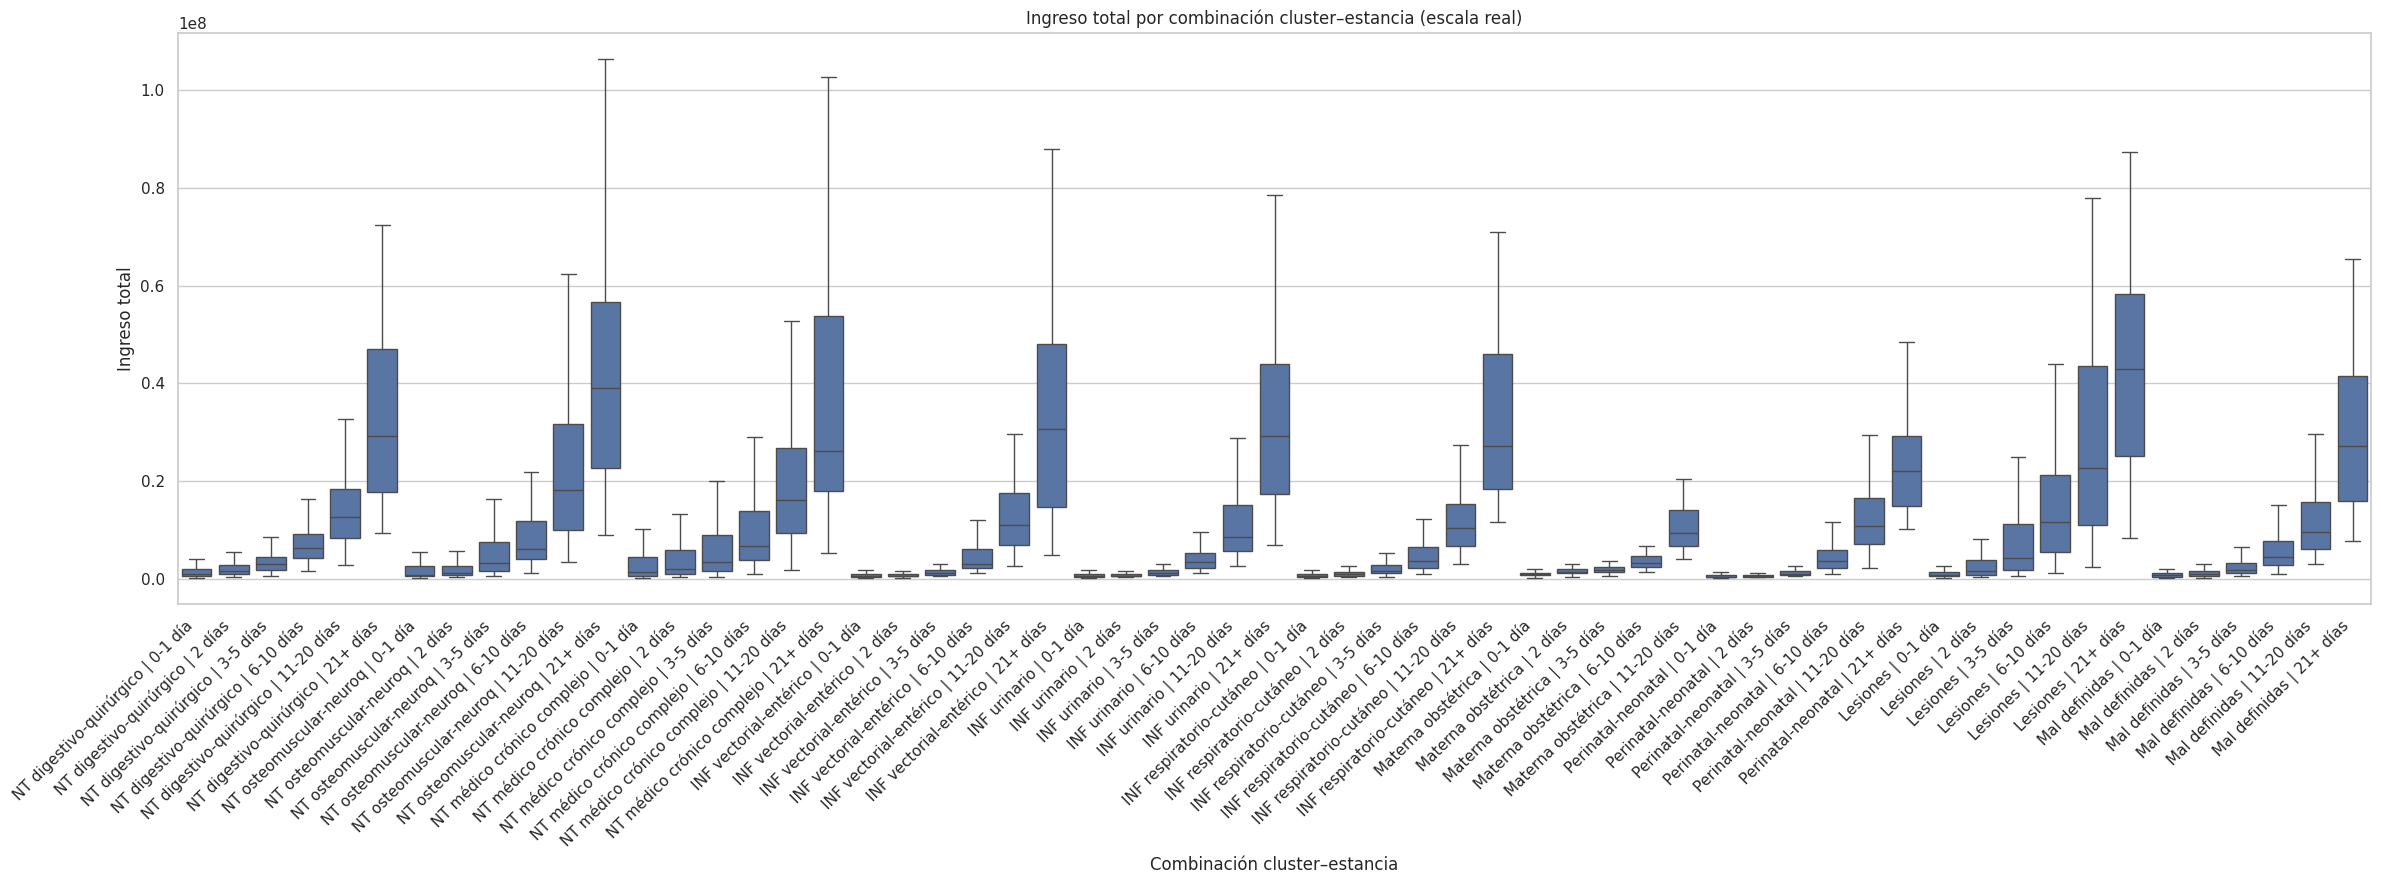

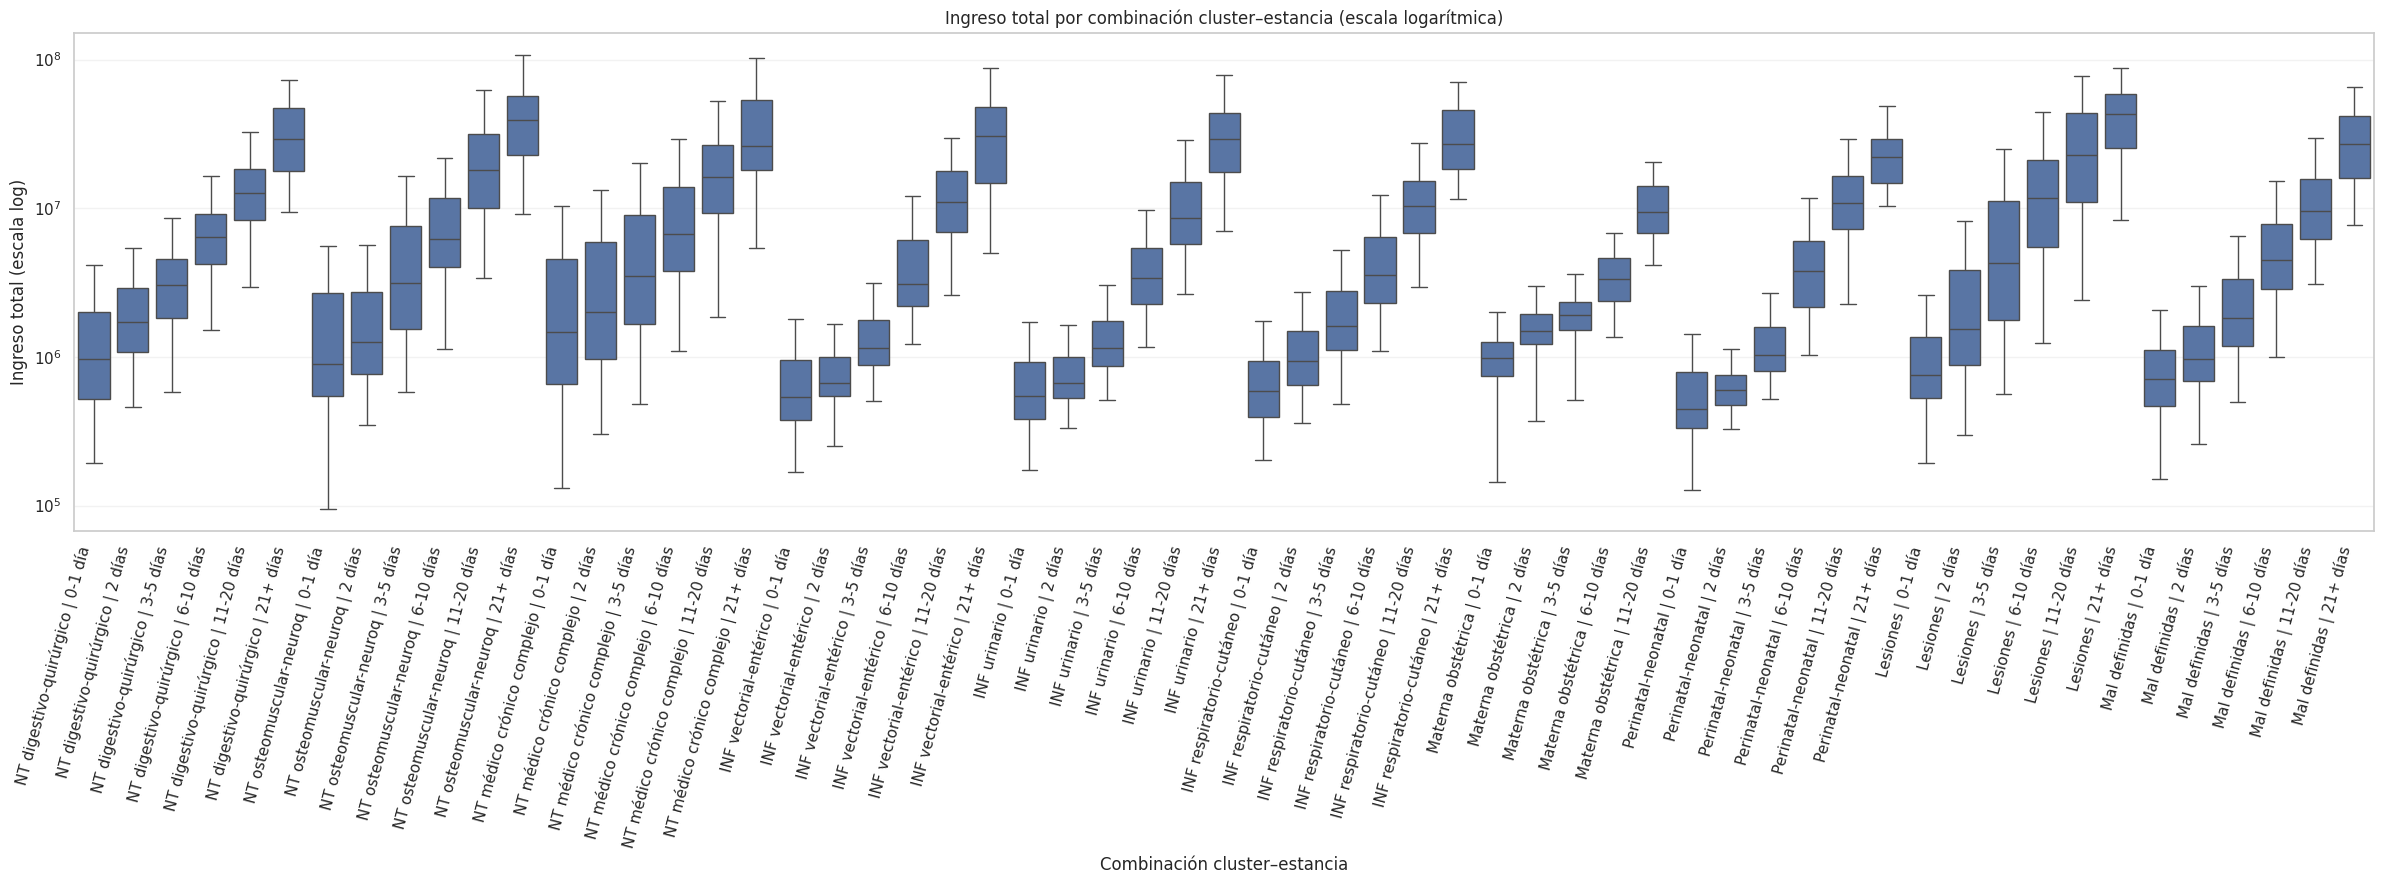

In [ ]:
# =========================================================
# BOXPLOT GENERAL POR COMBINACIÓN CLUSTER–ESTANCIA
# =========================================================

# ---------- Versión en escala real ----------
plt.figure(figsize=(24, 9))
sns.boxplot(
    data=df_box,
    x="_combo_cluster_estancia",
    y="_y",
    showfliers=False
)
plt.title("Ingreso total por combinación cluster–estancia (escala real)")
plt.xlabel("Combinación cluster–estancia")
plt.ylabel("Ingreso total")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------- Versión en escala logarítmica ----------
plt.figure(figsize=(24, 9))
sns.boxplot(
    data=df_box,
    x="_combo_cluster_estancia",
    y="_y",
    showfliers=False
)
plt.yscale("log")
plt.title("Ingreso total por combinación cluster–estancia (escala logarítmica)")
plt.xlabel("Combinación cluster–estancia")
plt.ylabel("Ingreso total (escala log)")
plt.xticks(rotation=75, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

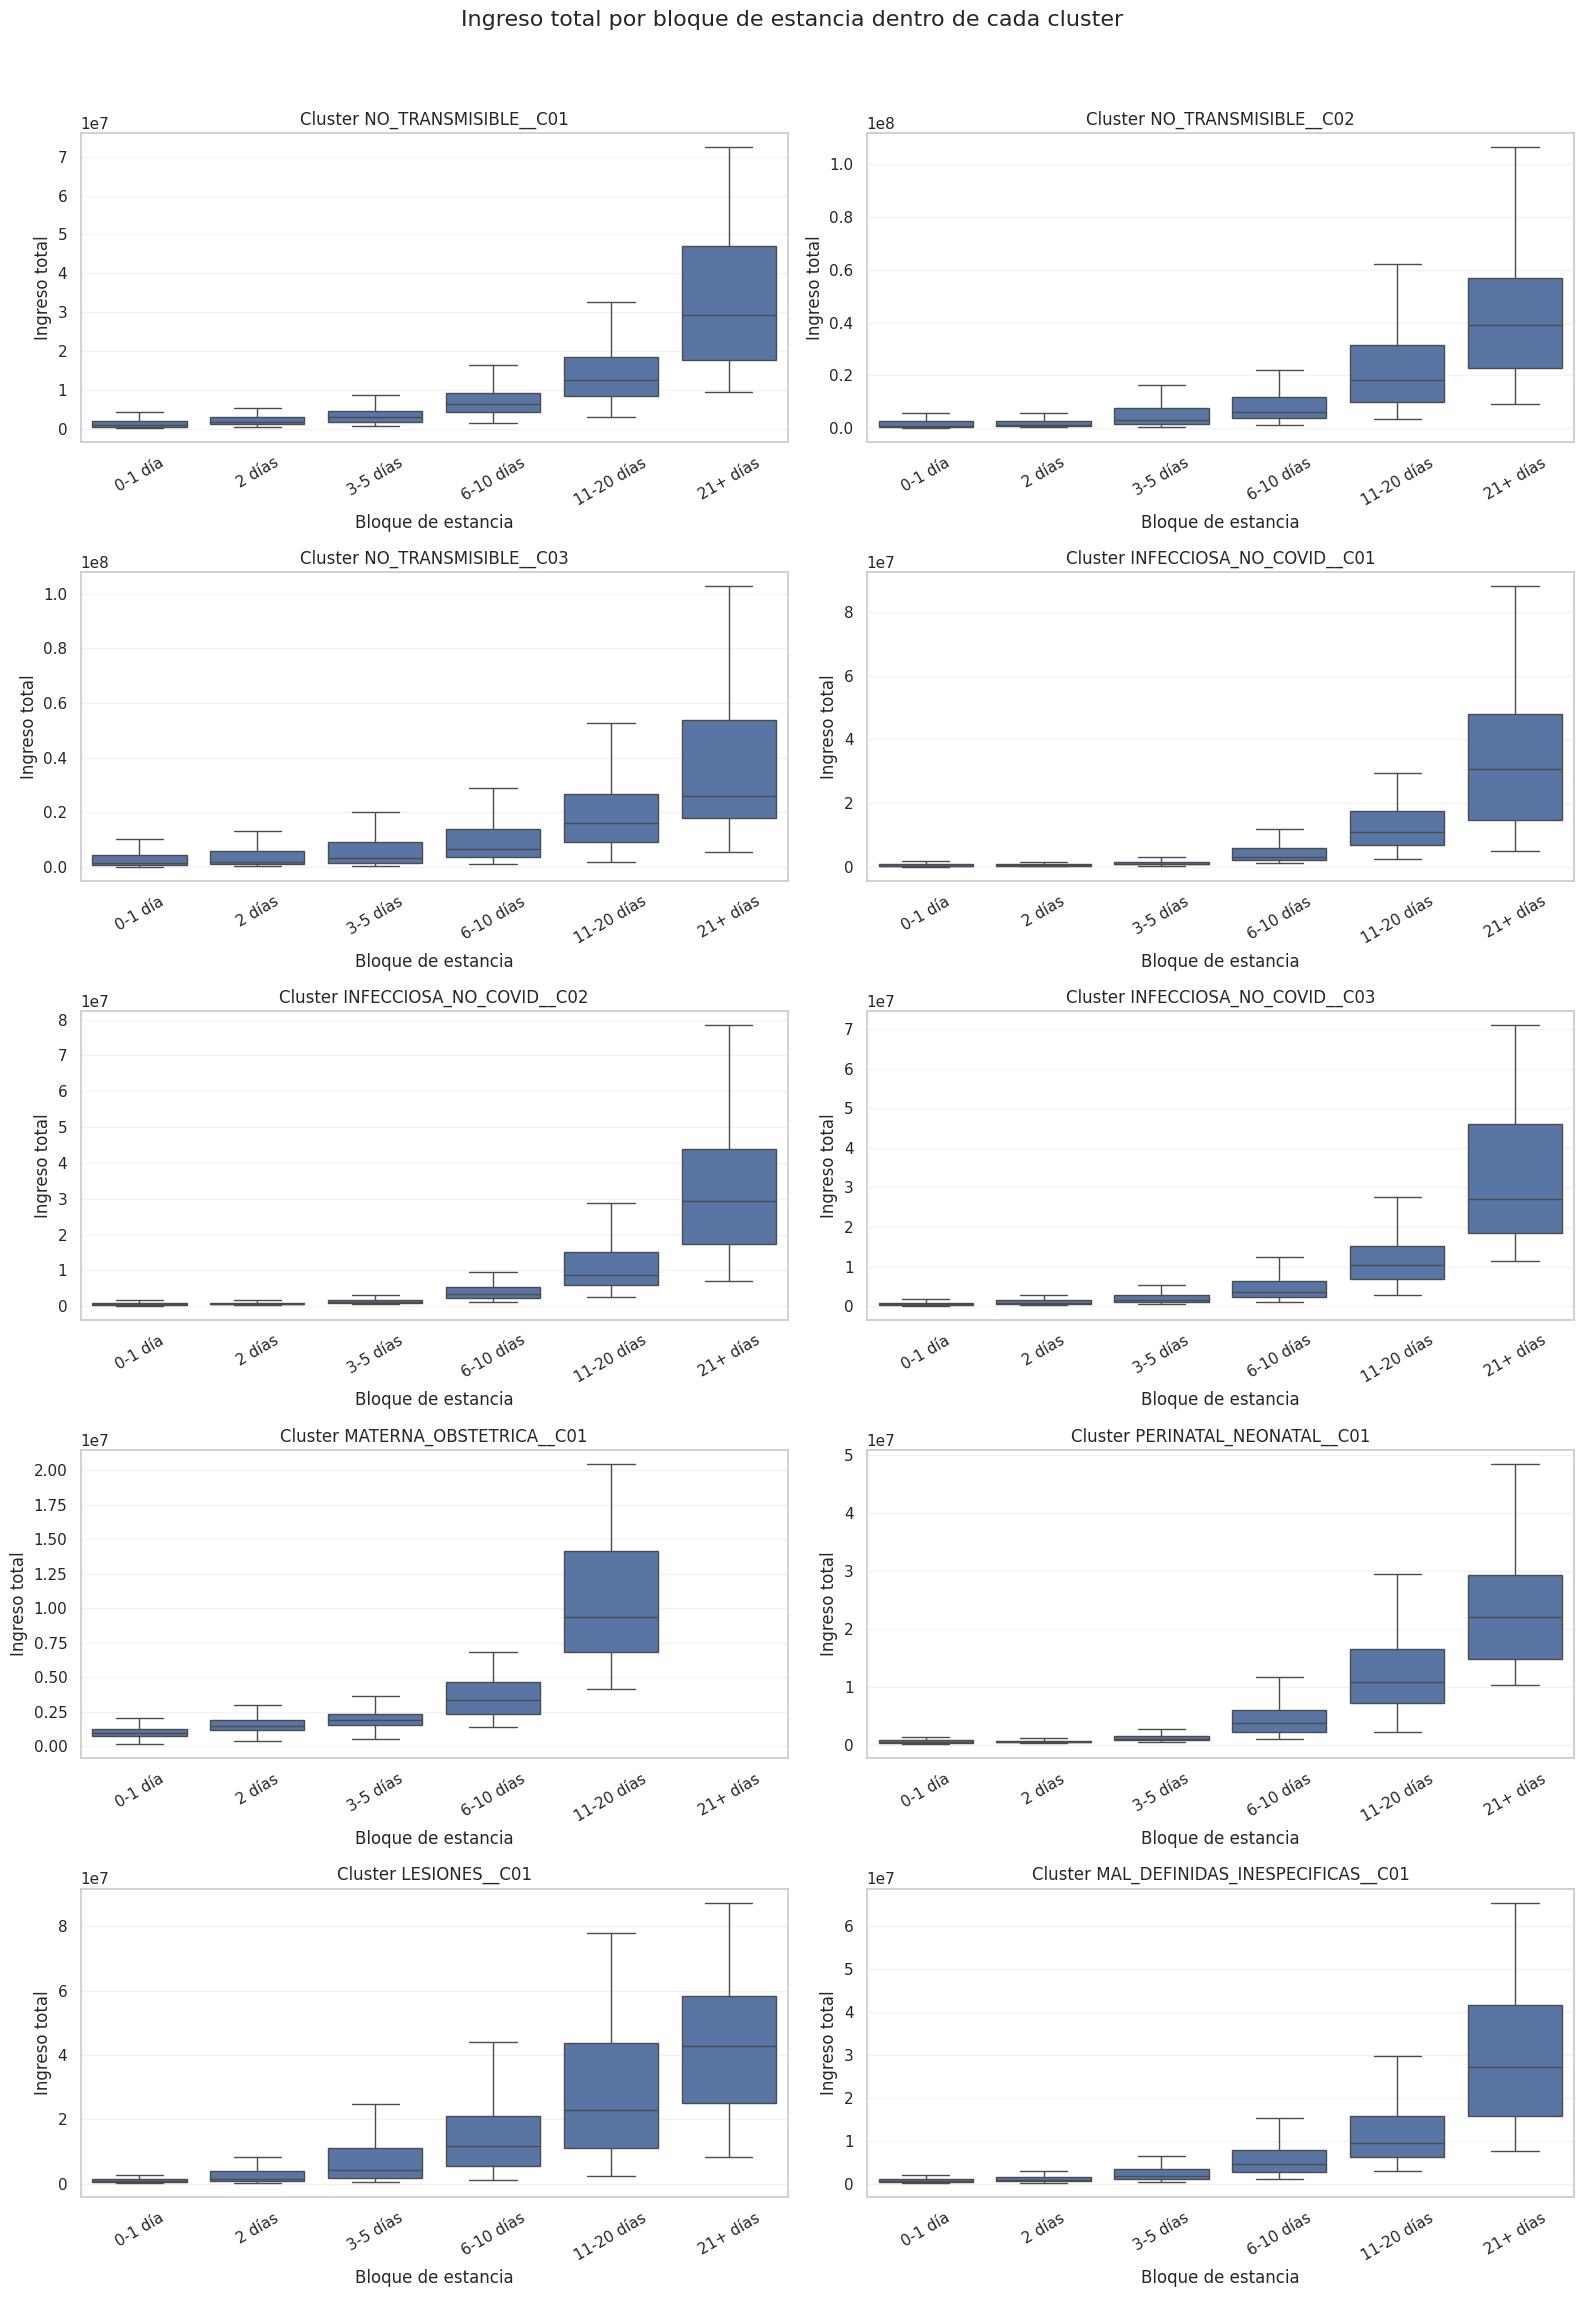

In [ ]:
# =========================================================
# BOXPLOTS FACETADOS POR CLUSTER
# =========================================================

n_clusters = len(orden_clusters)
ncols = 2
nrows = int(np.ceil(n_clusters / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for i, c in enumerate(orden_clusters):
    ax = axes[i]
    sub = df_box[df_box["_cluster"] == c].copy()

    sns.boxplot(
        data=sub,
        x="_bloque_estancia",
        y="_y",
        order=orden_estancia,
        showfliers=False,
        ax=ax
    )

    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("Bloque de estancia")
    ax.set_ylabel("Ingreso total")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

# Apagar ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Ingreso total por bloque de estancia dentro de cada cluster", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

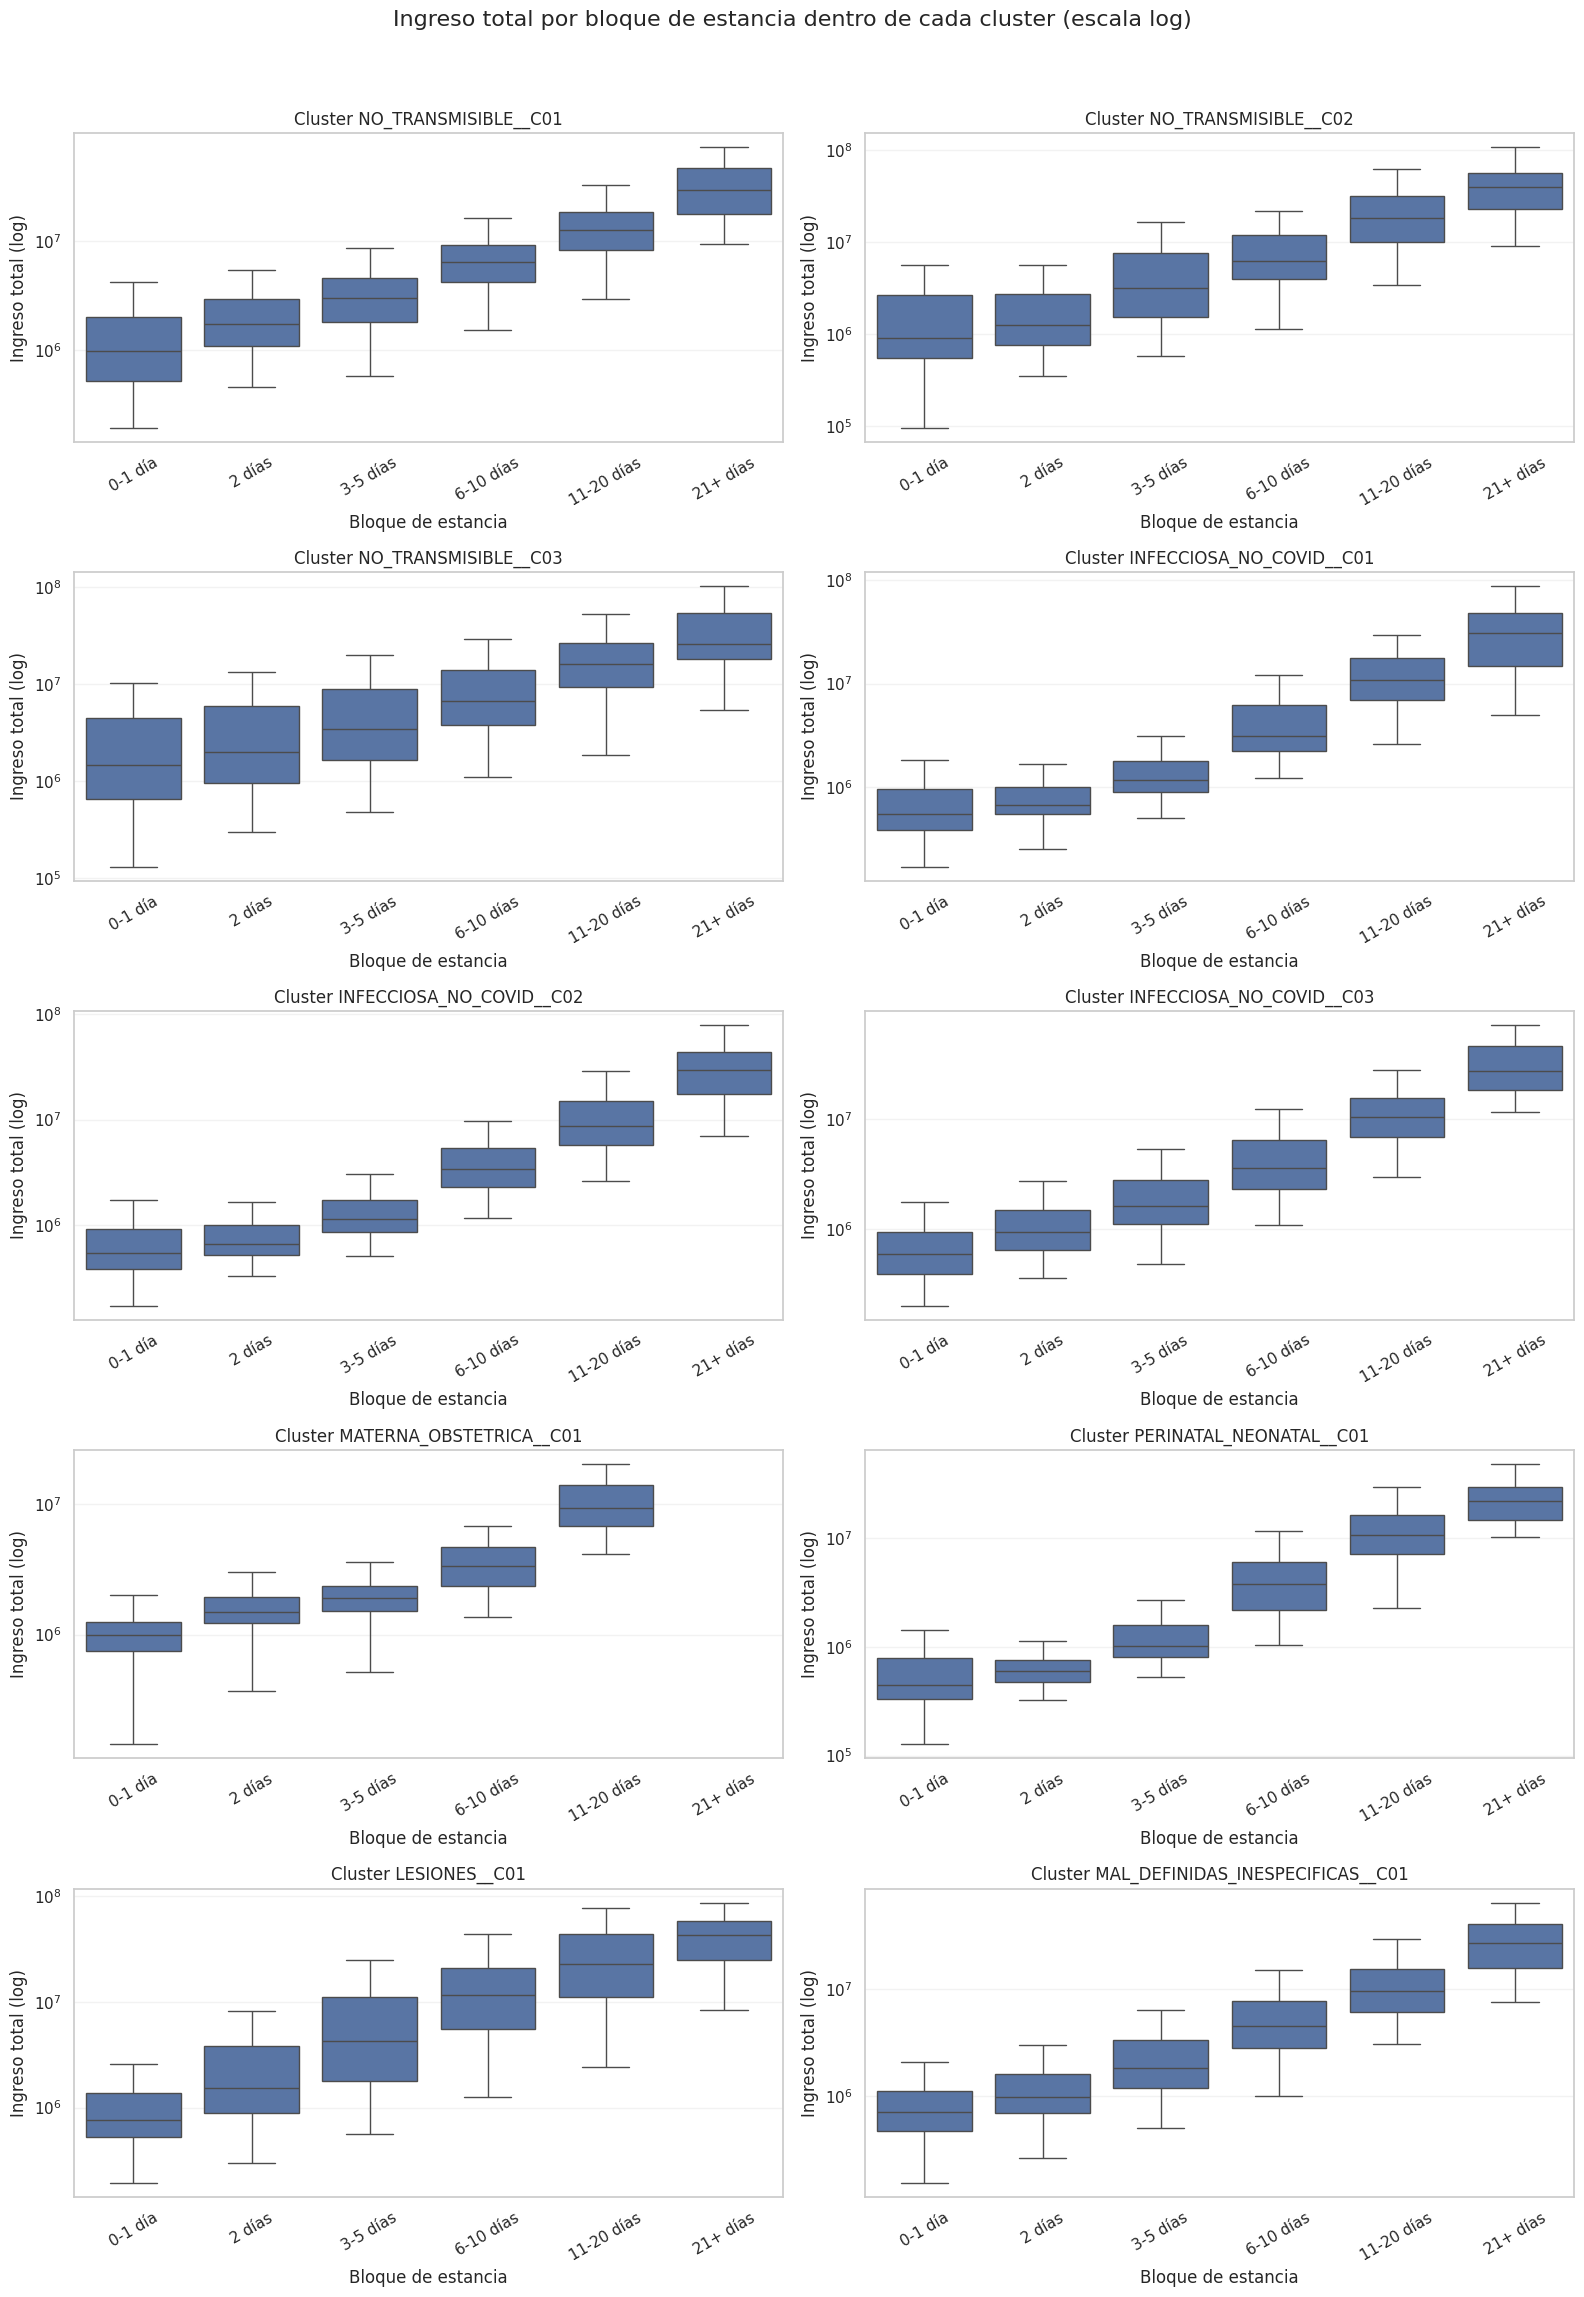

In [ ]:
# =========================================================
# BOXPLOTS FACETADOS POR CLUSTER - ESCALA LOG
# =========================================================

n_clusters = len(orden_clusters)
ncols = 2
nrows = int(np.ceil(n_clusters / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.5 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for i, c in enumerate(orden_clusters):
    ax = axes[i]
    sub = df_box[df_box["_cluster"] == c].copy()

    sns.boxplot(
        data=sub,
        x="_bloque_estancia",
        y="_y",
        order=orden_estancia,
        showfliers=False,
        ax=ax
    )

    ax.set_yscale("log")
    ax.set_title(f"Cluster {c}")
    ax.set_xlabel("Bloque de estancia")
    ax.set_ylabel("Ingreso total (log)")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Ingreso total por bloque de estancia dentro de cada cluster (escala log)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# TABLA RESUMEN PARA ACOMPAÑAR BOXPLOTS
# =========================================================

tabla_boxplot = (
    df_box.groupby(["_cluster", "_bloque_estancia", "_combo_cluster_estancia"], observed=True)
    .agg(
        n=("_y", "size"),
        ingreso_mediano=("_y", "median"),
        p25=("_y", lambda x: np.nanpercentile(x, 25)),
        p75=("_y", lambda x: np.nanpercentile(x, 75))
    )
    .reset_index()
)

tabla_boxplot["IQR"] = tabla_boxplot["p75"] - tabla_boxplot["p25"]

tabla_boxplot = tabla_boxplot.sort_values(
    ["_cluster", "_bloque_estancia"],
    ascending=[True, True]
).reset_index(drop=True)

display(tabla_boxplot)

,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_mediano,p25,p75,IQR
0,NO_TRANSMISIBLE__C01,0-1 día,NT digestivo-quirúrgico | 0-1 día,472,969233.0,518389.25,2006669.50,1488280.25
1,NO_TRANSMISIBLE__C01,2 días,NT digestivo-quirúrgico | 2 días,311,1717290.0,1084835.00,2918483.00,1833648.00
2,NO_TRANSMISIBLE__C01,3-5 días,NT digestivo-quirúrgico | 3-5 días,517,3024690.0,1819356.00,4544810.00,2725454.00
3,NO_TRANSMISIBLE__C01,6-10 días,NT digestivo-quirúrgico | 6-10 días,392,6382624.5,4210796.00,9119545.00,4908749.00
4,NO_TRANSMISIBLE__C01,11-20 días,NT digestivo-quirúrgico | 11-20 días,134,12643346.0,8313193.75,18396451.00,10083257.25
5,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,29337195.0,17732250.00,47038172.75,29305922.75
6,NO_TRANSMISIBLE__C02,0-1 día,NT osteomuscular-neuroq | 0-1 día,1223,900190.0,543330.00,2679006.50,2135676.50
7,NO_TRANSMISIBLE__C02,2 días,NT osteomuscular-neuroq | 2 días,403,1261360.0,765352.00,2716730.00,1951378.00
8,NO_TRANSMISIBLE__C02,3-5 días,NT osteomuscular-neuroq | 3-5 días,523,3157460.0,1537470.00,7624930.50,6087460.50
9,NO_TRANSMISIBLE__C02,6-10 días,NT osteomuscular-neuroq | 6-10 días,316,6202160.5,3998691.75,11800032.00,7801340.25


In [ ]:
# =========================================================
# PASO 5A) TABLA FORMAL DE VARIABILIDAD POR COMBINACIÓN
# =========================================================

tabla_variabilidad = (
    df_box.groupby(["_cluster", "_bloque_estancia", "_combo_cluster_estancia"], observed=True)
    .agg(
        n=("_y", "size"),
        ingreso_medio=("_y", "mean"),
        ingreso_mediano=("_y", "median"),
        p25=("_y", lambda x: np.nanpercentile(x, 25)),
        p75=("_y", lambda x: np.nanpercentile(x, 75)),
        sd=("_y", "std"),
        minimo=("_y", "min"),
        maximo=("_y", "max")
    )
    .reset_index()
)

tabla_variabilidad["IQR"] = tabla_variabilidad["p75"] - tabla_variabilidad["p25"]
tabla_variabilidad["cv"] = np.where(
    tabla_variabilidad["ingreso_medio"] > 0,
    tabla_variabilidad["sd"] / tabla_variabilidad["ingreso_medio"],
    np.nan
)

# Algunas métricas extra útiles
tabla_variabilidad["p10"] = (
    df_box.groupby(["_cluster", "_bloque_estancia"], observed=True)["_y"]
    .quantile(0.10)
    .values
)
tabla_variabilidad["p90"] = (
    df_box.groupby(["_cluster", "_bloque_estancia"], observed=True)["_y"]
    .quantile(0.90)
    .values
)
tabla_variabilidad["rango_p90_p10"] = tabla_variabilidad["p90"] - tabla_variabilidad["p10"]

tabla_variabilidad = tabla_variabilidad.sort_values(
    ["_cluster", "_bloque_estancia"]
).reset_index(drop=True)

print("=== TABLA FORMAL DE VARIABILIDAD ===")
display(tabla_variabilidad)

=== TABLA FORMAL DE VARIABILIDAD ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv,p10,p90,rango_p90_p10
0,NO_TRANSMISIBLE__C01,0-1 día,NT digestivo-quirúrgico | 0-1 día,472,2.464444e+06,969233.0,518389.25,2006669.50,5.647752e+06,192420,51905768,1488280.25,2.291694,355630.0,4524055.6,4168425.6
1,NO_TRANSMISIBLE__C01,2 días,NT digestivo-quirúrgico | 2 días,311,2.864085e+06,1717290.0,1084835.00,2918483.00,3.699365e+06,460282,26310666,1833648.00,1.291639,667290.0,6359370.0,5692080.0
2,NO_TRANSMISIBLE__C01,3-5 días,NT digestivo-quirúrgico | 3-5 días,517,4.019128e+06,3024690.0,1819356.00,4544810.00,4.100253e+06,580463,60988470,2725454.00,1.020185,1242510.8,7963694.2,6721183.4
3,NO_TRANSMISIBLE__C01,6-10 días,NT digestivo-quirúrgico | 6-10 días,392,7.620922e+06,6382624.5,4210796.00,9119545.00,1.032692e+07,1522280,194357872,4908749.00,1.355075,2700379.0,12421154.8,9720775.8
4,NO_TRANSMISIBLE__C01,11-20 días,NT digestivo-quirúrgico | 11-20 días,134,1.463973e+07,12643346.0,8313193.75,18396451.00,8.873916e+06,2946670,43399908,10083257.25,0.606153,5349996.0,26060009.2,20710013.2
5,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,17732250.00,47038172.75,2.327737e+07,9461870,131330608,29305922.75,0.665875,11816634.3,54694009.0,42877374.7
6,NO_TRANSMISIBLE__C02,0-1 día,NT osteomuscular-neuroq | 0-1 día,1223,4.436875e+06,900190.0,543330.00,2679006.50,1.083603e+07,95550,107887829,2135676.50,2.442267,394374.0,13002686.8,12608312.8
7,NO_TRANSMISIBLE__C02,2 días,NT osteomuscular-neuroq | 2 días,403,3.172914e+06,1261360.0,765352.00,2716730.00,8.160126e+06,350120,102493934,1951378.00,2.571808,561608.0,4943101.8,4381493.8
8,NO_TRANSMISIBLE__C02,3-5 días,NT osteomuscular-neuroq | 3-5 días,523,7.657944e+06,3157460.0,1537470.00,7624930.50,1.346561e+07,579530,107826314,6087460.50,1.758385,1103502.0,15607604.0,14504102.0
9,NO_TRANSMISIBLE__C02,6-10 días,NT osteomuscular-neuroq | 6-10 días,316,1.160612e+07,6202160.5,3998691.75,11800032.00,1.550381e+07,1127890,102139988,7801340.25,1.335831,2327915.0,25555378.5,23227463.5


In [ ]:
# =========================================================
# RANKINGS DE VARIABILIDAD
# =========================================================

print("=== TOP 15 POR IQR ===")
display(
    tabla_variabilidad.sort_values(["IQR", "n"], ascending=[False, False]).head(15)
)

print("=== TOP 15 POR DESVIACIÓN ESTÁNDAR ===")
display(
    tabla_variabilidad.sort_values(["sd", "n"], ascending=[False, False]).head(15)
)

print("=== TOP 15 POR COEFICIENTE DE VARIACIÓN ===")
display(
    tabla_variabilidad.sort_values(["cv", "n"], ascending=[False, False]).head(15)
)

print("=== TOP 15 POR RANGO P90 - P10 ===")
display(
    tabla_variabilidad.sort_values(["rango_p90_p10", "n"], ascending=[False, False]).head(15)
)

=== TOP 15 POR IQR ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv,p10,p90,rango_p90_p10
17,NO_TRANSMISIBLE__C03,21+ días,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,18035572.00,53804923.00,5.600309e+07,5390183,509569621,35769351.00,1.234350,13313040.0,90400069.0,77087029.0
11,NO_TRANSMISIBLE__C02,21+ días,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,22690877.25,56760329.50,4.338593e+07,9080210,218395627,34069452.25,0.875824,10935427.0,106591539.3,95656112.3
23,INFECCIOSA_NO_COVID__C01,21+ días,INF vectorial-entérico | 21+ días,41,4.106568e+07,30599247.0,14726325.00,47980471.00,3.904603e+07,4965819,199185400,33254146.00,0.950819,9867823.0,87962720.0,78094897.0
52,LESIONES__C01,21+ días,Lesiones | 21+ días,31,4.642992e+07,42904397.0,25242143.00,58268878.00,3.023534e+07,8345640,118879104,33026735.00,0.651204,12665006.0,87435755.0,74770749.0
51,LESIONES__C01,11-20 días,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,11041040.00,43663872.50,2.168655e+07,2408879,107534494,32622832.50,0.761505,6120030.5,60613753.5,54493723.0
5,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,17732250.00,47038172.75,2.327737e+07,9461870,131330608,29305922.75,0.665875,11816634.3,54694009.0,42877374.7
35,INFECCIOSA_NO_COVID__C03,21+ días,INF respiratorio-cutáneo | 21+ días,24,4.111569e+07,27194492.0,18422335.50,46011582.75,3.481797e+07,11547110,126736906,27589247.25,0.846829,12726916.0,102372687.3,89645771.3
29,INFECCIOSA_NO_COVID__C02,21+ días,INF urinario | 21+ días,30,3.949893e+07,29228939.5,17428413.00,43884696.00,3.301743e+07,7017600,130901010,26456283.00,0.835907,11575389.7,91058323.0,79482933.3
58,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Mal definidas | 21+ días,25,2.876247e+07,27200966.0,15867124.00,41620982.00,1.658686e+07,7692885,65569379,25753858.00,0.576684,10721235.2,51893749.4,41172514.2
10,NO_TRANSMISIBLE__C02,11-20 días,NT osteomuscular-neuroq | 11-20 días,145,2.617172e+07,18120550.0,9960514.00,31621323.00,2.650192e+07,3395720,161583442,21660809.00,1.012617,5198177.0,59463862.2,54265685.2


=== TOP 15 POR DESVIACIÓN ESTÁNDAR ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv,p10,p90,rango_p90_p10
17,NO_TRANSMISIBLE__C03,21+ días,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,18035572.00,53804923.00,5.600309e+07,5390183,509569621,35769351.00,1.234350,13313040.0,90400069.0,77087029.0
11,NO_TRANSMISIBLE__C02,21+ días,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,22690877.25,56760329.50,4.338593e+07,9080210,218395627,34069452.25,0.875824,10935427.0,106591539.3,95656112.3
23,INFECCIOSA_NO_COVID__C01,21+ días,INF vectorial-entérico | 21+ días,41,4.106568e+07,30599247.0,14726325.00,47980471.00,3.904603e+07,4965819,199185400,33254146.00,0.950819,9867823.0,87962720.0,78094897.0
35,INFECCIOSA_NO_COVID__C03,21+ días,INF respiratorio-cutáneo | 21+ días,24,4.111569e+07,27194492.0,18422335.50,46011582.75,3.481797e+07,11547110,126736906,27589247.25,0.846829,12726916.0,102372687.3,89645771.3
29,INFECCIOSA_NO_COVID__C02,21+ días,INF urinario | 21+ días,30,3.949893e+07,29228939.5,17428413.00,43884696.00,3.301743e+07,7017600,130901010,26456283.00,0.835907,11575389.7,91058323.0,79482933.3
52,LESIONES__C01,21+ días,Lesiones | 21+ días,31,4.642992e+07,42904397.0,25242143.00,58268878.00,3.023534e+07,8345640,118879104,33026735.00,0.651204,12665006.0,87435755.0,74770749.0
10,NO_TRANSMISIBLE__C02,11-20 días,NT osteomuscular-neuroq | 11-20 días,145,2.617172e+07,18120550.0,9960514.00,31621323.00,2.650192e+07,3395720,161583442,21660809.00,1.012617,5198177.0,59463862.2,54265685.2
5,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,17732250.00,47038172.75,2.327737e+07,9461870,131330608,29305922.75,0.665875,11816634.3,54694009.0,42877374.7
51,LESIONES__C01,11-20 días,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,11041040.00,43663872.50,2.168655e+07,2408879,107534494,32622832.50,0.761505,6120030.5,60613753.5,54493723.0
16,NO_TRANSMISIBLE__C03,11-20 días,NT médico crónico complejo | 11-20 días,657,2.111532e+07,16221530.0,9323026.00,26745473.00,1.760282e+07,1865500,126616400,17422447.00,0.833652,6182665.2,43249322.0,37066656.8


=== TOP 15 POR COEFICIENTE DE VARIACIÓN ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv,p10,p90,rango_p90_p10
47,LESIONES__C01,0-1 día,Lesiones | 0-1 día,342,2.386942e+06,761417.0,526612.50,1363217.75,7.669644e+06,192486,97222030,836605.25,3.213168,374030.6,3787856.7,3413826.1
53,MAL_DEFINIDAS_INESPECIFICAS__C01,0-1 día,Mal definidas | 0-1 día,1475,1.281148e+06,705900.0,470545.00,1116427.50,3.328480e+06,151690,86927472,645882.50,2.598044,360054.0,2073775.2,1713721.2
7,NO_TRANSMISIBLE__C02,2 días,NT osteomuscular-neuroq | 2 días,403,3.172914e+06,1261360.0,765352.00,2716730.00,8.160126e+06,350120,102493934,1951378.00,2.571808,561608.0,4943101.8,4381493.8
6,NO_TRANSMISIBLE__C02,0-1 día,NT osteomuscular-neuroq | 0-1 día,1223,4.436875e+06,900190.0,543330.00,2679006.50,1.083603e+07,95550,107887829,2135676.50,2.442267,394374.0,13002686.8,12608312.8
42,PERINATAL_NEONATAL__C01,2 días,Perinatal-neonatal | 2 días,73,1.184714e+06,595891.0,472910.00,759409.00,2.782937e+06,327790,22704858,286499.00,2.349037,381959.2,1858992.0,1477032.8
0,NO_TRANSMISIBLE__C01,0-1 día,NT digestivo-quirúrgico | 0-1 día,472,2.464444e+06,969233.0,518389.25,2006669.50,5.647752e+06,192420,51905768,1488280.25,2.291694,355630.0,4524055.6,4168425.6
48,LESIONES__C01,2 días,Lesiones | 2 días,196,4.929920e+06,1535101.0,880545.50,3853916.50,9.842471e+06,299300,80466310,2973371.00,1.996477,591161.0,10986855.0,10395694.0
8,NO_TRANSMISIBLE__C02,3-5 días,NT osteomuscular-neuroq | 3-5 días,523,7.657944e+06,3157460.0,1537470.00,7624930.50,1.346561e+07,579530,107826314,6087460.50,1.758385,1103502.0,15607604.0,14504102.0
56,MAL_DEFINIDAS_INESPECIFICAS__C01,6-10 días,Mal definidas | 6-10 días,302,6.844331e+06,4503661.5,2844465.50,7817649.25,1.188645e+07,999890,190456687,4973183.75,1.736686,1974894.1,12565965.2,10591071.1
20,INFECCIOSA_NO_COVID__C01,3-5 días,INF vectorial-entérico | 3-5 días,572,1.881427e+06,1151232.0,882807.00,1781489.00,3.104217e+06,501770,54033334,898682.00,1.649927,741006.2,3353436.9,2612430.7


=== TOP 15 POR RANGO P90 - P10 ===


,_cluster,_bloque_estancia,_combo_cluster_estancia,n,ingreso_medio,ingreso_mediano,p25,p75,sd,minimo,maximo,IQR,cv,p10,p90,rango_p90_p10
11,NO_TRANSMISIBLE__C02,21+ días,NT osteomuscular-neuroq | 21+ días,50,4.953729e+07,39121468.5,22690877.25,56760329.50,4.338593e+07,9080210,218395627,34069452.25,0.875824,10935427.0,106591539.3,95656112.3
35,INFECCIOSA_NO_COVID__C03,21+ días,INF respiratorio-cutáneo | 21+ días,24,4.111569e+07,27194492.0,18422335.50,46011582.75,3.481797e+07,11547110,126736906,27589247.25,0.846829,12726916.0,102372687.3,89645771.3
29,INFECCIOSA_NO_COVID__C02,21+ días,INF urinario | 21+ días,30,3.949893e+07,29228939.5,17428413.00,43884696.00,3.301743e+07,7017600,130901010,26456283.00,0.835907,11575389.7,91058323.0,79482933.3
23,INFECCIOSA_NO_COVID__C01,21+ días,INF vectorial-entérico | 21+ días,41,4.106568e+07,30599247.0,14726325.00,47980471.00,3.904603e+07,4965819,199185400,33254146.00,0.950819,9867823.0,87962720.0,78094897.0
17,NO_TRANSMISIBLE__C03,21+ días,NT médico crónico complejo | 21+ días,261,4.537052e+07,26097675.0,18035572.00,53804923.00,5.600309e+07,5390183,509569621,35769351.00,1.234350,13313040.0,90400069.0,77087029.0
52,LESIONES__C01,21+ días,Lesiones | 21+ días,31,4.642992e+07,42904397.0,25242143.00,58268878.00,3.023534e+07,8345640,118879104,33026735.00,0.651204,12665006.0,87435755.0,74770749.0
51,LESIONES__C01,11-20 días,Lesiones | 11-20 días,106,2.847853e+07,22784339.0,11041040.00,43663872.50,2.168655e+07,2408879,107534494,32622832.50,0.761505,6120030.5,60613753.5,54493723.0
10,NO_TRANSMISIBLE__C02,11-20 días,NT osteomuscular-neuroq | 11-20 días,145,2.617172e+07,18120550.0,9960514.00,31621323.00,2.650192e+07,3395720,161583442,21660809.00,1.012617,5198177.0,59463862.2,54265685.2
5,NO_TRANSMISIBLE__C01,21+ días,NT digestivo-quirúrgico | 21+ días,38,3.495755e+07,29337195.0,17732250.00,47038172.75,2.327737e+07,9461870,131330608,29305922.75,0.665875,11816634.3,54694009.0,42877374.7
58,MAL_DEFINIDAS_INESPECIFICAS__C01,21+ días,Mal definidas | 21+ días,25,2.876247e+07,27200966.0,15867124.00,41620982.00,1.658686e+07,7692885,65569379,25753858.00,0.576684,10721235.2,51893749.4,41172514.2


In [ ]:
# =========================================================
# PASO 5B) PRUEBA GLOBAL DE HETEROGENEIDAD DE VARIANZAS
# =========================================================

from scipy.stats import levene

# Crear grupos por combinación
grupos_combo = []
labels_combo = []

for combo, sub in df_box.groupby("_combo_cluster_estancia", observed=True):
    vals = sub["_y"].dropna().values
    if len(vals) >= 10:
        grupos_combo.append(vals)
        labels_combo.append(combo)

# Levene clásico
stat_lev, p_lev = levene(*grupos_combo, center="mean")

# Brown-Forsythe (más robusto)
stat_bf, p_bf = levene(*grupos_combo, center="median")

print("=== PRUEBA GLOBAL DE HETEROGENEIDAD ENTRE COMBINACIONES ===")
print(f"Número de combinaciones comparadas: {len(grupos_combo)}")
print(f"Levene (center='mean'): estadístico={stat_lev:.4f}, p={p_lev:.6g}")
print(f"Brown-Forsythe (center='median'): estadístico={stat_bf:.4f}, p={p_bf:.6g}")

if p_bf < 0.05:
    print("Conclusión: se rechaza la igualdad de varianzas entre combinaciones cluster–estancia.")
else:
    print("Conclusión: no hay evidencia suficiente para afirmar que las varianzas difieren entre combinaciones.")

=== PRUEBA GLOBAL DE HETEROGENEIDAD ENTRE COMBINACIONES ===
Número de combinaciones comparadas: 59
Levene (center='mean'): estadístico=157.7700, p=0
Brown-Forsythe (center='median'): estadístico=94.9010, p=0
Conclusión: se rechaza la igualdad de varianzas entre combinaciones cluster–estancia.


In [ ]:
# =========================================================
# HETEROGENEIDAD ENTRE CLUSTERS DENTRO DE CADA ESTANCIA
# =========================================================

resultados_var_A = []

for estancia, sub_est in df_box.groupby("_bloque_estancia", observed=True):
    grupos = []
    grupos_nombres = []

    for cluster, sub in sub_est.groupby("_cluster", observed=True):
        vals = sub["_y"].dropna().values
        if len(vals) >= 10:
            grupos.append(vals)
            grupos_nombres.append(cluster)

    if len(grupos) >= 2:
        stat_lev, p_lev = levene(*grupos, center="mean")
        stat_bf, p_bf = levene(*grupos, center="median")

        resultados_var_A.append({
            "bloque_estancia": estancia,
            "n_grupos_comparados": len(grupos),
            "levene_stat": stat_lev,
            "levene_p": p_lev,
            "brown_forsythe_stat": stat_bf,
            "brown_forsythe_p": p_bf,
            "decision_bf": "Varianzas diferentes" if p_bf < 0.05 else "Sin evidencia suficiente"
        })

tabla_var_A = pd.DataFrame(resultados_var_A).sort_values("brown_forsythe_p").reset_index(drop=True)

print("=== HETEROGENEIDAD ENTRE CLUSTERS DENTRO DE CADA ESTANCIA ===")
display(tabla_var_A)

=== HETEROGENEIDAD ENTRE CLUSTERS DENTRO DE CADA ESTANCIA ===


,bloque_estancia,n_grupos_comparados,levene_stat,levene_p,brown_forsythe_stat,brown_forsythe_p,decision_bf
0,3-5 días,10,165.121729,6.579144e-284,80.589475,1.229979e-142,Varianzas diferentes
1,2 días,10,142.352763,7.296664e-244,67.659712,4.832049e-119,Varianzas diferentes
2,0-1 día,10,140.056908,6.732269e-247,56.410494,1.931442e-100,Varianzas diferentes
3,6-10 días,10,40.216787,1.614293e-68,22.571768,1.282078e-37,Varianzas diferentes
4,11-20 días,10,20.241660,1.685255e-32,13.354088,8.582311e-21,Varianzas diferentes
5,21+ días,9,2.949626,3.094310e-03,1.426517,1.823830e-01,Sin evidencia suficiente


In [ ]:
# =========================================================
# HETEROGENEIDAD ENTRE ESTANCIAS DENTRO DE CADA CLUSTER
# =========================================================

resultados_var_B = []

for cluster, sub_cluster in df_box.groupby("_cluster", observed=True):
    grupos = []
    grupos_nombres = []

    for estancia, sub in sub_cluster.groupby("_bloque_estancia", observed=True):
        vals = sub["_y"].dropna().values
        if len(vals) >= 10:
            grupos.append(vals)
            grupos_nombres.append(estancia)

    if len(grupos) >= 2:
        stat_lev, p_lev = levene(*grupos, center="mean")
        stat_bf, p_bf = levene(*grupos, center="median")

        resultados_var_B.append({
            "cluster": cluster,
            "n_grupos_comparados": len(grupos),
            "levene_stat": stat_lev,
            "levene_p": p_lev,
            "brown_forsythe_stat": stat_bf,
            "brown_forsythe_p": p_bf,
            "decision_bf": "Varianzas diferentes" if p_bf < 0.05 else "Sin evidencia suficiente"
        })

tabla_var_B = pd.DataFrame(resultados_var_B).sort_values("brown_forsythe_p").reset_index(drop=True)

print("=== HETEROGENEIDAD ENTRE ESTANCIAS DENTRO DE CADA CLUSTER ===")
display(tabla_var_B)

=== HETEROGENEIDAD ENTRE ESTANCIAS DENTRO DE CADA CLUSTER ===


,cluster,n_grupos_comparados,levene_stat,levene_p,brown_forsythe_stat,brown_forsythe_p,decision_bf
0,INFECCIOSA_NO_COVID__C02,6,333.448973,5.070486e-253,209.794316,1.753381e-176,Varianzas diferentes
1,NO_TRANSMISIBLE__C03,6,281.284916,2.338395e-275,166.049658,1.668330e-167,Varianzas diferentes
2,INFECCIOSA_NO_COVID__C03,6,330.545376,3.963442e-252,160.645077,1.286479e-141,Varianzas diferentes
3,INFECCIOSA_NO_COVID__C01,6,217.684708,1.075442e-179,147.822889,1.797352e-130,Varianzas diferentes
4,MATERNA_OBSTETRICA__C01,5,217.414258,6.924472e-170,143.993818,1.437798e-115,Varianzas diferentes
5,MAL_DEFINIDAS_INESPECIFICAS__C01,6,102.227878,1.438804e-100,82.151314,1.501099e-81,Varianzas diferentes
6,NO_TRANSMISIBLE__C02,6,79.880799,2.800753e-78,56.063285,1.482298e-55,Varianzas diferentes
7,LESIONES__C01,6,67.014548,2.225286e-61,52.763614,2.834120e-49,Varianzas diferentes
8,NO_TRANSMISIBLE__C01,6,53.785031,2.809157e-52,49.047449,8.220040e-48,Varianzas diferentes
9,PERINATAL_NEONATAL__C01,6,60.002232,1.056527e-50,53.055678,1.267481e-45,Varianzas diferentes


In [ ]:
# =========================================================
# PRIORIZACIÓN FINAL DE GRUPOS POR COSTO + VARIABILIDAD
# =========================================================

tabla_prioridad_var = tabla_variabilidad.copy()

# Umbrales
q75_mediana = tabla_prioridad_var["ingreso_mediano"].quantile(0.75)
q75_iqr = tabla_prioridad_var["IQR"].quantile(0.75)
q75_sd = tabla_prioridad_var["sd"].quantile(0.75)
q75_p90p10 = tabla_prioridad_var["rango_p90_p10"].quantile(0.75)

tabla_prioridad_var["flag_n_suficiente"] = tabla_prioridad_var["n"] >= 50
tabla_prioridad_var["flag_mediana_alta"] = tabla_prioridad_var["ingreso_mediano"] >= q75_mediana
tabla_prioridad_var["flag_iqr_alto"] = tabla_prioridad_var["IQR"] >= q75_iqr
tabla_prioridad_var["flag_sd_alta"] = tabla_prioridad_var["sd"] >= q75_sd
tabla_prioridad_var["flag_p90p10_alto"] = tabla_prioridad_var["rango_p90_p10"] >= q75_p90p10

tabla_prioridad_var["score_prioridad"] = (
    tabla_prioridad_var["flag_n_suficiente"].astype(int)
    + tabla_prioridad_var["flag_mediana_alta"].astype(int)
    + tabla_prioridad_var["flag_iqr_alto"].astype(int)
    + tabla_prioridad_var["flag_sd_alta"].astype(int)
    + tabla_prioridad_var["flag_p90p10_alto"].astype(int)
)

tabla_prioridad_var = tabla_prioridad_var.sort_values(
    ["score_prioridad", "ingreso_mediano", "IQR"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("=== GRUPOS PRIORITARIOS POR COSTO Y VARIABILIDAD ===")
display(
    tabla_prioridad_var[
        [
            "_combo_cluster_estancia", "n", "ingreso_mediano", "IQR", "sd", "cv", "rango_p90_p10",
            "score_prioridad"
        ]
    ].head(20)
)

=== GRUPOS PRIORITARIOS POR COSTO Y VARIABILIDAD ===


,_combo_cluster_estancia,n,ingreso_mediano,IQR,sd,cv,rango_p90_p10,score_prioridad
0,NT osteomuscular-neuroq | 21+ días,50,39121468.5,34069452.25,4.338593e+07,0.875824,95656112.3,5
1,NT médico crónico complejo | 21+ días,261,26097675.0,35769351.00,5.600309e+07,1.234350,77087029.0,5
2,Lesiones | 11-20 días,106,22784339.0,32622832.50,2.168655e+07,0.761505,54493723.0,5
3,NT osteomuscular-neuroq | 11-20 días,145,18120550.0,21660809.00,2.650192e+07,1.012617,54265685.2,5
4,NT médico crónico complejo | 11-20 días,657,16221530.0,17422447.00,1.760282e+07,0.833652,37066656.8,5
5,Lesiones | 6-10 días,174,11730250.5,15693465.00,1.650871e+07,0.994485,33542006.5,5
6,INF vectorial-entérico | 11-20 días,88,10950212.5,10701079.25,1.570052e+07,0.965001,30704953.9,5
7,Lesiones | 21+ días,31,42904397.0,33026735.00,3.023534e+07,0.651204,74770749.0,4
8,INF vectorial-entérico | 21+ días,41,30599247.0,33254146.00,3.904603e+07,0.950819,78094897.0,4
9,NT digestivo-quirúrgico | 21+ días,38,29337195.0,29305922.75,2.327737e+07,0.665875,42877374.7,4


In [ ]:
# =========================================================
# PASO 6) SELECCIÓN FORMAL DE GRUPOS PRIORITARIOS
# =========================================================

grupos_principales = [
    "C2 | 21+ días",
    "C5 | 21+ días",
    "C6 | 21+ días",
    "C3 | 21+ días",
    "C6 | 11-20 días",
    "C3 | 11-20 días",
]

grupos_secundarios = [
    "C7 | 21+ días",
    "C0 | 21+ días",
    "C5 | 11-20 días",
    "C3 | 6-10 días",
]

grupos_centinela = [
    "C4 | 21+ días",
    "C4 | 11-20 días",
    "C4 | 6-10 días",
    "C1 | 21+ días",
]

mapa_prioridad = {}
for g in grupos_principales:
    mapa_prioridad[g] = "principal"
for g in grupos_secundarios:
    mapa_prioridad[g] = "secundario"
for g in grupos_centinela:
    mapa_prioridad[g] = "centinela"

tabla_seleccion_final = tabla_variabilidad.copy()
tabla_seleccion_final["tipo_prioridad"] = tabla_seleccion_final["_combo_cluster_estancia"].map(mapa_prioridad)

tabla_seleccion_final = (
    tabla_seleccion_final[tabla_seleccion_final["tipo_prioridad"].notna()]
    .sort_values(["tipo_prioridad", "ingreso_mediano"], ascending=[True, False])
    .reset_index(drop=True)
)

print("=== GRUPOS SELECCIONADOS PARA ANÁLISIS CLÍNICO ===")
display(
    tabla_seleccion_final[
        [
            "_combo_cluster_estancia",
            "tipo_prioridad",
            "n",
            "ingreso_mediano",
            "IQR",
            "sd",
            "cv",
            "rango_p90_p10"
        ]
    ]
)

=== GRUPOS SELECCIONADOS PARA ANÁLISIS CLÍNICO ===


,_combo_cluster_estancia,tipo_prioridad,n,ingreso_mediano,IQR,sd,cv,rango_p90_p10


In [ ]:
# =========================================================
# BASE FILTRADA PARA DESCRIPTIVAS CLÍNICAS
# =========================================================

grupos_seleccionados = grupos_principales + grupos_secundarios + grupos_centinela

df_clinico_prioritario = df_box[df_box["_combo_cluster_estancia"].isin(grupos_seleccionados)].copy()

print("Filas en grupos seleccionados:", len(df_clinico_prioritario))
print("Número de combinaciones seleccionadas:", df_clinico_prioritario["_combo_cluster_estancia"].nunique())

display(
    df_clinico_prioritario.groupby("_combo_cluster_estancia", observed=True)
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

Filas en grupos seleccionados: 0
Número de combinaciones seleccionadas: 0


,_combo_cluster_estancia,n


In [ ]:
# =========================================================
# PASO 7) CONFIGURACIÓN Y DETECCIÓN DE COLUMNAS CLÍNICAS
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Puedes arrancar solo con los principales
GRUPOS_A_ESTUDIAR = grupos_principales.copy()

# Si luego quieres ampliar:
# GRUPOS_A_ESTUDIAR = grupos_principales + grupos_secundarios + grupos_centinela

df_desc = df_box[df_box["_combo_cluster_estancia"].isin(GRUPOS_A_ESTUDIAR)].copy()

print("Filas totales en análisis descriptivo:", len(df_desc))
print("Grupos incluidos:", df_desc["_combo_cluster_estancia"].nunique())
display(
    df_desc.groupby("_combo_cluster_estancia", observed=True)
           .size()
           .reset_index(name="n")
           .sort_values("n", ascending=False)
)

# -------------------------
# Funciones para detectar columnas
# -------------------------
def resolver_columna(df, candidatos, obligatoria=False, nombre_amigable="columna"):
    cols_lower = {c.lower(): c for c in df.columns}
    for cand in candidatos:
        if cand in df.columns:
            return cand
        if cand.lower() in cols_lower:
            return cols_lower[cand.lower()]

    # búsqueda parcial flexible
    for c in df.columns:
        cl = c.lower()
        for cand in candidatos:
            if cand.lower() in cl:
                return c

    if obligatoria:
        raise KeyError(f"No encontré la columna para {nombre_amigable}. Revisé: {candidatos}")
    return None

COLS = {}

# Diagnóstico de egreso
COLS["diag_codigo"] = resolver_columna(df_desc, [
    "cdo_diagnostico_egreso", "codigo_diagnostico_egreso", "codigo_dx_egreso",
    "diagnostico_egreso_codigo", "cie10_egreso", "cie_egreso", "codigo_cie10"
], obligatoria=False, nombre_amigable="código diagnóstico egreso")

COLS["diag_nombre"] = resolver_columna(df_desc, [
    "nombre_diagnostico_egreso", "diagnostico_egreso", "desc_diagnostico_egreso",
    "dx_egreso_nombre", "descripcion_diagnostico_egreso", "diagnostico"
], obligatoria=False, nombre_amigable="nombre diagnóstico egreso")

# Gran causa
COLS["gran_causa"] = resolver_columna(df_desc, [
    "gran_causa_morbilidad", "gran causa de morbilidad", "causa_morbilidad",
    "gcausa_morbilidad"
], obligatoria=False, nombre_amigable="gran causa de morbilidad")

# Servicio / unidad
COLS["servicio"] = resolver_columna(df_desc, [
    "servicio", "Servicio", "servicio_hospitalario"
], obligatoria=False, nombre_amigable="servicio")

COLS["unidad"] = resolver_columna(df_desc, [
    "unidad_medica", "unidad médica", "uo_medico", "uo médico", "unidad"
], obligatoria=False, nombre_amigable="unidad médica")

# Edad / grupo etario
COLS["grupo_edad"] = resolver_columna(df_desc, [
    "grupo_de_edad", "grupo_edad", "grupo etario", "rango_edad"
], obligatoria=False, nombre_amigable="grupo de edad")

COLS["edad"] = resolver_columna(df_desc, [
    "edad", "Edad"
], obligatoria=False, nombre_amigable="edad")

# Sexo
COLS["sexo"] = resolver_columna(df_desc, [
    "sexo", "Sexo"
], obligatoria=False, nombre_amigable="sexo")

# EPS
COLS["eps"] = resolver_columna(df_desc, [
    "eps", "EPS", "aseguradora", "nombre_eps"
], obligatoria=False, nombre_amigable="EPS")

# Egreso / condición salida
COLS["egreso"] = resolver_columna(df_desc, [
    "clase_movimiento_alta", "condicion_salida", "egreso", "tipo_egreso",
    "destino_egreso", "estado_alta"
], obligatoria=False, nombre_amigable="egreso")

# Procedimientos / CUPS
COLS["cups_codigo"] = resolver_columna(df_desc, [
    "cups", "codigo_cups", "cdo_cups", "procedimiento_codigo", "codigo_procedimiento"
], obligatoria=False, nombre_amigable="código CUPS")

COLS["cups_nombre"] = resolver_columna(df_desc, [
    "nombre_cups", "descripcion_cups", "procedimiento", "nombre_procedimiento"
], obligatoria=False, nombre_amigable="nombre CUPS")

print("=== COLUMNAS DETECTADAS ===")
for k, v in COLS.items():
    print(f"{k}: {v}")

Filas totales en análisis descriptivo: 0
Grupos incluidos: 0


,_combo_cluster_estancia,n


=== COLUMNAS DETECTADAS ===
diag_codigo: None
diag_nombre: None
gran_causa: None
servicio: None
unidad: None
grupo_edad: None
edad: None
sexo: None
eps: None
egreso: None
cups_codigo: None
cups_nombre: None


In [ ]:
# =========================================================
# FUNCIONES DE RESUMEN DESCRIPTIVO
# =========================================================

def resumir_categorica(sub, col, top_n=10):
    if col is None or col not in sub.columns:
        return pd.DataFrame()

    s = sub[col].astype(str).replace({"nan": np.nan, "None": np.nan}).dropna()
    if s.empty:
        return pd.DataFrame()

    out = (
        s.value_counts(dropna=False)
         .reset_index()
    )
    out.columns = [col, "n"]
    out["pct"] = out["n"] / out["n"].sum() * 100
    return out.head(top_n)

def resumir_diagnosticos(sub, codigo_col=None, nombre_col=None, top_n=10):
    if codigo_col is None and nombre_col is None:
        return pd.DataFrame()

    tmp = sub.copy()

    if codigo_col and codigo_col in tmp.columns:
        tmp["_diag_codigo"] = tmp[codigo_col].astype(str)
    else:
        tmp["_diag_codigo"] = ""

    if nombre_col and nombre_col in tmp.columns:
        tmp["_diag_nombre"] = tmp[nombre_col].astype(str)
    else:
        tmp["_diag_nombre"] = ""

    tmp["_diag"] = np.where(
        tmp["_diag_codigo"].str.strip() != "",
        tmp["_diag_codigo"].str.strip() + " - " + tmp["_diag_nombre"].str.strip(),
        tmp["_diag_nombre"].str.strip()
    )

    tmp = tmp[tmp["_diag"].str.strip() != ""].copy()
    if tmp.empty:
        return pd.DataFrame()

    out = (
        tmp.groupby("_diag", observed=True)
           .agg(
               n=("_diag", "size"),
               ingreso_total=("_y", "sum"),
               ingreso_medio=("_y", "mean"),
               ingreso_mediano=("_y", "median")
           )
           .reset_index()
    )
    out["pct"] = out["n"] / out["n"].sum() * 100
    return out.sort_values(["n", "ingreso_total"], ascending=[False, False]).head(top_n)

def resumir_diagnosticos_costosos(sub, codigo_col=None, nombre_col=None, top_n=10):
    base = resumir_diagnosticos(sub, codigo_col, nombre_col, top_n=1000)
    if base.empty:
        return base
    return base.sort_values(["ingreso_total", "ingreso_mediano"], ascending=[False, False]).head(top_n)

def resumen_financiero_grupo(sub):
    return pd.DataFrame([{
        "n": len(sub),
        "ingreso_total_acumulado": sub["_y"].sum(),
        "ingreso_medio": sub["_y"].mean(),
        "ingreso_mediano": sub["_y"].median(),
        "p25": np.nanpercentile(sub["_y"], 25),
        "p75": np.nanpercentile(sub["_y"], 75),
        "IQR": np.nanpercentile(sub["_y"], 75) - np.nanpercentile(sub["_y"], 25),
        "sd": sub["_y"].std(),
        "cv": sub["_y"].std() / sub["_y"].mean() if sub["_y"].mean() > 0 else np.nan,
        "min": sub["_y"].min(),
        "max": sub["_y"].max()
    }])

def resumen_grupo_completo(sub, cols_map, top_n=10):
    resumen = {
        "financiero": resumen_financiero_grupo(sub),
        "diagnosticos_frecuentes": resumir_diagnosticos(sub, cols_map["diag_codigo"], cols_map["diag_nombre"], top_n=top_n),
        "diagnosticos_costosos": resumir_diagnosticos_costosos(sub, cols_map["diag_codigo"], cols_map["diag_nombre"], top_n=top_n),
        "gran_causa": resumir_categorica(sub, cols_map["gran_causa"], top_n=top_n),
        "servicio": resumir_categorica(sub, cols_map["servicio"], top_n=top_n),
        "unidad": resumir_categorica(sub, cols_map["unidad"], top_n=top_n),
        "grupo_edad": resumir_categorica(sub, cols_map["grupo_edad"], top_n=top_n),
        "sexo": resumir_categorica(sub, cols_map["sexo"], top_n=top_n),
        "eps": resumir_categorica(sub, cols_map["eps"], top_n=top_n),
        "egreso": resumir_categorica(sub, cols_map["egreso"], top_n=top_n),
    }

    # Procedimientos / CUPS
    if cols_map["cups_codigo"] or cols_map["cups_nombre"]:
        resumen["cups_frecuentes"] = resumir_diagnosticos(
            sub,
            codigo_col=cols_map["cups_codigo"],
            nombre_col=cols_map["cups_nombre"],
            top_n=top_n
        )
    else:
        resumen["cups_frecuentes"] = pd.DataFrame()

    return resumen

In [ ]:
# =========================================================
# TABLAS DESCRIPTIVAS POR GRUPO
# =========================================================

descriptivos_por_grupo = {}

for grupo in GRUPOS_A_ESTUDIAR:
    sub = df_desc[df_desc["_combo_cluster_estancia"] == grupo].copy()
    descriptivos_por_grupo[grupo] = resumen_grupo_completo(sub, COLS, top_n=10)

print("=== GRUPOS PROCESADOS ===")
print(list(descriptivos_por_grupo.keys()))

=== GRUPOS PROCESADOS ===
['C2 | 21+ días', 'C5 | 21+ días', 'C6 | 21+ días', 'C3 | 21+ días', 'C6 | 11-20 días', 'C3 | 11-20 días']


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3

In [ ]:
# =========================================================
# VISUALIZAR TABLAS DE UN GRUPO
# =========================================================

GRUPO_VER = GRUPOS_A_ESTUDIAR[0]   # cambia por ejemplo a "C2 | 21+ días"

print(f"================ {GRUPO_VER} ================")

for nombre_tabla, tabla in descriptivos_por_grupo[GRUPO_VER].items():
    print(f"\n--- {nombre_tabla.upper()} ---")
    if tabla is None or len(tabla) == 0:
        print("Sin datos disponibles.")
    else:
        display(tabla)

================ C2 | 21+ días ================

--- FINANCIERO ---


,n,ingreso_total_acumulado,ingreso_medio,ingreso_mediano,p25,p75,IQR,sd,cv,min,max
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- DIAGNOSTICOS_FRECUENTES ---
Sin datos disponibles.

--- DIAGNOSTICOS_COSTOSOS ---
Sin datos disponibles.

--- GRAN_CAUSA ---
Sin datos disponibles.

--- SERVICIO ---
Sin datos disponibles.

--- UNIDAD ---
Sin datos disponibles.

--- GRUPO_EDAD ---
Sin datos disponibles.

--- SEXO ---
Sin datos disponibles.

--- EPS ---
Sin datos disponibles.

--- EGRESO ---
Sin datos disponibles.

--- CUPS_FRECUENTES ---
Sin datos disponibles.


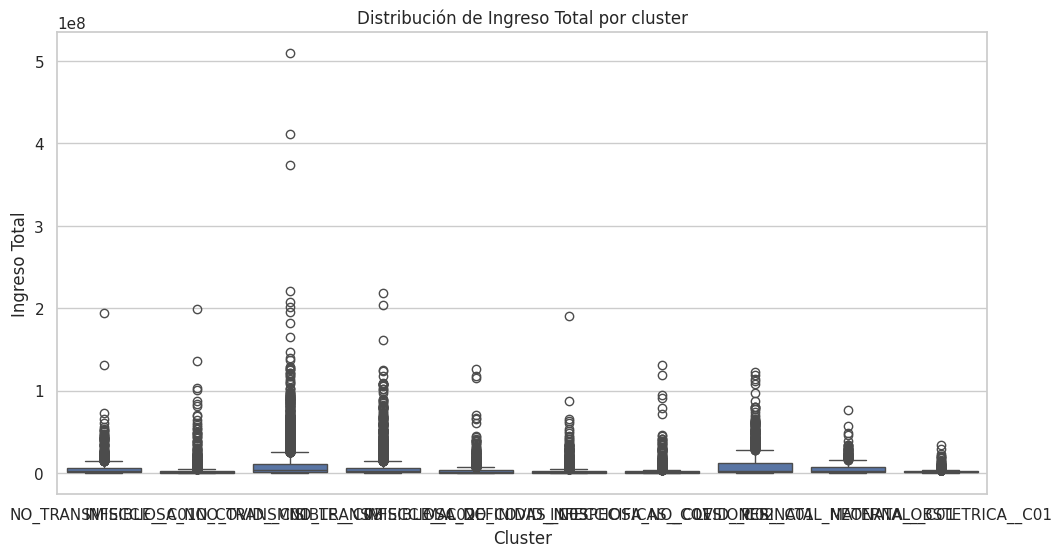

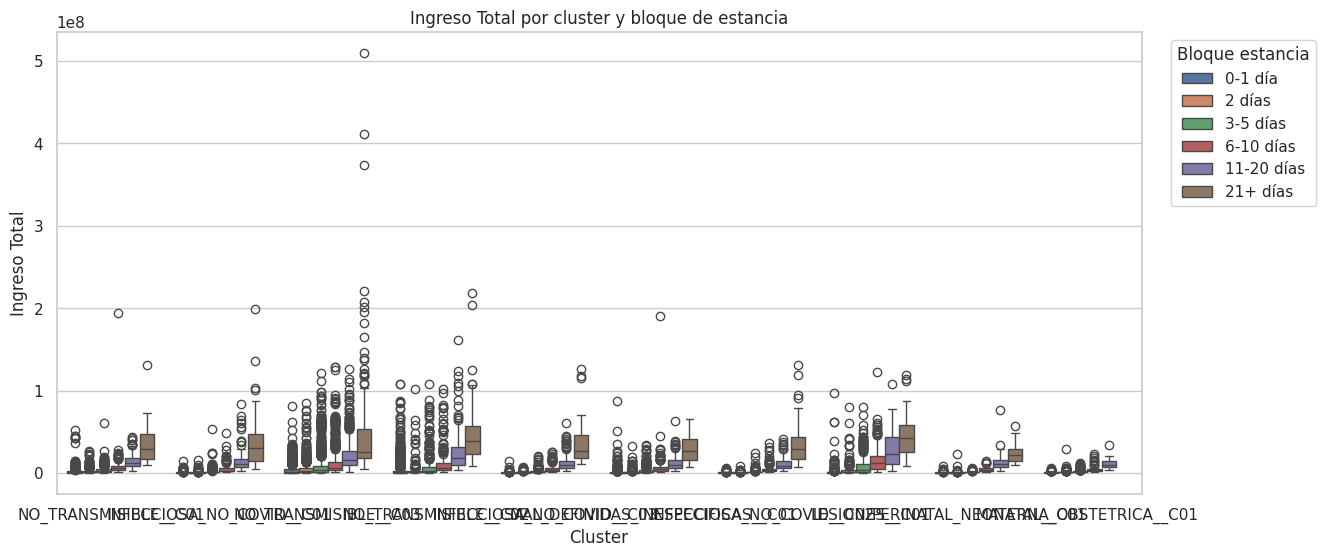

In [ ]:
# =========================================================
# 11) VISUALIZACIÓN INICIAL
# =========================================================

VAR_GRAFICAR = None

if COL_ING_TOTAL is not None:
    VAR_GRAFICAR = COL_ING_TOTAL
elif COL_ING_SERVICIO is not None:
    VAR_GRAFICAR = COL_ING_SERVICIO
elif COL_ING_MATMED is not None:
    VAR_GRAFICAR = COL_ING_MATMED
elif COL_ING_HON is not None:
    VAR_GRAFICAR = COL_ING_HON

if VAR_GRAFICAR is None:
    print("No se detectó variable financiera para graficar.")
else:
    temp = df_exp[[CLUSTER_COL, "_bloque_estancia", VAR_GRAFICAR]].copy()
    temp["_y"] = pd.to_numeric(temp[VAR_GRAFICAR], errors="coerce")
    temp = temp.dropna(subset=["_y", "_bloque_estancia"])

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=temp, x=CLUSTER_COL, y="_y")
    plt.title(f"Distribución de {VAR_GRAFICAR} por cluster")
    plt.xlabel("Cluster")
    plt.ylabel(VAR_GRAFICAR)
    plt.xticks(rotation=0)
    plt.show()

    plt.figure(figsize=(14, 6))
    sns.boxplot(data=temp, x=CLUSTER_COL, y="_y", hue="_bloque_estancia")
    plt.title(f"{VAR_GRAFICAR} por cluster y bloque de estancia")
    plt.xlabel("Cluster")
    plt.ylabel(VAR_GRAFICAR)
    plt.xticks(rotation=0)
    plt.legend(title="Bloque estancia", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

In [ ]:
# =========================================================
# 12) TABLA EJECUTIVA DEL DISEÑO
# =========================================================

filas = []

for nombre_var, res in resultados_doe.items():
    if res is None:
        continue

    anova_b = res["anova_bloque"]
    comp = res["comparacion_modelos"]

    p_cluster = np.nan
    p_bloque = np.nan

    if "C(_cluster)" in anova_b.index:
        p_cluster = anova_b.loc["C(_cluster)", "PR(>F)"]

    if "C(_bloque_estancia)" in anova_b.index:
        p_bloque = anova_b.loc["C(_bloque_estancia)", "PR(>F)"]

    mejor_modelo = comp.iloc[0]["modelo"]

    filas.append({
        "variable_respuesta": nombre_var,
        "mejor_modelo_AIC": mejor_modelo,
        "p_cluster_en_modelo_bloque": p_cluster,
        "p_bloque_estancia_en_modelo_bloque": p_bloque,
        "AIC_mejor": comp.iloc[0]["AIC"],
        "BIC_mejor": comp.iloc[0]["BIC"],
        "R2_mejor": comp.iloc[0]["R2"]
    })

tabla_ejecutiva_doe = pd.DataFrame(filas)

print("=== Tabla ejecutiva del diseño ===")
display(tabla_ejecutiva_doe.round(4))

=== Tabla ejecutiva del diseño ===


,variable_respuesta,mejor_modelo_AIC,p_cluster_en_modelo_bloque,p_bloque_estancia_en_modelo_bloque,AIC_mejor,BIC_mejor,R2_mejor
0,ingreso_servicio,cluster_bloque_interaccion,0.0,0.0,39592.1178,40074.5036,0.8112
1,ingreso_materiales_medicamentos,cluster_bloque_interaccion,0.0,0.0,107714.4307,108196.8166,0.2893
2,ingreso_honorarios,cluster_bloque_interaccion,0.0,0.0,102582.0682,103064.4540,0.2512
3,ingreso_total,cluster_bloque_interaccion,0.0,0.0,66805.9793,67288.3651,0.5197


In [ ]:
# =========================================================
# 13) TABLA DE CONTRIBUCIÓN TOTAL POR CLUSTER
# =========================================================

def tabla_contribucion_cluster(df, cluster_col, col_ingreso, col_estancia=None):
    temp = df[[cluster_col, col_ingreso]].copy()

    if col_estancia is not None and col_estancia in df.columns:
        temp[col_estancia] = pd.to_numeric(df[col_estancia], errors="coerce")

    temp["_ingreso"] = pd.to_numeric(temp[col_ingreso], errors="coerce")
    temp = temp.dropna(subset=["_ingreso"]).copy()

    agg_dict = {
        "n_episodios": (cluster_col, "size"),
        "ingreso_total_acumulado": ("_ingreso", "sum"),
        "ingreso_medio": ("_ingreso", "mean"),
        "ingreso_mediano": ("_ingreso", "median"),
        "p25_ingreso": ("_ingreso", lambda x: np.nanpercentile(x, 25)),
        "p75_ingreso": ("_ingreso", lambda x: np.nanpercentile(x, 75)),
    }

    if col_estancia is not None and col_estancia in temp.columns:
        agg_dict["estancia_media"] = (col_estancia, "mean")
        agg_dict["estancia_mediana"] = (col_estancia, "median")

    out = (
        temp.groupby(cluster_col)
            .agg(**agg_dict)
            .reset_index()
    )

    out["pct_episodios"] = 100 * out["n_episodios"] / out["n_episodios"].sum()
    out["pct_ingreso_total"] = 100 * out["ingreso_total_acumulado"] / out["ingreso_total_acumulado"].sum()
    out["ingreso_total_acumulado_mill"] = out["ingreso_total_acumulado"] / 1_000_000

    # ordenar por ingreso acumulado
    out = out.sort_values("ingreso_total_acumulado", ascending=False).reset_index(drop=True)

    return out

In [ ]:
# =========================================================
# 14) TABLA DE CONTRIBUCIÓN - INGRESO TOTAL
# =========================================================

tabla_contrib_ing_total = tabla_contribucion_cluster(
    df=df_exp,
    cluster_col=CLUSTER_COL,
    col_ingreso=COL_ING_TOTAL,
    col_estancia=COL_ESTANCIA
)

print("=== Contribución total por cluster - Ingreso total ===")
display(tabla_contrib_ing_total.round(2))

=== Contribución total por cluster - Ingreso total ===


,grupo_principal,n_episodios,ingreso_total_acumulado,ingreso_medio,ingreso_mediano,p25_ingreso,p75_ingreso,estancia_media,estancia_mediana,pct_episodios,pct_ingreso_total,ingreso_total_acumulado_mill
0,NO_TRANSMISIBLE__C03,7114,67061979975,9426761.31,3653058.5,1340567.00,10848050.00,5.00,3.0,27.08,45.50,67061.98
1,NO_TRANSMISIBLE__C02,2660,20649384592,7762926.54,2072340.5,793335.00,6156812.25,3.67,2.0,10.13,14.01,20649.38
2,LESIONES__C01,1133,11835191281,10445888.16,2928863.0,942450.00,11886137.00,4.79,3.0,4.31,8.03,11835.19
3,NO_TRANSMISIBLE__C01,1864,10409348814,5584414.60,2994195.0,1322145.25,6708420.00,4.77,3.0,7.10,7.06,10409.35
4,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,9338316784,2805984.61,1113440.0,648920.00,2501926.00,2.97,2.0,12.67,6.34,9338.32
5,MATERNA_OBSTETRICA__C01,4229,7432365272,1757475.83,1493270.0,1115620.00,2020898.00,2.33,2.0,16.10,5.04,7432.37
6,INFECCIOSA_NO_COVID__C03,1823,6485232874,3557450.84,1411140.0,713050.00,3247487.50,4.38,3.0,6.94,4.40,6485.23
7,INFECCIOSA_NO_COVID__C01,1704,5975210973,3506579.21,1034518.5,629830.50,2239762.75,4.16,3.0,6.49,4.05,5975.21
8,INFECCIOSA_NO_COVID__C02,1803,4886954704,2710457.41,1007257.0,623425.00,2060235.00,3.90,3.0,6.86,3.32,4886.95
9,PERINATAL_NEONATAL__C01,608,3319695491,5460025.48,2008966.0,810359.75,6920412.75,7.46,5.0,2.31,2.25,3319.70


In [ ]:
# =========================================================
# 15) TABLA CLUSTER × BLOQUE DE ESTANCIA - INGRESO TOTAL
# =========================================================

def tabla_cluster_bloque(df, cluster_col, bloque_col, col_ingreso):
    temp = df[[cluster_col, bloque_col, col_ingreso]].copy()
    temp["_ingreso"] = pd.to_numeric(temp[col_ingreso], errors="coerce")
    temp = temp.dropna(subset=["_ingreso", bloque_col]).copy()

    out = (
        temp.groupby([cluster_col, bloque_col], dropna=False)
            .agg(
                n=(cluster_col, "size"),
                ingreso_medio=("_ingreso", "mean"),
                ingreso_mediano=("_ingreso", "median"),
                p25=("_ingreso", lambda x: np.nanpercentile(x, 25)),
                p75=("_ingreso", lambda x: np.nanpercentile(x, 75))
            )
            .reset_index()
            .sort_values([cluster_col, bloque_col])
            .reset_index(drop=True)
    )

    return out

tabla_cluster_bloque_ing_total = tabla_cluster_bloque(
    df=df_exp,
    cluster_col=CLUSTER_COL,
    bloque_col="_bloque_estancia",
    col_ingreso=COL_ING_TOTAL
)

print("=== Tabla cluster × bloque de estancia - Ingreso total ===")
display(tabla_cluster_bloque_ing_total.round(2))

=== Tabla cluster × bloque de estancia - Ingreso total ===


/tmp/ipykernel_3704/2781327787.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby([cluster_col, bloque_col], dropna=False)


,grupo_principal,_bloque_estancia,n,ingreso_medio,ingreso_mediano,p25,p75
0,INFECCIOSA_NO_COVID__C01,0-1 día,429,876846.26,541249.0,376520.00,949032.00
1,INFECCIOSA_NO_COVID__C01,2 días,374,1022870.83,665015.0,543747.00,993215.00
2,INFECCIOSA_NO_COVID__C01,3-5 días,572,1881426.50,1151232.0,882807.00,1781489.00
3,INFECCIOSA_NO_COVID__C01,6-10 días,200,5124325.00,3079766.0,2214874.75,6129796.00
4,INFECCIOSA_NO_COVID__C01,11-20 días,88,16269961.10,10950212.5,6969663.50,17670742.75
5,INFECCIOSA_NO_COVID__C01,21+ días,41,41065675.71,30599247.0,14726325.00,47980471.00
6,INFECCIOSA_NO_COVID__C02,0-1 día,501,787769.70,544320.0,381230.00,919363.00
7,INFECCIOSA_NO_COVID__C02,2 días,365,901086.28,666782.0,526700.00,994602.00
8,INFECCIOSA_NO_COVID__C02,3-5 días,606,1593308.11,1152323.5,866856.50,1740489.25
9,INFECCIOSA_NO_COVID__C02,6-10 días,221,4738381.24,3387387.0,2284688.00,5377340.00


In [ ]:
# =========================================================
# 16) MATRICES DE INGRESO TOTAL POR CLUSTER Y BLOQUE
# =========================================================

matriz_media_ing_total = (
    tabla_cluster_bloque_ing_total
    .pivot(index=CLUSTER_COL, columns="_bloque_estancia", values="ingreso_medio")
)

matriz_mediana_ing_total = (
    tabla_cluster_bloque_ing_total
    .pivot(index=CLUSTER_COL, columns="_bloque_estancia", values="ingreso_mediano")
)

matriz_n_ing_total = (
    tabla_cluster_bloque_ing_total
    .pivot(index=CLUSTER_COL, columns="_bloque_estancia", values="n")
)

print("=== Matriz de ingreso medio por cluster y bloque de estancia ===")
display(matriz_media_ing_total.round(2))

print("=== Matriz de ingreso mediano por cluster y bloque de estancia ===")
display(matriz_mediana_ing_total.round(2))

print("=== Matriz de número de episodios por cluster y bloque de estancia ===")
display(matriz_n_ing_total.fillna(0).astype(int))

=== Matriz de ingreso medio por cluster y bloque de estancia ===


_bloque_estancia,0-1 día,2 días,3-5 días,6-10 días,11-20 días,21+ días
grupo_principal,,,,,,
INFECCIOSA_NO_COVID__C01,876846.26,1022870.83,1881426.50,5124325.00,16269961.10,41065675.71
INFECCIOSA_NO_COVID__C02,787769.70,901086.28,1593308.11,4738381.24,12071132.32,39498934.60
INFECCIOSA_NO_COVID__C03,805266.68,1280416.19,2366137.41,5088266.65,13540111.13,41115687.92
LESIONES__C01,2386941.85,4929920.14,9528499.81,16600269.76,28478533.08,46429917.10
MAL_DEFINIDAS_INESPECIFICAS__C01,1281148.32,1551629.95,2977445.07,6844330.80,13053919.28,28762468.04
MATERNA_OBSTETRICA__C01,1046411.28,1643313.37,2148132.42,4359155.74,12033815.47,NaN
NO_TRANSMISIBLE__C01,2464443.60,2864085.38,4019128.23,7620921.86,14639726.84,34957547.92
NO_TRANSMISIBLE__C02,4436874.68,3172913.72,7657943.70,11606120.88,26171719.88,49537289.98
NO_TRANSMISIBLE__C03,3894622.84,5078450.80,8135823.28,12111513.91,21115317.63,45370516.48


=== Matriz de ingreso mediano por cluster y bloque de estancia ===


_bloque_estancia,0-1 día,2 días,3-5 días,6-10 días,11-20 días,21+ días
grupo_principal,,,,,,
INFECCIOSA_NO_COVID__C01,541249.0,665015.0,1151232.0,3079766.0,10950212.5,30599247.0
INFECCIOSA_NO_COVID__C02,544320.0,666782.0,1152323.5,3387387.0,8643166.0,29228939.5
INFECCIOSA_NO_COVID__C03,592650.0,935110.0,1621210.0,3581080.0,10395376.0,27194492.0
LESIONES__C01,761417.0,1535101.0,4287922.0,11730250.5,22784339.0,42904397.0
MAL_DEFINIDAS_INESPECIFICAS__C01,705900.0,972903.0,1830375.5,4503661.5,9610310.0,27200966.0
MATERNA_OBSTETRICA__C01,990435.5,1483013.0,1922996.0,3334156.0,9383643.0,NaN
NO_TRANSMISIBLE__C01,969233.0,1717290.0,3024690.0,6382624.5,12643346.0,29337195.0
NO_TRANSMISIBLE__C02,900190.0,1261360.0,3157460.0,6202160.5,18120550.0,39121468.5
NO_TRANSMISIBLE__C03,1476985.0,1992298.0,3475389.0,6664533.0,16221530.0,26097675.0


=== Matriz de número de episodios por cluster y bloque de estancia ===


_bloque_estancia,0-1 día,2 días,3-5 días,6-10 días,11-20 días,21+ días
grupo_principal,,,,,,
INFECCIOSA_NO_COVID__C01,429,374,572,200,88,41
INFECCIOSA_NO_COVID__C02,501,365,606,221,80,30
INFECCIOSA_NO_COVID__C03,560,283,485,336,135,24
LESIONES__C01,342,196,284,174,106,31
MAL_DEFINIDAS_INESPECIFICAS__C01,1475,701,714,302,111,25
MATERNA_OBSTETRICA__C01,980,1896,1238,98,17,0
NO_TRANSMISIBLE__C01,472,311,517,392,134,38
NO_TRANSMISIBLE__C02,1223,403,523,316,145,50
NO_TRANSMISIBLE__C03,2198,1266,1693,1039,657,261


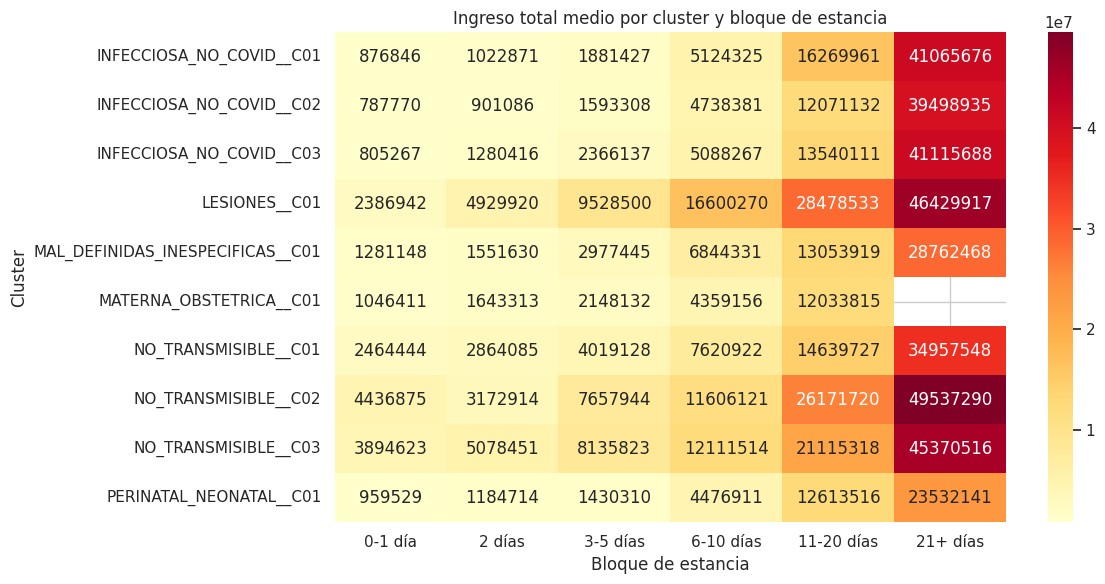

In [ ]:
# =========================================================
# 17) HEATMAP - INGRESO MEDIO POR CLUSTER Y BLOQUE
# =========================================================

plt.figure(figsize=(12, 6))
sns.heatmap(
    matriz_media_ing_total,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd"
)
plt.title("Ingreso total medio por cluster y bloque de estancia")
plt.xlabel("Bloque de estancia")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

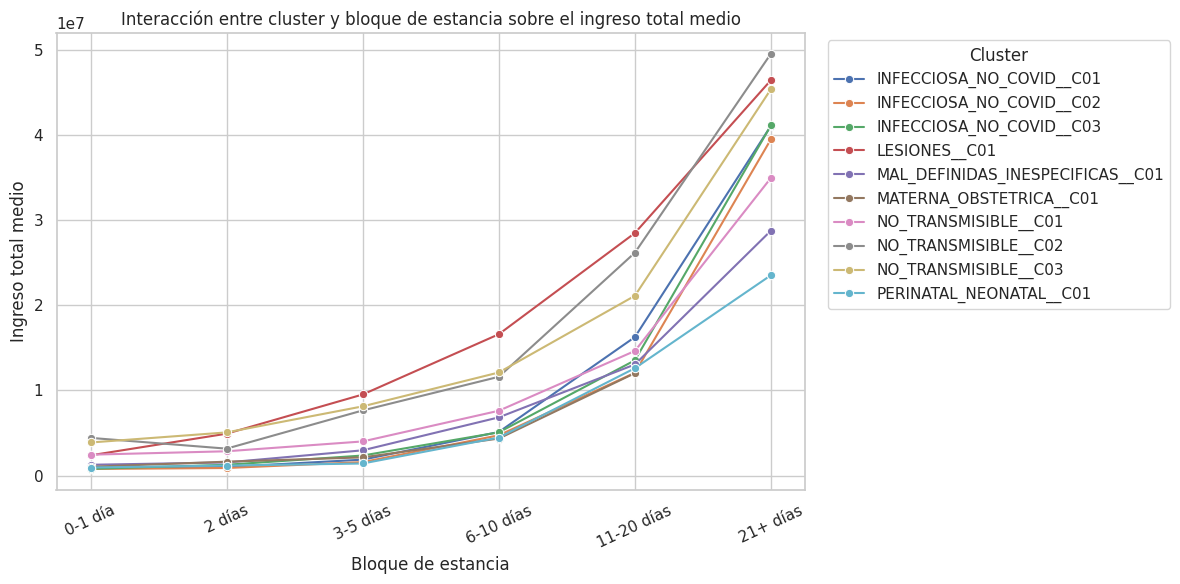

In [ ]:
# =========================================================
# 18) GRÁFICO DE INTERACCIÓN - INGRESO TOTAL MEDIO
# =========================================================

temp_plot = tabla_cluster_bloque_ing_total.copy()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=temp_plot,
    x="_bloque_estancia",
    y="ingreso_medio",
    hue=CLUSTER_COL,
    marker="o"
)
plt.title("Interacción entre cluster y bloque de estancia sobre el ingreso total medio")
plt.xlabel("Bloque de estancia")
plt.ylabel("Ingreso total medio")
plt.xticks(rotation=25)
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

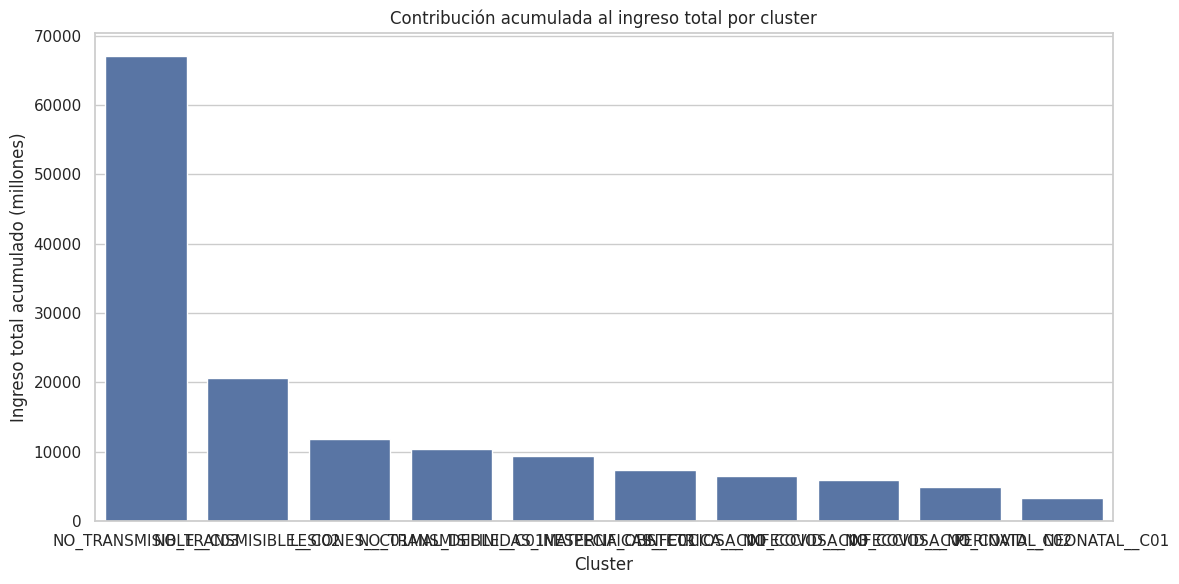

In [ ]:
# =========================================================
# 19) GRÁFICO DE CONTRIBUCIÓN TOTAL POR CLUSTER
# =========================================================

temp_bar = tabla_contrib_ing_total.sort_values("ingreso_total_acumulado", ascending=False).copy()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=temp_bar,
    x=CLUSTER_COL,
    y="ingreso_total_acumulado_mill"
)
plt.title("Contribución acumulada al ingreso total por cluster")
plt.xlabel("Cluster")
plt.ylabel("Ingreso total acumulado (millones)")
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 20) REPETIR PARA INGRESO DEL SERVICIO
# =========================================================

tabla_contrib_ing_servicio = tabla_contribucion_cluster(
    df=df_exp,
    cluster_col=CLUSTER_COL,
    col_ingreso=COL_ING_SERVICIO,
    col_estancia=COL_ESTANCIA
)

tabla_cluster_bloque_ing_servicio = tabla_cluster_bloque(
    df=df_exp,
    cluster_col=CLUSTER_COL,
    bloque_col="_bloque_estancia",
    col_ingreso=COL_ING_SERVICIO
)

matriz_media_ing_servicio = (
    tabla_cluster_bloque_ing_servicio
    .pivot(index=CLUSTER_COL, columns="_bloque_estancia", values="ingreso_medio")
)

print("=== Contribución total por cluster - Ingreso del servicio ===")
display(tabla_contrib_ing_servicio.round(2))

print("=== Matriz de ingreso medio del servicio por cluster y bloque ===")
display(matriz_media_ing_servicio.round(2))

=== Contribución total por cluster - Ingreso del servicio ===


/tmp/ipykernel_3704/2781327787.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby([cluster_col, bloque_col], dropna=False)


,grupo_principal,n_episodios,ingreso_total_acumulado,ingreso_medio,ingreso_mediano,p25_ingreso,p75_ingreso,estancia_media,estancia_mediana,pct_episodios,pct_ingreso_total,ingreso_total_acumulado_mill
0,NO_TRANSMISIBLE__C03,7114,8225068324,1156180.53,418611.0,166011.0,1163652.0,5.00,3.0,27.08,33.18,8225.07
1,NO_TRANSMISIBLE__C02,2660,2741656956,1030698.10,253626.0,138770.0,855690.0,3.67,2.0,10.13,11.06,2741.66
2,MAL_DEFINIDAS_INESPECIFICAS__C01,3328,1850696116,556098.59,207740.0,124263.0,498033.0,2.97,2.0,12.67,7.47,1850.70
3,PERINATAL_NEONATAL__C01,608,1803917708,2966969.91,948301.0,456912.0,3876215.0,7.46,5.0,2.31,7.28,1803.92
4,NO_TRANSMISIBLE__C01,1864,1780724516,955324.31,474280.0,196740.0,1061602.5,4.77,3.0,7.10,7.18,1780.72
5,INFECCIOSA_NO_COVID__C01,1704,1737407408,1019605.29,410300.0,196740.0,832620.0,4.16,3.0,6.49,7.01,1737.41
6,LESIONES__C01,1133,1693041812,1494299.92,474280.0,166011.0,1396950.0,4.79,3.0,4.31,6.83,1693.04
7,INFECCIOSA_NO_COVID__C03,1823,1687413598,925624.57,416310.0,144030.0,996066.0,4.38,3.0,6.94,6.81,1687.41
8,INFECCIOSA_NO_COVID__C02,1803,1640692424,909979.16,386835.0,166011.0,797720.0,3.90,3.0,6.86,6.62,1640.69
9,MATERNA_OBSTETRICA__C01,4229,1630880481,385642.11,332022.0,242640.0,432090.0,2.33,2.0,16.10,6.58,1630.88


=== Matriz de ingreso medio del servicio por cluster y bloque ===


_bloque_estancia,0-1 día,2 días,3-5 días,6-10 días,11-20 días,21+ días
grupo_principal,,,,,,
INFECCIOSA_NO_COVID__C01,140743.13,315361.90,703148.89,1762790.62,4323010.10,10339001.83
INFECCIOSA_NO_COVID__C02,142757.62,292721.88,669559.26,1756348.27,3781438.89,12196879.43
INFECCIOSA_NO_COVID__C03,124843.46,275677.04,673316.99,1544915.34,3597175.53,8675653.04
LESIONES__C01,158782.95,395824.09,961266.59,2415678.93,5277454.87,9948982.61
MAL_DEFINIDAS_INESPECIFICAS__C01,131184.73,277410.65,613097.55,1598456.30,3174422.48,7595496.76
MATERNA_OBSTETRICA__C01,158316.67,320906.43,547036.87,1324423.12,3545084.18,NaN
NO_TRANSMISIBLE__C01,147618.66,331331.63,658016.45,1484314.44,3124066.24,7035098.18
NO_TRANSMISIBLE__C02,148979.18,332080.03,908630.54,2079502.84,4832359.35,11851967.92
NO_TRANSMISIBLE__C03,168237.61,339213.03,754907.80,1719192.12,3698150.93,7401738.25


analisis de no transmitible 3

In [ ]:
# =========================================================
# BLOQUE C03. ENFERMEDADES DENTRO DE NO_TRANSMISIBLE__C03
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# -----------------------------
# 1) Filtrar cluster objetivo
# -----------------------------

CLUSTER_OBJETIVO = "NO_TRANSMISIBLE__C03"
NOMBRE_CLUSTER = "NT médico crónico complejo"

df_c03 = df_exp[df_exp[CLUSTER_COL].astype(str) == CLUSTER_OBJETIVO].copy()

df_c03["_ingreso_total"] = pd.to_numeric(df_c03[COL_ING_TOTAL], errors="coerce")
df_c03["_estancia"] = pd.to_numeric(df_c03[COL_ESTANCIA], errors="coerce")

# Crear diagnóstico completo
df_c03["_diag_codigo"] = df_c03["cdo_diagnostico_egreso"].astype(str).str.strip()
df_c03["_diag_nombre"] = df_c03["nombre_diagnostico_egreso"].astype(str).str.strip()

df_c03["_diagnostico"] = (
    df_c03["_diag_codigo"] + " - " + df_c03["_diag_nombre"]
)

df_c03["_diagnostico"] = df_c03["_diagnostico"].replace({
    "nan - nan": np.nan,
    "None - None": np.nan
})

print("======================================================")
print(f"CLUSTER ANALIZADO: {CLUSTER_OBJETIVO} - {NOMBRE_CLUSTER}")
print("======================================================")
print("Número de episodios:", len(df_c03))
print("Ingreso total acumulado:", df_c03["_ingreso_total"].sum())
print("Ingreso medio:", df_c03["_ingreso_total"].mean())
print("Ingreso mediano:", df_c03["_ingreso_total"].median())
print("Estancia media:", df_c03["_estancia"].mean())
print("Estancia mediana:", df_c03["_estancia"].median())

CLUSTER ANALIZADO: NO_TRANSMISIBLE__C03 - NT médico crónico complejo
Número de episodios: 7114
Ingreso total acumulado: 67061979975
Ingreso medio: 9426761.312201293
Ingreso mediano: 3653058.5
Estancia media: 5.002249086308687
Estancia mediana: 3.0


In [ ]:
# =========================================================
# 2) FAMILIAS CLÍNICAS / SUBGRUPOS DE CAUSA
# =========================================================

tabla_subgrupos_c03 = (
    df_c03
    .groupby("subgrupo_causa_morbilidad", dropna=False)
    .agg(
        n=("episodio", "count"),
        ingreso_total=("_ingreso_total", "sum"),
        ingreso_medio=("_ingreso_total", "mean"),
        ingreso_mediano=("_ingreso_total", "median"),
        estancia_media=("_estancia", "mean"),
        estancia_mediana=("_estancia", "median")
    )
    .reset_index()
)

tabla_subgrupos_c03["pct_episodios"] = (
    100 * tabla_subgrupos_c03["n"] / tabla_subgrupos_c03["n"].sum()
)

tabla_subgrupos_c03["pct_ingreso_total"] = (
    100 * tabla_subgrupos_c03["ingreso_total"] / tabla_subgrupos_c03["ingreso_total"].sum()
)

tabla_subgrupos_c03 = tabla_subgrupos_c03.sort_values(
    "ingreso_total",
    ascending=False
)

display(tabla_subgrupos_c03.round(2))

,subgrupo_causa_morbilidad,n,ingreso_total,ingreso_medio,ingreso_mediano,estancia_media,estancia_mediana,pct_episodios,pct_ingreso_total
12,Neoplasias malignas,1649,21711698824,13166585.10,7256032.0,6.84,4.0,23.18,32.38
9,Enfermedades musculo-esqueléticas,998,12962516656,12988493.64,8916938.5,4.48,2.0,14.03,19.33
13,Otras neoplasias,595,6856128659,11522905.31,5157098.0,5.09,2.0,8.36,10.22
7,Enfermedades genitourinarias,1079,5944173083,5508964.86,2673490.0,3.48,2.0,15.17,8.86
1,Condiciones neuropsiquíatricas,648,4390458539,6775398.98,1903272.5,4.59,2.0,9.11,6.55
14,sin clasificación,235,4353177458,18524159.40,4861906.0,5.42,4.0,3.30,6.49
3,Desordenes endocrinos,518,3458758212,6677139.41,2766192.5,3.90,2.0,7.28,5.16
10,Enfermedades respiratorias,556,2854372171,5133762.90,1572684.0,4.84,3.0,7.82,4.26
6,Enfermedades de los órganos de los sentidos,206,1491699720,7241260.78,4256113.0,5.78,4.0,2.90,2.22
0,Anomalías congénitas,141,1223928592,8680344.62,4562902.0,5.21,3.0,1.98,1.83


In [ ]:
# =========================================================
# 3) DIAGNÓSTICOS MÁS FRECUENTES EN NO_TRANSMISIBLE__C03
# =========================================================

tabla_diag_frecuentes_c03 = (
    df_c03
    .groupby(["cdo_diagnostico_egreso", "nombre_diagnostico_egreso"], dropna=False)
    .agg(
        n=("episodio", "count"),
        ingreso_total=("_ingreso_total", "sum"),
        ingreso_medio=("_ingreso_total", "mean"),
        ingreso_mediano=("_ingreso_total", "median"),
        estancia_media=("_estancia", "mean"),
        estancia_mediana=("_estancia", "median")
    )
    .reset_index()
)

tabla_diag_frecuentes_c03["pct_episodios"] = (
    100 * tabla_diag_frecuentes_c03["n"] / tabla_diag_frecuentes_c03["n"].sum()
)

tabla_diag_frecuentes_c03 = tabla_diag_frecuentes_c03.sort_values(
    ["n", "ingreso_total"],
    ascending=[False, False]
)

display(tabla_diag_frecuentes_c03.head(20).round(2))

,cdo_diagnostico_egreso,nombre_diagnostico_egreso,n,ingreso_total,ingreso_medio,ingreso_mediano,estancia_media,estancia_mediana,pct_episodios
964,N23X,"COLICO RENAL, NO ESPECIFICADO",159,689062192,4333724.48,2212011.0,2.39,2.0,2.24
743,J46X,ESTADO ASMATICO,154,295699545,1920126.92,1343928.0,4.17,4.0,2.16
559,G409,"EPILEPSIA, TIPO NO ESPECIFICADO",141,701938507,4978287.28,1432490.0,3.86,2.0,1.98
825,M170,"GONARTROSIS PRIMARIA, BILATERAL",111,1401365876,12624917.80,11853680.0,1.40,1.0,1.56
893,M545,LUMBAGO NO ESPECIFICADO,107,389604391,3641162.53,1663290.0,3.34,2.0,1.50
976,N40X,HIPERPLASIA DE LA PROSTATA,102,382475908,3749763.80,2160795.0,2.90,2.0,1.43
222,C910,LEUCEMIA LINFOBLASTICA AGUDA,100,2932064374,29320643.74,9618112.0,11.02,7.5,1.41
124,C509,"TUMOR MALIGNO DE LA MAMA, PARTE NO ESPECIFICADA",100,1013536512,10135365.12,7589138.5,6.13,4.0,1.41
736,J441,ENFERMEDAD PULMONAR OBSTRUCTIVA CRONICACON EXA...,91,290347986,3190637.21,1101290.0,3.14,2.0,1.28
1032,N939,"HEMORRAGIA VAGINAL Y UTERINA ANORMAL, NO ESPEC...",83,249251955,3003035.60,1929198.0,1.90,1.0,1.17


In [ ]:
# =========================================================
# 4) DIAGNÓSTICOS CON MAYOR INGRESO ACUMULADO
# =========================================================

tabla_diag_mayor_ingreso_c03 = tabla_diag_frecuentes_c03.sort_values(
    "ingreso_total",
    ascending=False
)

display(tabla_diag_mayor_ingreso_c03.head(20).round(2))

,cdo_diagnostico_egreso,nombre_diagnostico_egreso,n,ingreso_total,ingreso_medio,ingreso_mediano,estancia_media,estancia_mediana,pct_episodios
1141,Z940,TRASPLANTE DE RIÃ‘ON,81,3458502785,4.269757e+07,58491492.0,7.77,7.0,1.14
222,C910,LEUCEMIA LINFOBLASTICA AGUDA,100,2932064374,2.932064e+07,9618112.0,11.02,7.5,1.41
862,M419,"ESCOLIOSIS, NO ESPECIFICADA",41,2580947835,6.294995e+07,63455409.0,4.10,3.0,0.58
825,M170,"GONARTROSIS PRIMARIA, BILATERAL",111,1401365876,1.262492e+07,11853680.0,1.40,1.0,1.56
124,C509,"TUMOR MALIGNO DE LA MAMA, PARTE NO ESPECIFICADA",100,1013536512,1.013537e+07,7589138.5,6.13,4.0,1.41
954,N185,"ENFERMEDAD RENAL CRONICA, ETAPA 5",75,1002657723,1.336877e+07,6028371.0,7.60,6.0,1.05
94,C402,TUMOR MALIGNO DE LOS HUESOS LARGOS DEL MIEMBRO...,30,846537935,2.821793e+07,14070252.0,9.63,7.0,0.42
885,M519,"TRASTORNOS DE LOS DISCOS INTERVERTEBRALES, NO ...",48,841248134,1.752600e+07,18263250.0,2.21,1.0,0.67
66,C250,TUMOR MALIGNO DE LA CABEZA DEL PANCREAS,30,725119028,2.417063e+07,20543489.5,14.40,14.5,0.42
864,M431,ESPONDILOLISTESIS,35,708811027,2.025174e+07,22117960.0,2.11,2.0,0.49


In [ ]:
# =========================================================
# 5) DIAGNÓSTICOS CON MAYOR INGRESO MEDIANO
# =========================================================

N_MIN = 20

tabla_diag_mediana_alta_c03 = (
    tabla_diag_frecuentes_c03[tabla_diag_frecuentes_c03["n"] >= N_MIN]
    .sort_values("ingreso_mediano", ascending=False)
)

display(tabla_diag_mediana_alta_c03.head(20).round(2))

,cdo_diagnostico_egreso,nombre_diagnostico_egreso,n,ingreso_total,ingreso_medio,ingreso_mediano,estancia_media,estancia_mediana,pct_episodios
862,M419,"ESCOLIOSIS, NO ESPECIFICADA",41,2580947835,62949947.20,63455409.0,4.10,3.0,0.58
1141,Z940,TRASPLANTE DE RIÃ‘ON,81,3458502785,42697565.25,58491492.0,7.77,7.0,1.14
864,M431,ESPONDILOLISTESIS,35,708811027,20251743.63,22117960.0,2.11,2.0,0.49
66,C250,TUMOR MALIGNO DE LA CABEZA DEL PANCREAS,30,725119028,24170634.27,20543489.5,14.40,14.5,0.42
885,M519,"TRASTORNOS DE LOS DISCOS INTERVERTEBRALES, NO ...",48,841248134,17526002.79,18263250.0,2.21,1.0,0.67
94,C402,TUMOR MALIGNO DE LOS HUESOS LARGOS DEL MIEMBRO...,30,846537935,28217931.17,14070252.0,9.63,7.0,0.42
824,M169,"COXARTROSIS, NO ESPECIFICADA",37,500938392,13538875.46,13621075.0,1.16,1.0,0.52
127,C530,TUMOR MALIGNO DEL ENDOCERVIX,59,669867733,11353690.39,13005908.0,4.14,2.0,0.83
825,M170,"GONARTROSIS PRIMARIA, BILATERAL",111,1401365876,12624917.80,11853680.0,1.40,1.0,1.56
821,M160,"COXARTROSIS PRIMARIA, BILATERAL",20,207782247,10389112.35,11630250.0,1.45,1.0,0.28


In [ ]:
# =========================================================
# 6) DIAGNÓSTICOS CON MAYOR VARIABILIDAD DEL INGRESO
# =========================================================

tabla_variabilidad_diag_c03 = (
    df_c03
    .groupby(["cdo_diagnostico_egreso", "nombre_diagnostico_egreso"], dropna=False)
    .agg(
        n=("episodio", "count"),
        ingreso_total=("_ingreso_total", "sum"),
        ingreso_medio=("_ingreso_total", "mean"),
        ingreso_mediano=("_ingreso_total", "median"),
        p25=("_ingreso_total", lambda x: np.nanpercentile(x, 25)),
        p75=("_ingreso_total", lambda x: np.nanpercentile(x, 75)),
        p90=("_ingreso_total", lambda x: np.nanpercentile(x, 90)),
        p10=("_ingreso_total", lambda x: np.nanpercentile(x, 10)),
        sd=("_ingreso_total", "std"),
        estancia_media=("_estancia", "mean"),
        estancia_mediana=("_estancia", "median")
    )
    .reset_index()
)

tabla_variabilidad_diag_c03["IQR"] = (
    tabla_variabilidad_diag_c03["p75"] - tabla_variabilidad_diag_c03["p25"]
)

tabla_variabilidad_diag_c03["rango_p90_p10"] = (
    tabla_variabilidad_diag_c03["p90"] - tabla_variabilidad_diag_c03["p10"]
)

tabla_variabilidad_diag_c03["cv"] = (
    tabla_variabilidad_diag_c03["sd"] / tabla_variabilidad_diag_c03["ingreso_medio"]
)

tabla_variabilidad_diag_c03 = (
    tabla_variabilidad_diag_c03[tabla_variabilidad_diag_c03["n"] >= N_MIN]
    .sort_values(["IQR", "rango_p90_p10"], ascending=False)
)

display(tabla_variabilidad_diag_c03.head(20).round(2))

,cdo_diagnostico_egreso,nombre_diagnostico_egreso,n,ingreso_total,ingreso_medio,ingreso_mediano,p25,p75,p90,p10,sd,estancia_media,estancia_mediana,IQR,rango_p90_p10,cv
1141,Z940,TRASPLANTE DE RIÃ‘ON,81,3458502785,42697565.25,58491492.0,8837533.00,62949774.00,66429521.0,5478033.0,27057325.29,7.77,7.0,54112241.00,60951488.0,0.63
94,C402,TUMOR MALIGNO DE LOS HUESOS LARGOS DEL MIEMBRO...,30,846537935,28217931.17,14070252.0,4862589.50,36132261.00,66110837.5,3146318.0,38218433.84,9.63,7.0,31269671.50,62964519.5,1.35
862,M419,"ESCOLIOSIS, NO ESPECIFICADA",41,2580947835,62949947.20,63455409.0,49287670.00,76060935.00,98141695.0,18318059.0,31260062.51,4.10,3.0,26773265.00,79823636.0,0.50
885,M519,"TRASTORNOS DE LOS DISCOS INTERVERTEBRALES, NO ...",48,841248134,17526002.79,18263250.0,5769810.00,26871405.00,29732697.4,3908138.7,11957480.81,2.21,1.0,21101595.00,25824558.7,0.68
66,C250,TUMOR MALIGNO DE LA CABEZA DEL PANCREAS,30,725119028,24170634.27,20543489.5,8404679.00,29162536.75,40326471.3,3492202.1,23744318.43,14.40,14.5,20757857.75,36834269.2,0.98
954,N185,"ENFERMEDAD RENAL CRONICA, ETAPA 5",75,1002657723,13368769.64,6028371.0,2103099.00,20124741.50,34259604.6,751303.2,16236902.06,7.60,6.0,18021642.50,33508301.4,1.21
882,M511,"TRASTORNO DE DISCO LUMBAR Y OTROS, CON RADICUL...",48,661297354,13777028.21,5270031.5,1497407.75,18618217.25,32595797.7,536025.0,21154067.69,6.06,5.0,17120809.50,32059772.7,1.54
32,C161,TUMOR MALIGNO DEL FUNDUS GASTRICO,34,330356468,9716366.71,4817682.5,1373881.00,18433253.25,23333851.4,878403.5,10159757.09,6.41,5.0,17059372.25,22455447.9,1.05
222,C910,LEUCEMIA LINFOBLASTICA AGUDA,100,2932064374,29320643.74,9618112.0,4799869.00,21508895.50,65892300.6,2440471.6,63803210.67,11.02,7.5,16709026.50,63451829.0,2.18
387,D693,PURPURA TROMBOCITOPENICA IDIOPATICA,36,452517118,12569919.94,9269099.0,1782862.50,17505422.50,31315887.0,617137.0,12462991.06,4.56,4.0,15722560.00,30698750.0,0.99


In [ ]:
# =========================================================
# 7) DIAGNÓSTICOS POR BLOQUE DE ESTANCIA DENTRO DE C03
# =========================================================

tabla_diag_estancia_c03 = (
    df_c03
    .groupby(
        ["_bloque_estancia", "cdo_diagnostico_egreso", "nombre_diagnostico_egreso"],
        dropna=False,
        observed=True
    )
    .agg(
        n=("episodio", "count"),
        ingreso_total=("_ingreso_total", "sum"),
        ingreso_medio=("_ingreso_total", "mean"),
        ingreso_mediano=("_ingreso_total", "median"),
        estancia_media=("_estancia", "mean")
    )
    .reset_index()
)

tabla_diag_estancia_c03["pct_dentro_bloque"] = (
    tabla_diag_estancia_c03
    .groupby("_bloque_estancia")["n"]
    .transform(lambda x: 100 * x / x.sum())
)

tabla_diag_estancia_c03 = tabla_diag_estancia_c03.sort_values(
    ["_bloque_estancia", "ingreso_total"],
    ascending=[True, False]
)

display(tabla_diag_estancia_c03.head(50).round(2))

/tmp/ipykernel_3704/554976845.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("_bloque_estancia")["n"]


,_bloque_estancia,cdo_diagnostico_egreso,nombre_diagnostico_egreso,n,ingreso_total,ingreso_medio,ingreso_mediano,estancia_media,pct_dentro_bloque
394,0-1 día,M170,"GONARTROSIS PRIMARIA, BILATERAL",84,1083126876,12894367.57,12199860.5,1.0,3.82
393,0-1 día,M169,"COXARTROSIS, NO ESPECIFICADA",33,456730930,13840331.21,13943836.0,1.0,1.50
421,0-1 día,M519,"TRASTORNOS DE LOS DISCOS INTERVERTEBRALES, NO ...",25,417719479,16708779.16,17993010.0,1.0,1.14
414,0-1 día,M431,ESPONDILOLISTESIS,15,270780434,18052028.93,20895070.0,1.0,0.68
57,0-1 día,C61X,TUMOR MALIGNO DE LA PROSTATA,27,251852967,9327887.67,8993519.0,1.0,1.23
49,0-1 día,C530,TUMOR MALIGNO DEL ENDOCERVIX,26,244849524,9417289.38,9504219.5,1.0,1.18
206,0-1 día,E041,NODULO TIROIDEO SOLITARIO NO TOXICO,28,236952512,8462589.71,7818967.5,1.0,1.27
150,0-1 día,D391,TUMOR DE COMPORTAMIENTO INCIERTO O DESCONOCIDO...,43,213943574,4975431.95,4551489.0,1.0,1.96
52,0-1 día,C541,TUMOR MALIGNO DEL ENDOMETRIO,22,209889167,9540416.68,9339797.0,1.0,1.00
149,0-1 día,D390,TUMOR DE COMPORTAMIENTO INCIERTO O DESCONOCIDO...,29,134551381,4639702.79,3671500.0,1.0,1.32


In [ ]:
# =========================================================
# 8) ENFERMEDADES EN C03 CON ESTANCIA 11-20 Y 21+ DÍAS
# =========================================================

tabla_c03_estancias_largas = (
    tabla_diag_estancia_c03[
        tabla_diag_estancia_c03["_bloque_estancia"].isin(["11-20 días", "21+ días"])
    ]
    .sort_values(["_bloque_estancia", "ingreso_total"], ascending=[True, False])
)

display(tabla_c03_estancias_largas.round(2))

,_bloque_estancia,cdo_diagnostico_egreso,nombre_diagnostico_egreso,n,ingreso_total,ingreso_medio,ingreso_mediano,estancia_media,pct_dentro_bloque
2035,11-20 días,C910,LEUCEMIA LINFOBLASTICA AGUDA,27,608237132,22527301.19,13742198.0,14.89,4.11
2268,11-20 días,Z940,TRASPLANTE DE RIÃ‘ON,9,405529650,45058850.00,51800334.0,14.22,1.37
2230,11-20 días,N185,"ENFERMEDAD RENAL CRONICA, ETAPA 5",14,359516363,25679740.21,21577872.5,16.14,2.13
1977,11-20 días,C250,TUMOR MALIGNO DE LA CABEZA DEL PANCREAS,13,303657465,23358266.54,20988028.0,15.31,1.98
2221,11-20 días,M993,ESTENOSIS OSEA DEL CANAL NEURAL,5,290525978,58105195.60,58063200.0,17.00,0.76
...,...,...,...,...,...,...,...,...,...
2359,21+ días,E109,DIABETES MELLITUS INSULINODEPENDIENTE SIN MENC...,1,8869630,8869630.00,8869630.0,22.00,0.38
2441,21+ días,Z540,CONVALECENCIA CONSECUTIVA A CIRUGIA,1,8799335,8799335.00,8799335.0,21.00,0.38
2440,21+ días,Z515,ATENCION PALIATIVA,1,7319344,7319344.00,7319344.0,21.00,0.38
2423,21+ días,M868,OTRAS OSTEOMIELITIS,1,7072349,7072349.00,7072349.0,23.00,0.38


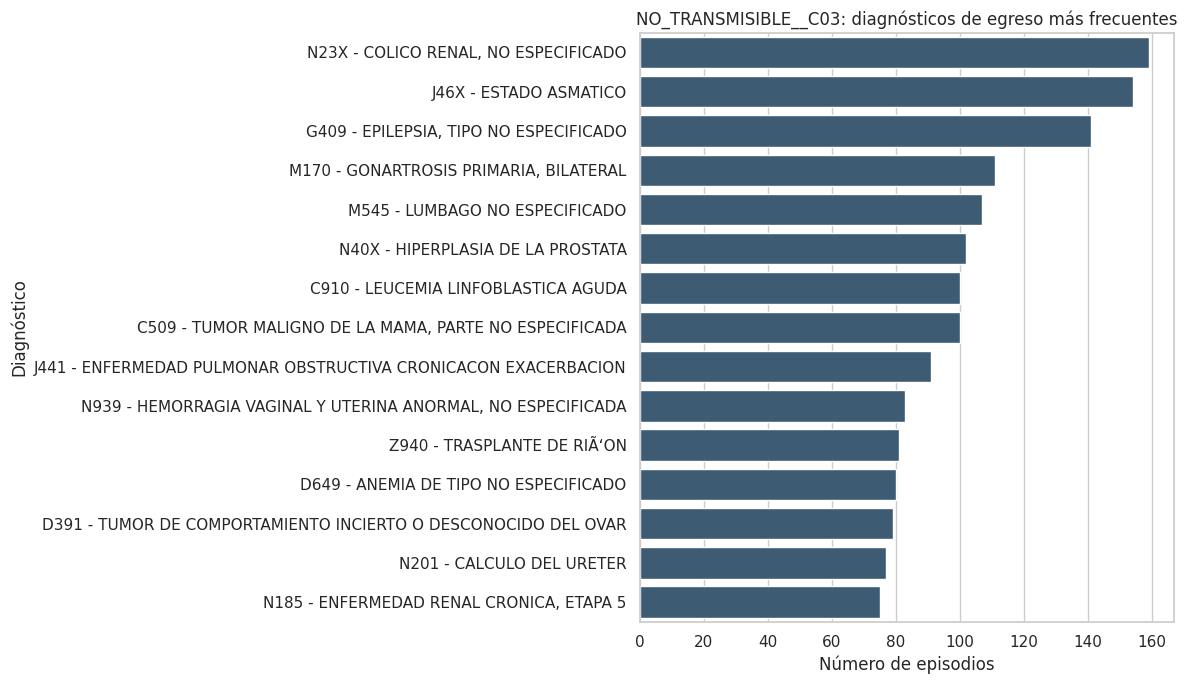

In [ ]:
# =========================================================
# 9) GRÁFICO: TOP DIAGNÓSTICOS MÁS FRECUENTES
# =========================================================

top_diag_freq = tabla_diag_frecuentes_c03.head(15).copy()
top_diag_freq["diagnostico_corto"] = (
    top_diag_freq["cdo_diagnostico_egreso"].astype(str)
    + " - "
    + top_diag_freq["nombre_diagnostico_egreso"].astype(str).str.slice(0, 55)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_diag_freq,
    y="diagnostico_corto",
    x="n",
    color="#355C7D"
)
plt.title("NO_TRANSMISIBLE__C03: diagnósticos de egreso más frecuentes")
plt.xlabel("Número de episodios")
plt.ylabel("Diagnóstico")
plt.tight_layout()
plt.show()

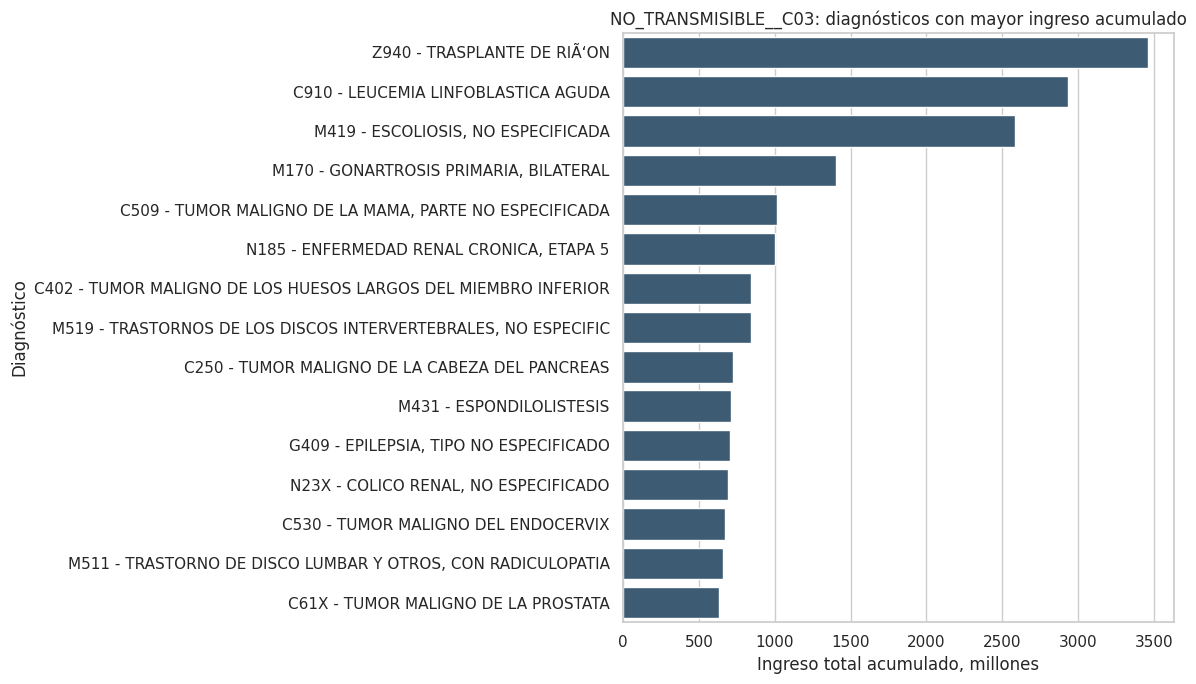

In [ ]:
# =========================================================
# 10) GRÁFICO: TOP DIAGNÓSTICOS POR INGRESO ACUMULADO
# =========================================================

top_diag_ingreso = tabla_diag_mayor_ingreso_c03.head(15).copy()
top_diag_ingreso["ingreso_total_mill"] = top_diag_ingreso["ingreso_total"] / 1_000_000

top_diag_ingreso["diagnostico_corto"] = (
    top_diag_ingreso["cdo_diagnostico_egreso"].astype(str)
    + " - "
    + top_diag_ingreso["nombre_diagnostico_egreso"].astype(str).str.slice(0, 55)
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_diag_ingreso,
    y="diagnostico_corto",
    x="ingreso_total_mill",
    color="#355C7D"
)
plt.title("NO_TRANSMISIBLE__C03: diagnósticos con mayor ingreso acumulado")
plt.xlabel("Ingreso total acumulado, millones")
plt.ylabel("Diagnóstico")
plt.tight_layout()
plt.show()

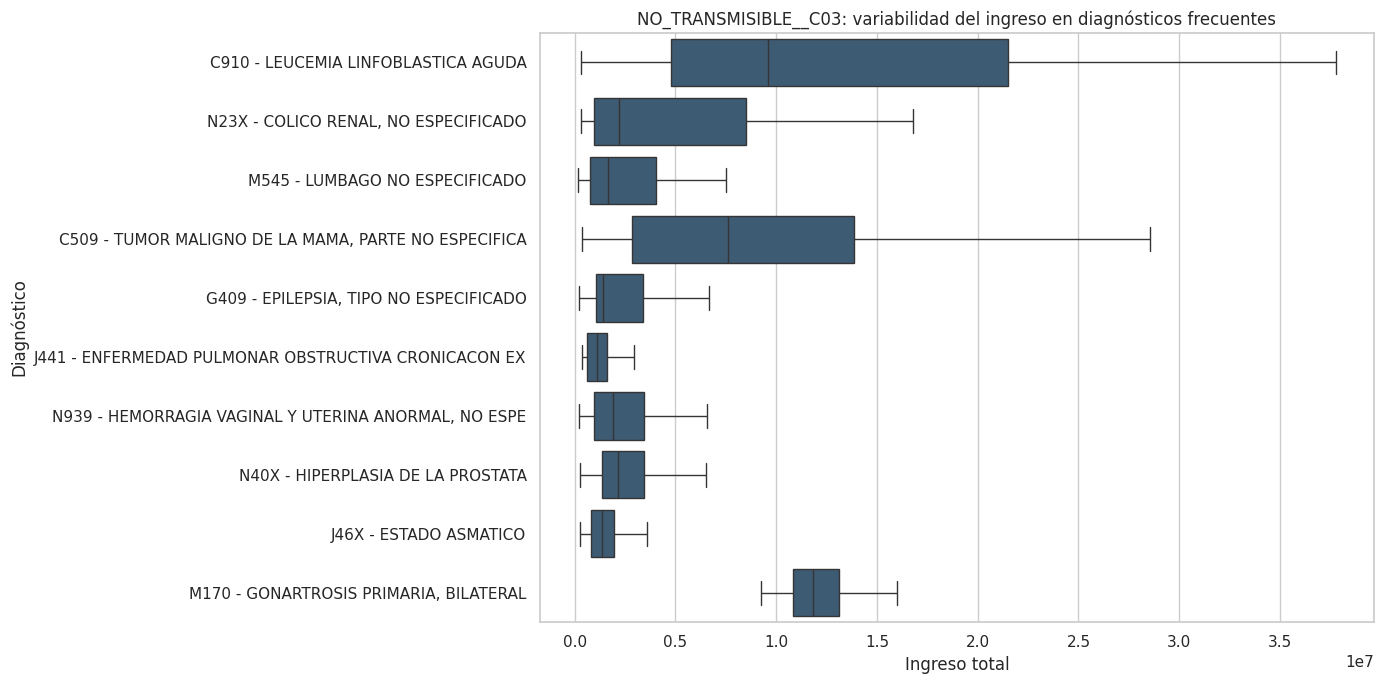

In [ ]:
# =========================================================
# 11) BOXPLOT: VARIABILIDAD DE INGRESO EN DIAGNÓSTICOS FRECUENTES
# =========================================================

top_codigos = tabla_diag_frecuentes_c03.head(10)["cdo_diagnostico_egreso"].astype(str).tolist()

df_box_diag_c03 = df_c03[
    df_c03["cdo_diagnostico_egreso"].astype(str).isin(top_codigos)
].copy()

df_box_diag_c03["diagnostico_corto"] = (
    df_box_diag_c03["cdo_diagnostico_egreso"].astype(str)
    + " - "
    + df_box_diag_c03["nombre_diagnostico_egreso"].astype(str).str.slice(0, 45)
)

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=df_box_diag_c03,
    x="_ingreso_total",
    y="diagnostico_corto",
    color="#355C7D",
    showfliers=False
)
plt.title("NO_TRANSMISIBLE__C03: variabilidad del ingreso en diagnósticos frecuentes")
plt.xlabel("Ingreso total")
plt.ylabel("Diagnóstico")
plt.tight_layout()
plt.show()

Se seleccionaron las combinaciones cluster–estancia que previamente mostraron mayor ingreso, mayor variabilidad o mayor relevancia clínica. Estas combinaciones corresponden a perfiles donde el ingreso hospitalario puede estar siendo explicado por trayectorias clínicas más complejas: estancias prolongadas, patologías de alto costo, procedimientos quirúrgicos, lesiones, infecciones complejas o enfermedades crónicas avanzadas.

In [ ]:
# =========================================================
# PASO 1 CORREGIDO. SELECCIÓN DE COMBINACIONES PRIORITARIAS
# Usando código de cluster + bloque de estancia
# =========================================================

import numpy as np
import pandas as pd
from IPython.display import display

# ---------------------------------------------------------
# 1) Asegurar columnas necesarias
# ---------------------------------------------------------

df_trabajo = df_exp.copy()

# Cluster en código
if "_cluster" not in df_trabajo.columns:
    df_trabajo["_cluster"] = df_trabajo[CLUSTER_COL].astype(str)

df_trabajo["_cluster"] = df_trabajo["_cluster"].astype(str)

# Nombre legible del cluster
if "_cluster_legible" not in df_trabajo.columns:
    df_trabajo["_cluster_legible"] = (
        df_trabajo["_cluster"]
        .map(MAPA_NOMBRES_CLUSTER)
        .fillna(df_trabajo["_cluster"])
    )

# Bloque de estancia
if "_bloque_estancia" not in df_trabajo.columns:
    df_trabajo["_estancia"] = pd.to_numeric(df_trabajo[COL_ESTANCIA], errors="coerce")

    df_trabajo["_bloque_estancia"] = pd.cut(
        df_trabajo["_estancia"],
        bins=[-np.inf, 1, 2, 5, 10, 20, np.inf],
        labels=[
            "0-1 día",
            "2 días",
            "3-5 días",
            "6-10 días",
            "11-20 días",
            "21+ días"
        ],
        right=True
    )

df_trabajo["_bloque_estancia"] = df_trabajo["_bloque_estancia"].astype(str)

# Ingreso y estancia numéricos
df_trabajo["_ingreso_total"] = pd.to_numeric(df_trabajo[COL_ING_TOTAL], errors="coerce")
df_trabajo["_estancia"] = pd.to_numeric(df_trabajo[COL_ESTANCIA], errors="coerce")


# ---------------------------------------------------------
# 2) Definir combinaciones prioritarias por código real
# ---------------------------------------------------------

combinaciones_prioritarias_cod = pd.DataFrame({
    "_cluster": [
        "NO_TRANSMISIBLE__C02",
        "NO_TRANSMISIBLE__C03",
        "LESIONES__C01",
        "NO_TRANSMISIBLE__C02",
        "NO_TRANSMISIBLE__C03",
        "LESIONES__C01",
        "INFECCIOSA_NO_COVID__C01"
    ],
    "_bloque_estancia": [
        "21+ días",
        "21+ días",
        "11-20 días",
        "11-20 días",
        "11-20 días",
        "6-10 días",
        "11-20 días"
    ],
    "orden_prioridad": [
        1, 2, 3, 4, 5, 6, 7
    ]
})

combinaciones_prioritarias_cod["_combo_prioritaria"] = (
    combinaciones_prioritarias_cod["_cluster"]
    .map(MAPA_NOMBRES_CLUSTER)
    .fillna(combinaciones_prioritarias_cod["_cluster"])
    + " | "
    + combinaciones_prioritarias_cod["_bloque_estancia"]
)


# ---------------------------------------------------------
# 3) Filtrar dataframe prioritario
# ---------------------------------------------------------

df_prioritario = df_trabajo.merge(
    combinaciones_prioritarias_cod[
        ["_cluster", "_bloque_estancia", "orden_prioridad", "_combo_prioritaria"]
    ],
    on=["_cluster", "_bloque_estancia"],
    how="inner"
)

# Crear combinación legible final
df_prioritario["_combo_cluster_estancia"] = df_prioritario["_combo_prioritaria"]

print("======================================================")
print("RESUMEN DEL DATAFRAME PRIORITARIO")
print("======================================================")
print("Filas seleccionadas:", len(df_prioritario))
print("Combinaciones seleccionadas:", df_prioritario["_combo_cluster_estancia"].nunique())

display(
    df_prioritario[["_cluster", "_cluster_legible", "_bloque_estancia", "_combo_cluster_estancia"]]
    .drop_duplicates()
    .sort_values(["_cluster", "_bloque_estancia"])
)

RESUMEN DEL DATAFRAME PRIORITARIO
Filas seleccionadas: 1481
Combinaciones seleccionadas: 7


,_cluster,_cluster_legible,_bloque_estancia,_combo_cluster_estancia
3,INFECCIOSA_NO_COVID__C01,INF vectorial-entérico,11-20 días,INF vectorial-entérico | 11-20 días
8,LESIONES__C01,Lesiones,11-20 días,Lesiones | 11-20 días
4,LESIONES__C01,Lesiones,6-10 días,Lesiones | 6-10 días
23,NO_TRANSMISIBLE__C02,NT osteomuscular-neuroq,11-20 días,NT osteomuscular-neuroq | 11-20 días
14,NO_TRANSMISIBLE__C02,NT osteomuscular-neuroq,21+ días,NT osteomuscular-neuroq | 21+ días
0,NO_TRANSMISIBLE__C03,NT médico crónico complejo,11-20 días,NT médico crónico complejo | 11-20 días
10,NO_TRANSMISIBLE__C03,NT médico crónico complejo,21+ días,NT médico crónico complejo | 21+ días


In [ ]:
# =========================================================
# RESUMEN FINANCIERO DE COMBINACIONES PRIORITARIAS
# =========================================================

tabla_combos_prioritarios = (
    df_prioritario
    .groupby(
        ["orden_prioridad", "_cluster", "_cluster_legible", "_bloque_estancia", "_combo_cluster_estancia"],
        observed=True
    )
    .agg(
        n=("_ingreso_total", "size"),
        ingreso_total=("_ingreso_total", "sum"),
        ingreso_medio=("_ingreso_total", "mean"),
        ingreso_mediano=("_ingreso_total", "median"),
        p25=("_ingreso_total", lambda x: np.nanpercentile(x, 25)),
        p75=("_ingreso_total", lambda x: np.nanpercentile(x, 75)),
        p90=("_ingreso_total", lambda x: np.nanpercentile(x, 90)),
        p10=("_ingreso_total", lambda x: np.nanpercentile(x, 10)),
        sd=("_ingreso_total", "std"),
        estancia_media=("_estancia", "mean"),
        estancia_mediana=("_estancia", "median")
    )
    .reset_index()
)

tabla_combos_prioritarios["IQR"] = (
    tabla_combos_prioritarios["p75"] - tabla_combos_prioritarios["p25"]
)

tabla_combos_prioritarios["rango_p90_p10"] = (
    tabla_combos_prioritarios["p90"] - tabla_combos_prioritarios["p10"]
)

tabla_combos_prioritarios["cv"] = (
    tabla_combos_prioritarios["sd"] / tabla_combos_prioritarios["ingreso_medio"]
)

tabla_combos_prioritarios["ingreso_total_mill"] = (
    tabla_combos_prioritarios["ingreso_total"] / 1_000_000
)

tabla_combos_prioritarios = tabla_combos_prioritarios.sort_values(
    "orden_prioridad"
)

display(tabla_combos_prioritarios.round(2))

,orden_prioridad,_cluster,_cluster_legible,_bloque_estancia,_combo_cluster_estancia,n,ingreso_total,ingreso_medio,ingreso_mediano,p25,p75,p90,p10,sd,estancia_media,estancia_mediana,IQR,rango_p90_p10,cv,ingreso_total_mill
0,1,NO_TRANSMISIBLE__C02,NT osteomuscular-neuroq,21+ días,NT osteomuscular-neuroq | 21+ días,50,2476864499,49537289.98,39121468.5,22690877.25,56760329.50,106591539.3,10935427.0,43385925.55,25.32,24.0,34069452.25,95656112.3,0.88,2476.86
1,2,NO_TRANSMISIBLE__C03,NT médico crónico complejo,21+ días,NT médico crónico complejo | 21+ días,261,11841704801,45370516.48,26097675.0,18035572.00,53804923.00,90400069.0,13313040.0,56003085.20,26.52,25.0,35769351.00,77087029.0,1.23,11841.70
2,3,LESIONES__C01,Lesiones,11-20 días,Lesiones | 11-20 días,106,3018724507,28478533.08,22784339.0,11041040.00,43663872.50,60613753.5,6120030.5,21686550.71,14.40,14.0,32622832.50,54493723.0,0.76,3018.72
3,4,NO_TRANSMISIBLE__C02,NT osteomuscular-neuroq,11-20 días,NT osteomuscular-neuroq | 11-20 días,145,3794899382,26171719.88,18120550.0,9960514.00,31621323.00,59463862.2,5198177.0,26501923.64,14.71,14.0,21660809.00,54265685.2,1.01,3794.90
4,5,NO_TRANSMISIBLE__C03,NT médico crónico complejo,11-20 días,NT médico crónico complejo | 11-20 días,657,13872763681,21115317.63,16221530.0,9323026.00,26745473.00,43249322.0,6182665.2,17602820.05,14.67,14.0,17422447.00,37066656.8,0.83,13872.76
5,6,LESIONES__C01,Lesiones,6-10 días,Lesiones | 6-10 días,174,2888446938,16600269.76,11730250.5,5503040.00,21196505.00,35794685.5,2252679.0,16508711.48,7.53,7.0,15693465.00,33542006.5,0.99,2888.45
6,7,INFECCIOSA_NO_COVID__C01,INF vectorial-entérico,11-20 días,INF vectorial-entérico | 11-20 días,88,1431756577,16269961.10,10950212.5,6969663.50,17670742.75,35639014.3,4934060.4,15700521.55,14.55,14.5,10701079.25,30704953.9,0.97,1431.76
